In [1]:
# Neural Networks

### Set Up

In [2]:
#pip install tensorflow
#pip install -q -U keras-tuner
#pip install scikeras
#!pip install shap

In [3]:
# import required packages
import requests
import pandas as pd
import json
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, scale, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score, classification_report

from itertools import cycle, islice

from pandas.plotting import parallel_coordinates

import shap
import pyarrow

import tensorflow as tf
from tensorflow import keras

import keras_tuner as kt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score

import datetime

### National Park Service Data

#### National Park Service Sites

In [4]:
# National Park Service API Set Up
nps_url_base = "developer.nps.gov/api/v1"

my_api_key = 'your_key_here'

nps_url_request = "https://developer.nps.gov/api/v1/parks?limit=500&get=designation,fullName,id,name,parkCode,states&for=parkCode:*&api_key=" + my_api_key

# need to update limit to 500 for full run

In [5]:
# Execute API request
response = requests.get(nps_url_request)

In [6]:
# Check status of API request, report status, and if good transform data into dataframe and print column names
if response.status_code == 200:
    print('Successful API download')
    nps_api_exp = json.loads(response.text)
    nps_data = pd.DataFrame(nps_api_exp['data'])
    print(nps_data.columns)
else: print(f'API download failed. Error code: {response.status_code}')

Successful API download
Index(['id', 'url', 'fullName', 'parkCode', 'description', 'latitude',
       'longitude', 'latLong', 'activities', 'topics', 'states', 'contacts',
       'entranceFees', 'entrancePasses', 'fees', 'directionsInfo',
       'directionsUrl', 'operatingHours', 'addresses', 'images', 'weatherInfo',
       'name', 'designation', 'multimedia', 'relevanceScore'],
      dtype='str')


In [7]:
# Select parameters of interest from API data set
nps_sites0 = nps_data[['fullName','name','parkCode','designation','states']]

# Rename columns
nps_sites0 = nps_sites0.rename(columns={'fullName': 'Site_Full_Name', 'name': 'Site_Name', 'parkCode': 'Park_Code', 'designation': 'Designation', 'states': 'State List'})

# Capitalize park code for consistent formatting
nps_sites0['Park_Code'] = nps_sites0['Park_Code'].str.upper()

#nps_sites.head()

In [8]:
nps_sites_nodesig = nps_sites0[nps_sites0['Designation']==""]
nps_sites_nodesig

nps_sites_nodesig['Designation'] = 'Undesignated'

#nps_sites_nodesig

In [9]:
nps_sites_desig = nps_sites0[nps_sites0['Designation']!=""]
nps_sites_desig

,Site_Full_Name,Site_Name,Park_Code,Designation,State List
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA
4,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY
5,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE
...,...,...,...,...,...
469,Yorktown Battlefield Part of Colonial National...,Yorktown Battlefield,YORK,Part of Colonial National Historical Park,VA
470,Yosemite National Park,Yosemite,YOSE,National Park,CA
471,Yucca House National Monument,Yucca House,YUHO,National Monument,CO
472,Yukon - Charley Rivers National Preserve,Yukon - Charley Rivers,YUCH,National Preserve,AK


In [10]:
nps_sites = pd.concat([nps_sites_desig, nps_sites_nodesig], ignore_index = True)
nps_sites.sort_values(by = 'Park_Code')
nps_sites.head()

,Site_Full_Name,Site_Name,Park_Code,Designation,State List
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY
4,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE


In [11]:
# Break out list of sites by individual states
# (will include duplicate listings for parks spanning multiple states)
#nps_sites_state = nps_sites[['Park_Code','State List','Designation']]

#nps_sites_state['State Abb'] = nps_sites['State List']

#nps_sites_state['State Abb'] = (nps_sites_state['State List'].str.split(','))

#nps_sites_state = nps_sites_state.explode('State Abb')

#nps_sites_state = nps_sites_state.reset_index(drop=True)

#### Visitor Data

In [12]:
# Visitation Data

visit_file_1 = "Data/Annual Visitation By Park (1979-1985).csv"

visit_1_load = pd.read_csv(visit_file_1)

#visit_1_load.head(10)

visit_1_load.columns = visit_1_load.iloc[5]

visit_1_load = visit_1_load.iloc[6:].reset_index(drop = True)

visit_1 = visit_1_load.drop(visit_1_load.columns[[0,9,10,11]], axis=1)

#visit_1.head(10)

# Convert from pivot table to flat table format

visit_1_fl = visit_1.set_index('Park Name').stack().reset_index()

visit_1_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_1_fl.head(10)

visit_file_2 = "Data/Annual Visitation By Park (1986-2006).csv"

visit_2_load = pd.read_csv(visit_file_2)

#visit_2_load.head(10)

visit_2_load.columns = visit_2_load.iloc[5]

visit_2_load = visit_2_load.iloc[6:].reset_index(drop = True)

#visit_2_load.head(10)

visit_2 = visit_2_load.drop(visit_2_load.columns[[0,11,12,24]], axis=1)

#visit_2.head(10)

# Convert from pivot table to flat table format

visit_2_fl = visit_2.set_index('Park Name').stack().reset_index()

visit_2_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_2_fl.head()

visit_file_3 = "Data/Annual Visitation By Park (2006-2025).csv"

visit_3_load = pd.read_csv(visit_file_3)

#visit_3_load.head(10)

visit_3_load.columns = visit_3_load.iloc[5]

visit_3_load = visit_3_load.iloc[6:].reset_index(drop = True)

#visit_3_load.head(10)

visit_3 = visit_3_load.drop(visit_3_load.columns[[0,11,12,24]], axis=1)

#visit_3.head(10)

# Convert from pivot table to flat table format

visit_3_fl = visit_3.set_index('Park Name').stack().reset_index()

visit_3_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_3_fl.head()

In [13]:
# Concatenate Visitor Totals from Tables

visitors = pd.concat([visit_1_fl, visit_2_fl, visit_3_fl], ignore_index=True)

visitors = visitors.sort_values(by=['Park Name','Year'])

visitors.head()

#print(visitors.shape)

,Park Name,Year,Visitors
0,Abraham Lincoln Birthplace NHP,1979,"271,231"
1,Abraham Lincoln Birthplace NHP,1980,"239,074"
2,Abraham Lincoln Birthplace NHP,1981,"252,245"
3,Abraham Lincoln Birthplace NHP,1982,"318,707"
4,Abraham Lincoln Birthplace NHP,1983,"256,126"


In [14]:
# Remove any rows without park name
visitors.dropna(subset = ['Park Name'], inplace = True)

#print(visitors.shape)

# Convert numbers strings to numbers
visitors['Visitors'] = visitors['Visitors'].str.replace(",","")

visitors['Visitors'] = pd.to_numeric(visitors['Visitors'])
visitors['Year'] = pd.to_numeric(visitors['Year'])

# Remove entries with no visitor numbers
visitors['Visitors'] = visitors['Visitors'].dropna()
#visitors['Visitors Scaled'] = visitors['Visitors Scaled'].fillna(0)

#visitors['Visitors'].dtype


In [15]:
# Scale visitor numbers

vis_max = max(visitors['Visitors'])

visitors['Visitors Scaled'] = visitors['Visitors']/vis_max

In [16]:
# Import list of Site Abbreviations

visit_abb_file = "Data/Visitor_Sites_Codes.csv"

visitor_park_abb_load = pd.read_csv(visit_abb_file)

#visitor_park_abb_load.head()

visitor_park_abb = visitor_park_abb_load[['Park Name','Park_Code']]

#visitor_park_abb.head()

# Join site abbreviations to data frame

visitors = pd.merge(visitors, visitor_park_abb, on='Park Name', how='left')

visitors['Code_Year'] = visitors['Park_Code'] + '-' + visitors['Year'].astype(str)

visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year
0,Abraham Lincoln Birthplace NHP,1979,271231.0,0.012461,ABLI,ABLI-1979
1,Abraham Lincoln Birthplace NHP,1980,239074.0,0.010983,ABLI,ABLI-1980
2,Abraham Lincoln Birthplace NHP,1981,252245.0,0.011588,ABLI,ABLI-1981
3,Abraham Lincoln Birthplace NHP,1982,318707.0,0.014642,ABLI,ABLI-1982
4,Abraham Lincoln Birthplace NHP,1983,256126.0,0.011767,ABLI,ABLI-1983


In [17]:
visitors.describe()

,Year,Visitors,Visitors Scaled
count,17247.000000,1.609500e+04,16095.000000
mean,2003.127732,8.044333e+05,0.036956
std,13.390632,1.781894e+06,0.081862
min,1979.000000,0.000000e+00,0.000000
25%,1992.000000,5.174150e+04,0.002377
50%,2004.000000,2.053870e+05,0.009436
75%,2015.000000,7.563200e+05,0.034746
max,2025.000000,2.176718e+07,1.000000


In [18]:
#sel1 = visitors[(visitors['annual_chg_pct']<-0.9) & (visitors['annual_chg_pct']>-10)]
#sel1
#sns.countplot(data = visitors, x = 'annual_chg_pct')
#plt.show()

In [19]:
look = visitors[visitors['Visitors'] == 0]
look

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year
492,Aniakchak NM & PRES,1995,0.0,0.0,ANIA,ANIA-1995
818,Arlington House The R.E. Lee MEM,2019,0.0,0.0,ARHO,ARHO-2019
819,Arlington House The R.E. Lee MEM,2020,0.0,0.0,ARHO,ARHO-2020
1028,Belmont-Paul Women's Equality NM,2021,0.0,0.0,BEPA,BEPA-2021
1029,Belmont-Paul Women's Equality NM,2022,0.0,0.0,BEPA,BEPA-2022
2281,Cape Krusenstern NM,2014,0.0,0.0,CAKR,CAKR-2014
2282,Cape Krusenstern NM,2015,0.0,0.0,CAKR,CAKR-2015
2543,Carter G. Woodson Home NHS,2021,0.0,0.0,CAWO,CAWO-2021
2544,Carter G. Woodson Home NHS,2022,0.0,0.0,CAWO,CAWO-2022
2545,Carter G. Woodson Home NHS,2023,0.0,0.0,CAWO,CAWO-2023


In [20]:
viz0 = visitors[visitors['Visitors'] == 0]
viz0.shape

(54, 6)

In [21]:
# Calculate the change in annual visitor numbers from previous year 

# check to see if previous row is from same park
visitors['site_chk'] = (visitors['Park_Code'] == visitors['Park_Code'].shift(1)).astype(int)

# calculate the difference (whole and percentage) of visitors from the previous year (for the same site)
visitors['annual_chg'] = (visitors['Visitors'].diff()) * visitors['site_chk']
visitors['annual_chg_pct'] = (visitors['Visitors'].diff()) * visitors['site_chk'] / visitors['Visitors'].shift(1)

# replace infinite values with 15
visitors['annual_chg_pct'] = visitors['annual_chg_pct'].replace(np.inf, 15)


In [22]:
visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct
0,Abraham Lincoln Birthplace NHP,1979,271231.0,0.012461,ABLI,ABLI-1979,0,NaN,NaN
1,Abraham Lincoln Birthplace NHP,1980,239074.0,0.010983,ABLI,ABLI-1980,1,-32157.0,-0.118559
2,Abraham Lincoln Birthplace NHP,1981,252245.0,0.011588,ABLI,ABLI-1981,1,13171.0,0.055092
3,Abraham Lincoln Birthplace NHP,1982,318707.0,0.014642,ABLI,ABLI-1982,1,66462.0,0.263482
4,Abraham Lincoln Birthplace NHP,1983,256126.0,0.011767,ABLI,ABLI-1983,1,-62581.0,-0.196359


In [23]:
# remove the years with no previous year to track change
visitors = visitors[abs(visitors['annual_chg_pct']) > 0]
visitors.head()

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct
1,Abraham Lincoln Birthplace NHP,1980,239074.0,0.010983,ABLI,ABLI-1980,1,-32157.0,-0.118559
2,Abraham Lincoln Birthplace NHP,1981,252245.0,0.011588,ABLI,ABLI-1981,1,13171.0,0.055092
3,Abraham Lincoln Birthplace NHP,1982,318707.0,0.014642,ABLI,ABLI-1982,1,66462.0,0.263482
4,Abraham Lincoln Birthplace NHP,1983,256126.0,0.011767,ABLI,ABLI-1983,1,-62581.0,-0.196359
5,Abraham Lincoln Birthplace NHP,1984,258023.0,0.011854,ABLI,ABLI-1984,1,1897.0,0.007407


In [24]:
visitors[visitors['Visitors']==0]

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct
492,Aniakchak NM & PRES,1995,0.0,0.0,ANIA,ANIA-1995,1,-1193.0,-1.0
818,Arlington House The R.E. Lee MEM,2019,0.0,0.0,ARHO,ARHO-2019,1,-49500.0,-1.0
1028,Belmont-Paul Women's Equality NM,2021,0.0,0.0,BEPA,BEPA-2021,1,-2535.0,-1.0
2281,Cape Krusenstern NM,2014,0.0,0.0,CAKR,CAKR-2014,1,-18225.0,-1.0
2543,Carter G. Woodson Home NHS,2021,0.0,0.0,CAWO,CAWO-2021,1,-548.0,-1.0
3363,Clara Barton NHS,2016,0.0,0.0,CLBA,CLBA-2016,1,-2823.0,-1.0
3368,Clara Barton NHS,2021,0.0,0.0,CLBA,CLBA-2021,1,-450.0,-1.0
4368,Edgar Allan Poe NHS,2021,0.0,0.0,EDAL,EDAL-2021,1,-2418.0,-1.0
4372,Edgar Allan Poe NHS,2025,0.0,0.0,EDAL,EDAL-2025,1,-8131.0,-1.0
4741,Federal Hall NMEM,2005,0.0,0.0,FEHA,FEHA-2005,1,-156707.0,-1.0


In [25]:
# simplify data frame for merging
visitors_sel = visitors[['Park_Code','Code_Year','Year','Visitors','Visitors Scaled','annual_chg','annual_chg_pct']]
visitors_sel.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct
1,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559
2,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092
3,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482
4,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359
5,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407


In [26]:
high_vpct = visitors_sel[visitors_sel['annual_chg_pct'] > 10]

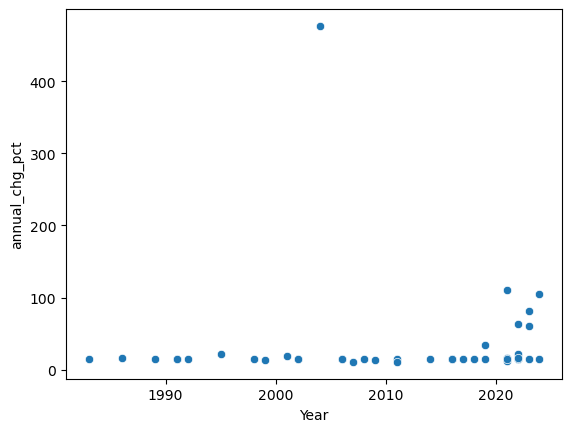

In [27]:
sns.scatterplot(data = high_vpct, x = 'Year', y = 'annual_chg_pct')
plt.show()

In [28]:
inf_chk0 = visitors[np.isinf(visitors['annual_chg_pct'])]
inf_chk0

,Park Name,Year,Visitors,Visitors Scaled,Park_Code,Code_Year,site_chk,annual_chg,annual_chg_pct


In [29]:
# Add designation to data frame for additional filtering
# designation list
nps_sites_desiglist = nps_sites[['Park_Code','Designation']]

visitor_park_wdesig = pd.merge(visitor_park_abb,nps_sites_desiglist,on = 'Park_Code', how = 'left')

visitor_park_wdesig.drop(columns=['Park Name'], inplace=True)

visitor_park_wdesig.head()


,Park_Code,Designation
0,ABLI,National Historical Park
1,ACAD,National Park
2,ADAM,National Historical Park
3,AFBG,National Monument
4,AGFO,National Monument


#### National Park Service Traffic

In [30]:
# Traffic Data

traffic_file_1 = "Data/Query Builder for Traffic Counts (1985-1989).csv"

traffic_file_2 = "Data/Query Builder for Traffic Counts (1990-1999).csv"

traffic_file_3 = "Data/Query Builder for Traffic Counts (2000-2009).csv"

traffic_file_4 = "Data/Query Builder for Traffic Counts (2010-2019).csv"

traffic_file_5 = "Data/Query Builder for Traffic Counts (2020-2025).csv"

In [31]:
# Load traffic data
traffic_1_load = pd.read_csv(traffic_file_1)

#traffic_1_load.head(10)

traffic_1_load.columns = traffic_1_load.iloc[1]

traffic_1_load = traffic_1_load.iloc[2:].reset_index(drop = True)

traffic_1 = traffic_1_load[[]]

#traffic_1_load.head(10)

#traffic_1_load['Traffic Count'].dtype

traffic_1_load['Traffic Count'] = traffic_1_load['Traffic Count'].str.replace(",","")

#traffic_1_load.head()

traffic_1_load['Traffic Count'] = pd.to_numeric(traffic_1_load['Traffic Count'])

traffic_1_load['Unit Code'] = traffic_1_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


#traffic_1_load['Traffic Count'].dtype

#traffic_1_load.head()

traffic_1 = traffic_1_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_1

#

traffic_2_load = pd.read_csv(traffic_file_2)

#traffic_2_load.head(10)

traffic_2_load.columns = traffic_2_load.iloc[1]

traffic_2_load = traffic_2_load.iloc[2:].reset_index(drop = True)

traffic_2 = traffic_2_load[[]]

#traffic_2_load.head(10)

#traffic_2_load['Traffic Count'].dtype

traffic_2_load['Traffic Count'] = traffic_2_load['Traffic Count'].str.replace(",","")

#traffic_2_load.head()

traffic_2_load['Traffic Count'] = pd.to_numeric(traffic_2_load['Traffic Count'])

traffic_2_load['Unit Code'] = traffic_2_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


#traffic_2_load['Traffic Count'].dtype

#traffic_2_load.head()

traffic_2 = traffic_2_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_2

#

traffic_3_load = pd.read_csv(traffic_file_3)

#traffic_3_load.head(10)

traffic_3_load.columns = traffic_3_load.iloc[1]

traffic_3_load = traffic_3_load.iloc[2:].reset_index(drop = True)

traffic_3 = traffic_3_load[[]]

#traffic_3_load.head(10)

#traffic_3_load['Traffic Count'].dtype

traffic_3_load['Traffic Count'] = traffic_3_load['Traffic Count'].str.replace(",","")

#traffic_3_load.head()

traffic_3_load['Traffic Count'] = pd.to_numeric(traffic_3_load['Traffic Count'])

traffic_3_load['Unit Code'] = traffic_3_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


#traffic_3_load['Traffic Count'].dtype

#traffic_3_load.head()

traffic_3 = traffic_3_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_3

#

traffic_4_load = pd.read_csv(traffic_file_4)

#traffic_4_load.head(10)

traffic_4_load.columns = traffic_4_load.iloc[1]

traffic_4_load = traffic_4_load.iloc[2:].reset_index(drop = True)

traffic_4 = traffic_4_load[[]]

#traffic_4_load.head(10)

#traffic_4_load['Traffic Count'].dtype

traffic_4_load['Traffic Count'] = traffic_4_load['Traffic Count'].str.replace(",","")

#traffic_4_load.head()

traffic_4_load['Traffic Count'] = pd.to_numeric(traffic_4_load['Traffic Count'])

traffic_4_load['Unit Code'] = traffic_4_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


traffic_4_load['Traffic Count'].dtype

#traffic_4_load.head()

traffic_4 = traffic_4_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()

#traffic_4

#

traffic_5_load = pd.read_csv(traffic_file_5)

traffic_5_load.columns = traffic_5_load.iloc[1]

traffic_5_load = traffic_5_load.iloc[2:].reset_index(drop = True)

traffic_5 = traffic_5_load[[]]

traffic_5_load['Traffic Count'] = traffic_5_load['Traffic Count'].str.replace(",","")

#traffic_5_load.head()

traffic_5_load['Traffic Count'] = pd.to_numeric(traffic_5_load['Traffic Count'])

traffic_5_load['Unit Code'] = traffic_5_load['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})


traffic_5 = traffic_5_load.groupby(['Unit Code','Year'])['Traffic Count'].sum().reset_index()


In [32]:
# Concatenate Traffic Totals from Tables

traffic = pd.concat([traffic_1,traffic_2,traffic_3,traffic_4,traffic_5], ignore_index=True)


In [33]:
traffic.head()

,Unit Code,Year,Traffic Count
0,BLRI,1988,3721649.0
1,BLRI,1989,3891985.0
2,YOSE,1985,1571341.0
3,YOSE,1986,1370764.0
4,YOSE,1987,1621929.0


In [34]:

traffic['Year'] = pd.to_numeric(traffic['Year'])

#traffic['Unit Code'] = df['Unit Code'].replace({'FOCA': 'TIMU', 'JODR': 'GRTE', 'KICA': 'SEKI', 'SEQU': 'SEKI', 'NCPE': 'NACE', 'OBRI': 'OBED', 'ROLA':'NOCA'})

traffic['Code_Year'] = traffic['Unit Code'] + '-' + traffic['Year'].astype(str)

traffic_max = max(traffic['Traffic Count'])

traffic['Traffic Count Scaled'] = traffic['Traffic Count']/traffic_max

traffic = traffic.rename(columns={'Unit Code': 'Park_Code'})

traffic = traffic.sort_values(by='Code_Year')

print(traffic.head(10))

print(traffic.shape)

     Park_Code  Year  Traffic Count  Code_Year  Traffic Count Scaled
7         ABLI  1993        84248.0  ABLI-1993              0.002412
8         ABLI  1994        78659.0  ABLI-1994              0.002252
9         ABLI  1995        75253.0  ABLI-1995              0.002154
10        ABLI  1996        69894.0  ABLI-1996              0.002001
11        ABLI  1997        73586.0  ABLI-1997              0.002106
12        ABLI  1998        70560.0  ABLI-1998              0.002020
13        ABLI  1999        70798.0  ABLI-1999              0.002027
1414      ABLI  2000        67485.0  ABLI-2000              0.001932
1415      ABLI  2001        65934.0  ABLI-2001              0.001887
1416      ABLI  2002        94503.0  ABLI-2002              0.002705
(6703, 5)


In [35]:
traffic.describe()

,Year,Traffic Count,Traffic Count Scaled
count,6703.000000,6.703000e+03,6703.000000
mean,2009.135611,9.601209e+05,0.027482
std,9.757701,3.171714e+06,0.090787
min,1985.000000,-2.633245e+06,-0.075374
25%,2001.000000,4.961450e+04,0.001420
50%,2009.000000,1.731410e+05,0.004956
75%,2018.000000,4.856385e+05,0.013901
max,2025.000000,3.493576e+07,1.000000


In [36]:
traffic['Traffic Count'] = traffic['Traffic Count'].abs()
traffic['Traffic Count Scaled'] = traffic['Traffic Count Scaled'].abs()

In [37]:
traffic[traffic['Traffic Count'] < 0]

,Park_Code,Year,Traffic Count,Code_Year,Traffic Count Scaled


In [38]:
traffic.describe()

,Year,Traffic Count,Traffic Count Scaled
count,6703.000000,6.703000e+03,6703.000000
mean,2009.135611,9.609398e+05,0.027506
std,9.757701,3.171465e+06,0.090780
min,1985.000000,0.000000e+00,0.000000
25%,2001.000000,4.967150e+04,0.001422
50%,2009.000000,1.731710e+05,0.004957
75%,2018.000000,4.859310e+05,0.013909
max,2025.000000,3.493576e+07,1.000000


In [39]:
traffic.info()

<class 'pandas.DataFrame'>
Index: 6703 entries, 7 to 6702
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Park_Code             6703 non-null   str    
 1   Year                  6703 non-null   int64  
 2   Traffic Count         6703 non-null   float64
 3   Code_Year             6703 non-null   str    
 4   Traffic Count Scaled  6703 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 400.9 KB


In [40]:
# Calculate the change in annual visitor numbers from previous year 

# check to see if previous row is from same park
traffic['site_chk'] = (traffic['Park_Code'] == traffic['Park_Code'].shift(1)).astype(int)

# calculate the difference (whole and percentage) of visitors from the previous year (for the same site)
traffic['annual_chg'] = (traffic['Traffic Count'].diff()) * traffic['site_chk']
traffic['annual_chg_pct'] = (traffic['Traffic Count'].diff()) * traffic['site_chk'] / traffic['Traffic Count'].shift(1)

# replace infinite values with 15 
traffic['annual_chg_pct'] = traffic['annual_chg_pct'].replace(np.inf, 15)

In [41]:
traffic.head()

,Park_Code,Year,Traffic Count,Code_Year,Traffic Count Scaled,site_chk,annual_chg,annual_chg_pct
7,ABLI,1993,84248.0,ABLI-1993,0.002412,0,NaN,NaN
8,ABLI,1994,78659.0,ABLI-1994,0.002252,1,-5589.0,-0.066340
9,ABLI,1995,75253.0,ABLI-1995,0.002154,1,-3406.0,-0.043301
10,ABLI,1996,69894.0,ABLI-1996,0.002001,1,-5359.0,-0.071213
11,ABLI,1997,73586.0,ABLI-1997,0.002106,1,3692.0,0.052823


In [42]:
# remove the years with no previous year to track change
traffic = traffic[abs(traffic['annual_chg_pct']) > 0]
traffic.head()

,Park_Code,Year,Traffic Count,Code_Year,Traffic Count Scaled,site_chk,annual_chg,annual_chg_pct
8,ABLI,1994,78659.0,ABLI-1994,0.002252,1,-5589.0,-0.066340
9,ABLI,1995,75253.0,ABLI-1995,0.002154,1,-3406.0,-0.043301
10,ABLI,1996,69894.0,ABLI-1996,0.002001,1,-5359.0,-0.071213
11,ABLI,1997,73586.0,ABLI-1997,0.002106,1,3692.0,0.052823
12,ABLI,1998,70560.0,ABLI-1998,0.002020,1,-3026.0,-0.041122


In [43]:
traffic.describe()

,Year,Traffic Count,Traffic Count Scaled,site_chk,annual_chg,annual_chg_pct
count,6248.000000,6.248000e+03,6248.000000,6248.0,6.248000e+03,6248.000000
mean,2009.722311,1.007596e+06,0.028841,1.0,1.105406e+04,0.342127
std,9.465440,3.262611e+06,0.093389,0.0,6.945586e+05,14.298497
min,1986.000000,0.000000e+00,0.000000,1.0,-2.837442e+07,-1.000000
25%,2002.000000,5.627500e+04,0.001611,1.0,-1.074000e+04,-0.065520
50%,2010.000000,1.871275e+05,0.005356,1.0,2.215000e+02,0.002507
75%,2018.000000,5.073590e+05,0.014523,1.0,1.357525e+04,0.078164
max,2025.000000,3.493576e+07,1.000000,1.0,2.383250e+07,1114.500000


In [44]:
traffic_sel = traffic[['Park_Code','Code_Year','Year','Traffic Count','Traffic Count Scaled','annual_chg','annual_chg_pct']]


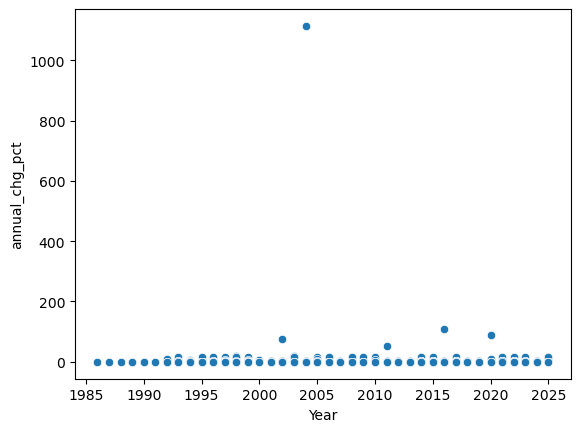

In [45]:
sns.scatterplot(data = traffic_sel, x = 'Year', y = 'annual_chg_pct')
plt.show()

#### National Park Site Area Data

In [46]:
# Load Nat'l Park Acreage Data

nps_area_file = "Data/NPS-Acreage-12-31-2025.csv"

nps_area_load = pd.read_csv(nps_area_file)

nps_area_load.head()

# Set first row to be header
nps_area_load.columns = nps_area_load.iloc[0]

nps_area_load = nps_area_load[1:].reset_index(drop = True)

nps_area_load['Gross Area Acres'] = pd.to_numeric(nps_area_load['Gross Area Acres'].str.replace(",",""))

# Remove notes from bottom of table
nps_area_load = nps_area_load.dropna(subset=['Region'])

# Downselect fields
nps_area = nps_area_load[['Area Name','Region','State','Gross Area Acres']]

# Scale area by max area value
#GAAmax = max(nps_area['Gross Area Acres'])

#nps_area['Gross Area Scaled'] = nps_area['Gross Area Acres']/GAAmax

nps_area.head(20)



,Area Name,Region,State,Gross Area Acres
0,A LINCOLN BIRTHPL NHP,1,KY,344.50
1,ACADIA NP,1,ME,49076.65
2,ADAMS NHP,1,MA,23.82
3,AFRICAN BURIAL GROUND NM,1,NY,0.35
4,AGATE FOSSIL BEDS NM,5,NE,3057.87
5,ALAGNAK WILD RVR,11,AK,30664.79
6,ALIBATES FLINT QUARRIES N,6,TX,1370.97
7,ALLEGHENY PRTGE RR NHS,1,PA,1284.27
8,AMACHE NHS,7,CO,472.59
9,AMISTAD NRA,6,TX,62945.15


In [47]:
# load area names to map to park codes for merging with other data
area_file_code = "Data/nps_area_list_codes.csv"

area_codes_load = pd.read_csv(area_file_code)
area_codes_load.head()

area_codes = area_codes_load[['Area Name','Park_Code']]

In [48]:
# attach park codes for further merging
nps_area = pd.merge(nps_area,area_codes,on = 'Area Name', how = 'left')

nps_area.head()



,Area Name,Region,State,Gross Area Acres,Park_Code
0,A LINCOLN BIRTHPL NHP,1,KY,344.50,ABLI
1,ACADIA NP,1,ME,49076.65,ACAD
2,ADAMS NHP,1,MA,23.82,ADAM
3,AFRICAN BURIAL GROUND NM,1,NY,0.35,AFBG
4,AGATE FOSSIL BEDS NM,5,NE,3057.87,AGFO


In [49]:
# remove unneeded fields
nps_area_red = nps_area[['Park_Code','Gross Area Acres']]

nps_area_red

,Park_Code,Gross Area Acres
0,ABLI,344.50
1,ACAD,49076.65
2,ADAM,23.82
3,AFBG,0.35
4,AGFO,3057.87
...,...,...
432,YELL,2219790.71
433,YOSE,761747.50
434,YUHO,195.07
435,YUCH,2526512.44


### Climate Data

In [50]:
# List of CE Regions and assigned states

cei_regions_file = "Data/CEI_Regions_States.csv"

cei_reg_load = pd.read_csv(cei_regions_file)

cei_reg_load.head(10)

,CEI Region,State,State Abb
0,Northwest,Washington,WA
1,Northwest,Oregon,OR
2,Northwest,Idaho,ID
3,West,California,CA
4,West,Nevada,NV
5,Southwest,Utah,UT
6,Southwest,Colorado,CO
7,Southwest,Arizona,AZ
8,Southwest,New Mexico,NM
9,Northern Rockies and Plains,Montana,MT


In [51]:
cei_file_us = "Data/CEI_ContigUS.csv"

cei_us_load = pd.read_csv(cei_file_us)

cei_us_load.columns = cei_us_load.iloc[0]

cei_us_load = cei_us_load.iloc[1:].reset_index(drop = False)

cei_us_load = cei_us_load.rename(columns={'Date': '','index': 'Year'})

cei_us_load['Year'] = pd.to_numeric(cei_us_load['Year'])

cei_us_load['Percentage Area'] = pd.to_numeric(cei_us_load['Percentage Area'])/100

cei_us = cei_us_load

cei_us.head(10)

Date,Year,Percentage Area
0,1910,0.2292
1,1911,0.2416
2,1912,0.3592
3,1913,0.1926
4,1914,0.1990
5,1915,0.2138
6,1916,0.2898
7,1917,0.3394
8,1918,0.1168
9,1919,0.2014


In [52]:
# Set up US value to be used for the "Multiple" region

cei_mult = cei_us
cei_mult['Region'] = 'Multiple'
cei_mult

Date,Year,Percentage Area,Region
0,1910,0.2292,Multiple
1,1911,0.2416,Multiple
2,1912,0.3592,Multiple
3,1913,0.1926,Multiple
4,1914,0.1990,Multiple
...,...,...,...
111,2021,0.3814,Multiple
112,2022,0.1758,Multiple
113,2023,0.3080,Multiple
114,2024,0.4590,Multiple


In [53]:
cei_file_1 = "Data/CEI_Northwest.csv"

reg_name = "Northwest"

cei_1_load = pd.read_csv(cei_file_1)

cei_1_load.columns = cei_1_load.iloc[0]

cei_1_load = cei_1_load.iloc[1:].reset_index(drop = False)

cei_1_load = cei_1_load.rename(columns={'Date': '','index': 'Year'})

cei_1_load['Region'] = reg_name

#cei_1_load.head(10)

cei_file_2 = "Data/CEI_Southwest.csv"

reg_name = "Southwest"

cei_2_load = pd.read_csv(cei_file_2)

cei_2_load.columns = cei_2_load.iloc[0]

cei_2_load = cei_2_load.iloc[1:].reset_index(drop = False)

cei_2_load = cei_2_load.rename(columns={'Date': '','index': 'Year'})

cei_2_load['Region'] = reg_name

#cei_2_load.head(10)

cei_file_3 = "Data/CEI_South.csv"

reg_name = "South"

cei_3_load = pd.read_csv(cei_file_3)

cei_3_load.columns = cei_3_load.iloc[0]

cei_3_load = cei_3_load.iloc[1:].reset_index(drop = False)

cei_3_load = cei_3_load.rename(columns={'Date': '','index': 'Year'})

cei_3_load['Region'] = reg_name

#cei_3_load.head(10)

cei_file_4 = "Data/CEI_Northeast.csv"

reg_name = "Northeast"

cei_4_load = pd.read_csv(cei_file_4)

cei_4_load.columns = cei_4_load.iloc[0]

cei_4_load = cei_4_load.iloc[1:].reset_index(drop = False)

cei_4_load = cei_4_load.rename(columns={'Date': '','index': 'Year'})

cei_4_load['Region'] = reg_name

#cei_4_load.head(10)

cei_file_5 = "Data/CEI_NorthernRockiesandPlains.csv"

reg_name = "Northern Rockies and Plains"

cei_5_load = pd.read_csv(cei_file_5)

cei_5_load.columns = cei_5_load.iloc[0]

cei_5_load = cei_5_load.iloc[1:].reset_index(drop = False)

cei_5_load = cei_5_load.rename(columns={'Date': '','index': 'Year'})

cei_5_load['Region'] = reg_name

#cei_5_load.head(10)

cei_file_6 = "Data/CEI_OhioValley.csv"

reg_name = "Ohio Valley"

cei_6_load = pd.read_csv(cei_file_6)

cei_6_load.columns = cei_6_load.iloc[0]

cei_6_load = cei_6_load.iloc[1:].reset_index(drop = False)

cei_6_load = cei_6_load.rename(columns={'Date': '','index': 'Year'})

cei_6_load['Region'] = reg_name

#cei_6_load.head(10)

cei_file_7 = "Data/CEI_UpperMidwest.csv"

reg_name = "Upper Midwest"

cei_7_load = pd.read_csv(cei_file_7)

cei_7_load.columns = cei_7_load.iloc[0]

cei_7_load = cei_7_load.iloc[1:].reset_index(drop = False)

cei_7_load = cei_7_load.rename(columns={'Date': '','index': 'Year'})

cei_7_load['Region'] = reg_name

#cei_7_load.head(10)

cei_file_8 = "Data/CEI_Southeast.csv"

reg_name = "Southeast"

cei_8_load = pd.read_csv(cei_file_8)

cei_8_load.columns = cei_8_load.iloc[0]

cei_8_load = cei_8_load.iloc[1:].reset_index(drop = False)

cei_8_load = cei_8_load.rename(columns={'Date': '','index': 'Year'})

cei_8_load['Region'] = reg_name

#cei_8_load.head(10)

cei_file_9 = "Data/CEI_West.csv"

reg_name = "West"

cei_9_load = pd.read_csv(cei_file_9)

cei_9_load.columns = cei_9_load.iloc[0]

cei_9_load = cei_9_load.iloc[1:].reset_index(drop = False)

cei_9_load = cei_9_load.rename(columns={'Date': '','index': 'Year'})

cei_9_load['Region'] = reg_name

#cei_9_load.head(10)

In [54]:
# Concatenate CEI Data from Tables

cei_data = pd.concat([cei_1_load,cei_2_load,cei_3_load,cei_4_load,cei_5_load,cei_6_load,cei_7_load,cei_8_load,cei_9_load, cei_mult], ignore_index=True)

cei_data['Year'] = pd.to_numeric(cei_data['Year'])
cei_data['Percentage Area'] = pd.to_numeric(cei_data['Percentage Area'])/100

cei_data.head(10)

#print(cei_data.shape)

Date,Year,Percentage Area,Region
0,1910,0.1042,Northwest
1,1911,0.3650,Northwest
2,1912,0.3418,Northwest
3,1913,0.3692,Northwest
4,1914,0.0988,Northwest
5,1915,0.0390,Northwest
6,1916,0.5424,Northwest
7,1917,0.1802,Northwest
8,1918,0.0812,Northwest
9,1919,0.4144,Northwest


In [55]:
cei_data.tail(10)

Date,Year,Percentage Area,Region
1150,2016,0.004006,Multiple
1151,2017,0.003408,Multiple
1152,2018,0.002828,Multiple
1153,2019,0.002884,Multiple
1154,2020,0.003230,Multiple
1155,2021,0.003814,Multiple
1156,2022,0.001758,Multiple
1157,2023,0.003080,Multiple
1158,2024,0.004590,Multiple
1159,2025,0.003166,Multiple


### El Nino Data

In [56]:
nino_file = "Data/ElNino_LaNina_Years_RONI.csv"

nino_load = pd.read_csv(nino_file)

In [57]:
nino_load.head()

,Year,RONI
0,1950,-1.5
1,1951,-0.5
2,1952,0.6
3,1953,0.5
4,1954,1.0


### Combine Data Sets

#### Visitor Data

In [58]:
# base data frame
visitors_sel.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct
1,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559
2,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092
3,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482
4,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359
5,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407


In [59]:
# join base with site designation

df = pd.merge(visitors_sel, visitor_park_wdesig, on = 'Park_Code', how = 'left')
df.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park


In [60]:
# join with site area

df = pd.merge(df, nps_area_red, on = 'Park_Code', how = 'left')
df.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5


In [61]:
# join site info with CEI regions 
nps_sites_2 = pd.merge(nps_sites, cei_reg_load, left_on = 'State List', right_on = 'State Abb', how = 'left')

nps_sites_2.loc[nps_sites_2['State List'] == 'DC', 'CEI Region'] = 'Southeast'

# CEI Regions are only for the contiguous US. Fill in categories for AK, HI and territories
nps_sites_2.loc[nps_sites_2['State List'] == 'AK', 'CEI Region'] = 'OCONUS'
nps_sites_2.loc[nps_sites_2['State List'] == 'HI', 'CEI Region'] = 'OCONUS'
nps_sites_2.loc[nps_sites_2['State List'] == 'MP', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'PR', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'VI', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'GU', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'AS', 'CEI Region'] = 'OCONUS-T'

nps_sites_2.head()

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region,State,State Abb
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley,Kentucky,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast,Maine,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast,Massachusetts,MA
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast,New York,NY
4,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE,Northern Rockies and Plains,Nebraska,NE


In [62]:
# extract sites with regions not defined (not contiguous US or multiple states listed)
nps_sites_2bl = nps_sites_2[nps_sites_2['CEI Region'].isna()]

nps_sites_2bl

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region,State,State Abb
19,Appalachian National Scenic Trail,Appalachian,APPA,National Scenic Trail,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",NaN,NaN,NaN
23,Assateague Island National Seashore,Assateague Island,ASIS,National Seashore,"MD,VA",NaN,NaN,NaN
34,Big South Fork National River & Recreation Area,Big South Fork,BISO,National River & Recreation Area,"KY,TN",NaN,NaN,NaN
36,Bighorn Canyon National Recreation Area,Bighorn Canyon,BICA,National Recreation Area,"MT,WY",NaN,NaN,NaN
40,Blackstone River Valley National Historical Park,Blackstone River Valley,BLRV,National Historical Park,"RI,MA",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
412,Vicksburg National Military Park,Vicksburg,VICK,National Military Park,"MS,LA",NaN,NaN,NaN
419,Washington-Rochambeau Revolutionary Route Nati...,Washington-Rochambeau Revolutionary Route,WARO,National Historic Trail,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",NaN,NaN,NaN
433,Yellowstone National Park,Yellowstone,YELL,National Park,"ID,MT,WY",NaN,NaN,NaN
444,Chesapeake Bay,Chesapeake Bay,CBPO,Undesignated,"DC,DE,MD,NY,PA,VA,WV",NaN,NaN,NaN


In [63]:
# Tag sites with multiple states as "Multiple"
nps_sites_2bl['State'] = 'Multiple'
nps_sites_2bl['State Abb'] = 'ML'
nps_sites_2bl = nps_sites_2bl.drop(columns = ['CEI Region'])
nps_sites_2bl

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,State,State Abb
19,Appalachian National Scenic Trail,Appalachian,APPA,National Scenic Trail,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",Multiple,ML
23,Assateague Island National Seashore,Assateague Island,ASIS,National Seashore,"MD,VA",Multiple,ML
34,Big South Fork National River & Recreation Area,Big South Fork,BISO,National River & Recreation Area,"KY,TN",Multiple,ML
36,Bighorn Canyon National Recreation Area,Bighorn Canyon,BICA,National Recreation Area,"MT,WY",Multiple,ML
40,Blackstone River Valley National Historical Park,Blackstone River Valley,BLRV,National Historical Park,"RI,MA",Multiple,ML
...,...,...,...,...,...,...,...
412,Vicksburg National Military Park,Vicksburg,VICK,National Military Park,"MS,LA",Multiple,ML
419,Washington-Rochambeau Revolutionary Route Nati...,Washington-Rochambeau Revolutionary Route,WARO,National Historic Trail,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",Multiple,ML
433,Yellowstone National Park,Yellowstone,YELL,National Park,"ID,MT,WY",Multiple,ML
444,Chesapeake Bay,Chesapeake Bay,CBPO,Undesignated,"DC,DE,MD,NY,PA,VA,WV",Multiple,ML


In [64]:
# Upload manually generated list to assign regions to state groups 
states_region_load = "Data/state_combo_list_key.csv"

state_region = pd.read_csv(states_region_load)

In [65]:
# join region info to site info
nps_sites_2blm = pd.merge(nps_sites_2bl, state_region, on = 'State List')

In [66]:
nps_sites_2blm

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,State,State Abb,CEI Region
0,Appalachian National Scenic Trail,Appalachian,APPA,National Scenic Trail,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",Multiple,ML,Multiple
1,Assateague Island National Seashore,Assateague Island,ASIS,National Seashore,"MD,VA",Multiple,ML,Multiple
2,Big South Fork National River & Recreation Area,Big South Fork,BISO,National River & Recreation Area,"KY,TN",Multiple,ML,Ohio Valley
3,Bighorn Canyon National Recreation Area,Bighorn Canyon,BICA,National Recreation Area,"MT,WY",Multiple,ML,Northern Rockies and Plains
4,Blackstone River Valley National Historical Park,Blackstone River Valley,BLRV,National Historical Park,"RI,MA",Multiple,ML,Northeast
...,...,...,...,...,...,...,...,...
57,Vicksburg National Military Park,Vicksburg,VICK,National Military Park,"MS,LA",Multiple,ML,South
58,Washington-Rochambeau Revolutionary Route Nati...,Washington-Rochambeau Revolutionary Route,WARO,National Historic Trail,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",Multiple,ML,Multiple
59,Yellowstone National Park,Yellowstone,YELL,National Park,"ID,MT,WY",Multiple,ML,Multiple
60,Chesapeake Bay,Chesapeake Bay,CBPO,Undesignated,"DC,DE,MD,NY,PA,VA,WV",Multiple,ML,Multiple


In [67]:
# extract sites with regions defined
nps_sites_2fl = nps_sites_2[nps_sites_2['CEI Region'].notna()]

nps_sites_2fl

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region,State,State Abb
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley,Kentucky,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast,Maine,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast,Massachusetts,MA
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast,New York,NY
4,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE,Northern Rockies and Plains,Nebraska,NE
...,...,...,...,...,...,...,...,...
469,Vietnam Veterans Memorial,Vietnam Veterans Memorial,VIVE,Undesignated,DC,Southeast,NaN,NaN
470,Washington Monument,Washington Monument,WAMO,Undesignated,DC,Southeast,NaN,NaN
471,Wolf Trap National Park for the Performing Arts,Wolf Trap National Park for the Performing Arts,WOTR,Undesignated,VA,Southeast,Virginia,VA
472,World War I Memorial,World War I Memorial,WWIM,Undesignated,DC,Southeast,NaN,NaN


In [68]:
# recombine tables to have the full set with regions defined for all sites
nps_sites_m = pd.concat([nps_sites_2fl, nps_sites_2blm], ignore_index = True)
nps_sites_m = nps_sites_m.sort_values(by = 'Park_Code')
nps_sites_m = nps_sites_m.drop(columns = ['State', 'State Abb'])
nps_sites_m

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast
379,African American Civil War Memorial,African American Civil War Memorial,AFAM,Undesignated,DC,Southeast
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast
...,...,...,...,...,...,...
374,Yorktown Battlefield Part of Colonial National...,Yorktown Battlefield,YORK,Part of Colonial National Historical Park,VA,Southeast
375,Yosemite National Park,Yosemite,YOSE,National Park,CA,West
377,Yukon - Charley Rivers National Preserve,Yukon - Charley Rivers,YUCH,National Preserve,AK,OCONUS
376,Yucca House National Monument,Yucca House,YUHO,National Monument,CO,Southwest


In [69]:
# merge data tables to create site data table for analysis
nps_next = pd.merge(df,nps_sites_m, on = 'Park_Code', how = 'left')
nps_next

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation_x,Gross Area Acres,Site_Full_Name,Site_Name,Designation_y,State List,CEI Region
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17931,ZION,ZION-2021,2021,5039835.0,0.231534,1448581.0,0.403364,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest
17932,ZION,ZION-2022,2022,4692417.0,0.215573,-347418.0,-0.068934,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest
17933,ZION,ZION-2023,2023,4623238.0,0.212395,-69179.0,-0.014743,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest
17934,ZION,ZION-2024,2024,4946592.0,0.227250,323354.0,0.069941,National Park,147242.66,Zion National Park,Zion,National Park,UT,Southwest


In [70]:
nps_sites_m

,Site_Full_Name,Site_Name,Park_Code,Designation,State List,CEI Region
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY,Ohio Valley
1,Acadia National Park,Acadia,ACAD,National Park,ME,Northeast
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA,Northeast
379,African American Civil War Memorial,African American Civil War Memorial,AFAM,Undesignated,DC,Southeast
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY,Northeast
...,...,...,...,...,...,...
374,Yorktown Battlefield Part of Colonial National...,Yorktown Battlefield,YORK,Part of Colonial National Historical Park,VA,Southeast
375,Yosemite National Park,Yosemite,YOSE,National Park,CA,West
377,Yukon - Charley Rivers National Preserve,Yukon - Charley Rivers,YUCH,National Preserve,AK,OCONUS
376,Yucca House National Monument,Yucca House,YUHO,National Monument,CO,Southwest


In [71]:
# select components 
nps_cei_regions = nps_sites_m[['Park_Code','CEI Region']]
nps_cei_regions

,Park_Code,CEI Region
0,ABLI,Ohio Valley
1,ACAD,Northeast
2,ADAM,Northeast
379,AFAM,Southeast
3,AFBG,Northeast
...,...,...
374,YORK,Southeast
375,YOSE,West
377,YUCH,OCONUS
376,YUHO,Southwest


In [72]:
# remove rows in OCONUS Regions (no CEI data)
nps_regions = nps_cei_regions[(nps_cei_regions['CEI Region']!='OCONUS') & (nps_cei_regions['CEI Region']!='OCONUS-T')  ]

nps_regions.rename(columns={"CEI Region": "Region"}, inplace=True)

nps_regions


,Park_Code,Region
0,ABLI,Ohio Valley
1,ACAD,Northeast
2,ADAM,Northeast
379,AFAM,Southeast
3,AFBG,Northeast
...,...,...
471,YELL,Multiple
374,YORK,Southeast
375,YOSE,West
376,YUHO,Southwest


In [73]:
df.shape

(17936, 9)

In [74]:
df['Park_Code'].nunique()

392

In [75]:
nps_regions['Park_Code'].nunique()

437

In [76]:
# check for common park codes between the data sets

df['Park_Code'].isin(nps_regions['Park_Code']).sum()

np.int64(16490)

In [77]:
nps_regions['Park_Code'].isin(df['Park_Code']).sum()

np.int64(362)

In [78]:
df1 = pd.merge(df, nps_regions, on = 'Park_Code', how = 'left')


In [79]:
nino_load.head()

,Year,RONI
0,1950,-1.5
1,1951,-0.5
2,1952,0.6
3,1953,0.5
4,1954,1.0


In [80]:
df1 = pd.merge(df1, nino_load, on = 'Year', how = 'left')
df1.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres,Region,RONI
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.6
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.0
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,2.5
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,-0.5


In [81]:
# Add composite feature to be able to join nps data with cei data

df1['Region-Year'] = df1['Region'] + '-' + df1['Year'].astype(str)
df1.head()

,Park_Code,Code_Year,Year,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres,Region,RONI,Region-Year
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.6,Ohio Valley-1980
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.0,Ohio Valley-1981
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1,Ohio Valley-1982
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,2.5,Ohio Valley-1983
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,-0.5,Ohio Valley-1984


In [82]:
# add same composite feature to CEI data
cei_data['Region-Year'] = cei_data['Region'] + '-' + cei_data['Year'].astype(str)
cei_data.head()


Date,Year,Percentage Area,Region,Region-Year
0,1910,0.1042,Northwest,Northwest-1910
1,1911,0.3650,Northwest,Northwest-1911
2,1912,0.3418,Northwest,Northwest-1912
3,1913,0.3692,Northwest,Northwest-1913
4,1914,0.0988,Northwest,Northwest-1914


In [83]:
df2 = pd.merge(df1, cei_data, on = 'Region-Year', how = 'left')
df2.head()

,Park_Code,Code_Year,Year_x,Visitors,Visitors Scaled,annual_chg,annual_chg_pct,Designation,Gross Area Acres,Region_x,RONI,Region-Year,Year_y,Percentage Area,Region_y
0,ABLI,ABLI-1980,1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.6,Ohio Valley-1980,1980.0,0.1162,Ohio Valley
1,ABLI,ABLI-1981,1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.0,Ohio Valley-1981,1981.0,0.1120,Ohio Valley
2,ABLI,ABLI-1982,1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1,Ohio Valley-1982,1982.0,0.1230,Ohio Valley
3,ABLI,ABLI-1983,1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,2.5,Ohio Valley-1983,1983.0,0.0882,Ohio Valley
4,ABLI,ABLI-1984,1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,-0.5,Ohio Valley-1984,1984.0,0.0780,Ohio Valley


In [84]:
# clean up data frame

df3 = df2[['Code_Year','Visitors','Visitors Scaled','annual_chg','annual_chg_pct','Designation','Gross Area Acres','Region_x','Percentage Area','RONI']]
df3.rename(columns={"annual_chg": "vis_annual_chg", "annual_chg_pct": "vis_annual_chg_pct", "Region_x": "Region",'Percentage Area':'cei_pct_area'}, inplace=True)
df3.head()

,Code_Year,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI
0,ABLI-1980,239074.0,0.010983,-32157.0,-0.118559,National Historical Park,344.5,Ohio Valley,0.1162,0.6
1,ABLI-1981,252245.0,0.011588,13171.0,0.055092,National Historical Park,344.5,Ohio Valley,0.1120,0.0
2,ABLI-1982,318707.0,0.014642,66462.0,0.263482,National Historical Park,344.5,Ohio Valley,0.1230,0.1
3,ABLI-1983,256126.0,0.011767,-62581.0,-0.196359,National Historical Park,344.5,Ohio Valley,0.0882,2.5
4,ABLI-1984,258023.0,0.011854,1897.0,0.007407,National Historical Park,344.5,Ohio Valley,0.0780,-0.5


In [85]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 17936 entries, 0 to 17935
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Code_Year           17936 non-null  str    
 1   Visitors            17936 non-null  float64
 2   Visitors Scaled     17936 non-null  float64
 3   vis_annual_chg      17936 non-null  float64
 4   vis_annual_chg_pct  17936 non-null  float64
 5   Designation         17936 non-null  str    
 6   Gross Area Acres    17936 non-null  float64
 7   Region              16490 non-null  str    
 8   cei_pct_area        16490 non-null  float64
 9   RONI                17936 non-null  float64
dtypes: float64(7), str(3)
memory usage: 2.0 MB


In [86]:
df3 = df3[df3['Region'].notna()]
df3.info()

<class 'pandas.DataFrame'>
Index: 16490 entries, 0 to 17935
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Code_Year           16490 non-null  str    
 1   Visitors            16490 non-null  float64
 2   Visitors Scaled     16490 non-null  float64
 3   vis_annual_chg      16490 non-null  float64
 4   vis_annual_chg_pct  16490 non-null  float64
 5   Designation         16490 non-null  str    
 6   Gross Area Acres    16490 non-null  float64
 7   Region              16490 non-null  str    
 8   cei_pct_area        16490 non-null  float64
 9   RONI                16490 non-null  float64
dtypes: float64(7), str(3)
memory usage: 2.0 MB


#### Traffic Data

In [87]:
# base data frame
traffic_sel.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct
8,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340
9,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301
10,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213
11,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823
12,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122


In [88]:
visitor_park_wdesig

,Park_Code,Designation
0,ABLI,National Historical Park
1,ACAD,National Park
2,ADAM,National Historical Park
3,AFBG,National Monument
4,AGFO,National Monument
...,...,...
395,WUPA,National Monument
396,YELL,National Park
397,YOSE,National Park
398,YUCH,National Preserve


In [89]:
# join base with site designation

df_t = pd.merge(traffic_sel, nps_sites, on = 'Park_Code', how = 'left')
df_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY


In [90]:
# join with site area

df_t = pd.merge(df_t, nps_area_red, on = 'Park_Code', how = 'left')
df_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5


In [91]:
# merge data tables to create site data table for analysis
nps_next_t = pd.merge(df_t,nps_sites_m, on = 'Park_Code', how = 'left')
nps_next_t

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name_x,Site_Name_x,Designation_x,State List_x,Gross Area Acres,Site_Full_Name_y,Site_Name_y,Designation_y,State List_y,CEI Region
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.50,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,Ohio Valley
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6549,ZION,ZION-2021,2021,1550770.0,0.044389,323846.0,0.263950,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest
6550,ZION,ZION-2022,2022,1416308.0,0.040540,-134462.0,-0.086707,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest
6551,ZION,ZION-2023,2023,1410960.0,0.040387,-5348.0,-0.003776,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest
6552,ZION,ZION-2024,2024,1470401.0,0.042089,59441.0,0.042128,Zion National Park,Zion,National Park,UT,147242.66,Zion National Park,Zion,National Park,UT,Southwest


In [92]:
df1_t = pd.merge(df_t, nps_regions, on = 'Park_Code', how = 'left')

In [93]:
df1_t = pd.merge(df1_t, nino_load, on = 'Year', how = 'left')
df1_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres,Region,RONI
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,0.3
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,1.3
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.9
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.2
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,2.2


In [94]:
# Add composite feature to be able to join nps data with cei data

df1_t['Region-Year'] = df1_t['Region'] + '-' + df1_t['Year'].astype(str)
df1_t.head()

,Park_Code,Code_Year,Year,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres,Region,RONI,Region-Year
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,0.3,Ohio Valley-1994
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,1.3,Ohio Valley-1995
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.9,Ohio Valley-1996
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.2,Ohio Valley-1997
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,2.2,Ohio Valley-1998


In [95]:
df2_t = pd.merge(df1_t, cei_data, on = 'Region-Year', how = 'left')
df2_t.head()

,Park_Code,Code_Year,Year_x,Traffic Count,Traffic Count Scaled,annual_chg,annual_chg_pct,Site_Full_Name,Site_Name,Designation,State List,Gross Area Acres,Region_x,RONI,Region-Year,Year_y,Percentage Area,Region_y
0,ABLI,ABLI-1994,1994,78659.0,0.002252,-5589.0,-0.066340,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,0.3,Ohio Valley-1994,1994.0,0.1642,Ohio Valley
1,ABLI,ABLI-1995,1995,75253.0,0.002154,-3406.0,-0.043301,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,1.3,Ohio Valley-1995,1995.0,0.0922,Ohio Valley
2,ABLI,ABLI-1996,1996,69894.0,0.002001,-5359.0,-0.071213,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.9,Ohio Valley-1996,1996.0,0.3412,Ohio Valley
3,ABLI,ABLI-1997,1997,73586.0,0.002106,3692.0,0.052823,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,-0.2,Ohio Valley-1997,1997.0,0.1172,Ohio Valley
4,ABLI,ABLI-1998,1998,70560.0,0.002020,-3026.0,-0.041122,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,National Historical Park,KY,344.5,Ohio Valley,2.2,Ohio Valley-1998,1998.0,0.4344,Ohio Valley


In [96]:
# clean up data frame

df3_t = df2_t[['Code_Year','Traffic Count','Traffic Count Scaled','annual_chg','annual_chg_pct','Designation','Gross Area Acres','Region_x','Percentage Area','RONI']]
df3_t.rename(columns={"annual_chg": "trf_annual_chg", "annual_chg_pct": "trf_annual_chg_pct", "Region_x": "Region",'Percentage Area':'cei_pct_area'}, inplace=True)
df3_t.head()

,Code_Year,Traffic Count,Traffic Count Scaled,trf_annual_chg,trf_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI
0,ABLI-1994,78659.0,0.002252,-5589.0,-0.066340,National Historical Park,344.5,Ohio Valley,0.1642,0.3
1,ABLI-1995,75253.0,0.002154,-3406.0,-0.043301,National Historical Park,344.5,Ohio Valley,0.0922,1.3
2,ABLI-1996,69894.0,0.002001,-5359.0,-0.071213,National Historical Park,344.5,Ohio Valley,0.3412,-0.9
3,ABLI-1997,73586.0,0.002106,3692.0,0.052823,National Historical Park,344.5,Ohio Valley,0.1172,-0.2
4,ABLI-1998,70560.0,0.002020,-3026.0,-0.041122,National Historical Park,344.5,Ohio Valley,0.4344,2.2


In [97]:
df3_t.info()

<class 'pandas.DataFrame'>
RangeIndex: 6554 entries, 0 to 6553
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Code_Year             6554 non-null   str    
 1   Traffic Count         6554 non-null   float64
 2   Traffic Count Scaled  6554 non-null   float64
 3   trf_annual_chg        6554 non-null   float64
 4   trf_annual_chg_pct    6554 non-null   float64
 5   Designation           6554 non-null   str    
 6   Gross Area Acres      6518 non-null   float64
 7   Region                6376 non-null   str    
 8   cei_pct_area          6376 non-null   float64
 9   RONI                  6554 non-null   float64
dtypes: float64(7), str(3)
memory usage: 752.0 KB


In [98]:
df3_t = df3_t[df3_t['Region'].notna()]
df3_t.info()

<class 'pandas.DataFrame'>
Index: 6376 entries, 0 to 6553
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Code_Year             6376 non-null   str    
 1   Traffic Count         6376 non-null   float64
 2   Traffic Count Scaled  6376 non-null   float64
 3   trf_annual_chg        6376 non-null   float64
 4   trf_annual_chg_pct    6376 non-null   float64
 5   Designation           6376 non-null   str    
 6   Gross Area Acres      6340 non-null   float64
 7   Region                6376 non-null   str    
 8   cei_pct_area          6376 non-null   float64
 9   RONI                  6376 non-null   float64
dtypes: float64(7), str(3)
memory usage: 783.1 KB


### Prepare Data for Modeling


In [99]:
# Identify most numerous NPS designations
nps_sites["Designation"].value_counts().head()

Designation
National Monument           83
National Historic Site      78
National Historical Park    64
National Park               51
Undesignated                35
Name: count, dtype: int64

In [100]:
# Check that the data set corresponds similarly
df3["Designation"].value_counts().head()

Designation
National Park               3476
National Monument           2690
National Historic Site      2535
National Historical Park    1900
Undesignated                 784
Name: count, dtype: int64

In [101]:
# Check that the data set corresponds similarly
df3_t["Designation"].value_counts().head()

Designation
National Park               1358
National Monument           1091
National Historical Park     624
National Historic Site       498
National Recreation Area     418
Name: count, dtype: int64

In [193]:
# Generate data sets that are filtered by NPS designation

# National Parks
df3_NP = df3[(df3['Designation'] == 'National Park & Preserve') | (df3['Designation'] == 'National Park') | (df3['Designation'] == 'National Parks') ]

df3_NP.reset_index(drop=True, inplace=True)

df3_NP.head()

,Code_Year,Visitors,Visitors Scaled,vis_annual_chg,vis_annual_chg_pct,Designation,Gross Area Acres,Region,cei_pct_area,RONI
0,ACAD-1980,2779666.0,0.127700,-7700.0,-0.002762,National Park,49076.65,Northeast,0.1062,0.6
1,ACAD-1981,2997972.0,0.137729,218306.0,0.078537,National Park,49076.65,Northeast,0.0680,0.0
2,ACAD-1982,3572114.0,0.164106,574142.0,0.191510,National Park,49076.65,Northeast,0.0648,0.1
3,ACAD-1983,4124639.0,0.189489,552525.0,0.154677,National Park,49076.65,Northeast,0.0650,2.5
4,ACAD-1984,3734763.0,0.171578,-389876.0,-0.094524,National Park,49076.65,Northeast,0.0318,-0.5


In [102]:


# scale visitors for designation
np_max_vis = df3_NP['Visitors'].max()
df3_NP['Des Visitors Scaled'] = df3_NP['Visitors'] / np_max_vis

# scale area for designation
np_max_area = df3_NP['Gross Area Acres'].max()
df3_NP['Des Area Scaled'] = df3_NP['Gross Area Acres'] / np_max_area

# set attendance increase or decrease
df3_NP['Att Chg'] = np.where(df3_NP['vis_annual_chg_pct'] >= 0, 1, 0)

# Simplify data frame
df3_NP1 = df3_NP[['Att Chg','Des Visitors Scaled','Des Area Scaled','cei_pct_area','RONI','Region']] #
df3_NP1.rename(columns={"Des Visitors Scaled": "Visitors Scaled", "Des Area Scaled": "Area Scaled"}, inplace=True)

# one hot encoding for region
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform="pandas")
region_encoded = ohe.fit_transform(df3_NP1[['Region']])

df3_NP1 = pd.concat([df3_NP1.drop(columns=['Region']), region_encoded], axis=1)

df3_NP1.head()

,Att Chg,Visitors Scaled,Area Scaled,cei_pct_area,RONI,Region_Northeast,Region_Northern Rockies and Plains,Region_Northwest,Region_Ohio Valley,Region_South,Region_Southeast,Region_Southwest,Region_Upper Midwest,Region_West
0,0,0.196283,0.014399,0.1062,0.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.211698,0.014399,0.0680,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0.252240,0.014399,0.0648,0.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.291256,0.014399,0.0650,2.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.263726,0.014399,0.0318,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [103]:
# National Monuments
df3_NM = df3[(df3['Designation'] == 'National Monument') | (df3['Designation'] == 'National Monument & Preserve')]

df3_NM.reset_index(drop=True, inplace=True)

# scale visitors for designation
nm_max_vis = df3_NM['Visitors'].max()
df3_NM['Des Visitors Scaled'] = df3_NM['Visitors'] / nm_max_vis

# scale area for designation
nm_max_area = df3_NM['Gross Area Acres'].max()
df3_NM['Des Area Scaled'] = df3_NM['Gross Area Acres'] / nm_max_area

# set attendance increase or decrease
df3_NM['Att Chg'] = np.where(df3_NM['vis_annual_chg_pct'] >= 0, 1, 0)

# Simplify data frame
df3_NM1 = df3_NM[['Att Chg','Des Visitors Scaled','Des Area Scaled','cei_pct_area','RONI','Region']]
df3_NM1.rename(columns={"Des Visitors Scaled": "Visitors Scaled", "Des Area Scaled": "Area Scaled"}, inplace=True)

# one hot encoding for region
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform="pandas")
region_encoded = ohe.fit_transform(df3_NM1[['Region']])

df3_NM1 = pd.concat([df3_NM1.drop(columns=['Region']), region_encoded], axis=1)

df3_NM1.head()

,Att Chg,Visitors Scaled,Area Scaled,cei_pct_area,RONI,Region_Northeast,Region_Northern Rockies and Plains,Region_Northwest,Region_Ohio Valley,Region_South,Region_Southeast,Region_Southwest,Region_Upper Midwest,Region_West
0,0,0.019708,5.007585e-07,0.6314,-1.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.014089,5.007585e-07,0.4748,-0.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0.016922,5.007585e-07,0.1646,-0.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.009957,5.007585e-07,0.1074,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0.010227,5.007585e-07,0.1800,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [104]:
# National Historical Sites
df3_NHS = df3[(df3['Designation'] == 'National Historic Site')]

df3_NHS.reset_index(drop=True, inplace=True)

# scale visitors for designation
nhs_max_vis = df3_NHS['Visitors'].max()
df3_NHS['Des Visitors Scaled'] = df3_NHS['Visitors'] / nhs_max_vis

# scale area for designation
nhs_max_area = df3_NHS['Gross Area Acres'].max()
df3_NHS['Des Area Scaled'] = df3_NHS['Gross Area Acres'] / nhs_max_area

# set attendance increase or decrease
df3_NHS['Att Chg'] = np.where(df3_NHS['vis_annual_chg_pct'] >= 0, 1, 0)

# Simplify data frame
df3_NHS1 = df3_NHS[['Att Chg','Des Visitors Scaled','Des Area Scaled','cei_pct_area','RONI','Region']]
df3_NHS1.rename(columns={"Des Visitors Scaled": "Visitors Scaled", "Des Area Scaled": "Area Scaled"}, inplace=True)

# one hot encoding for region
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform="pandas")
region_encoded = ohe.fit_transform(df3_NHS1[['Region']])

df3_NHS1 = pd.concat([df3_NHS1.drop(columns=['Region']), region_encoded], axis=1)

df3_NHS1.head()

,Att Chg,Visitors Scaled,Area Scaled,cei_pct_area,RONI,Region_Northeast,Region_Northern Rockies and Plains,Region_Northwest,Region_Ohio Valley,Region_South,Region_Southeast,Region_Southwest,Region_Upper Midwest,Region_West
0,1,0.032681,0.102061,0.1062,0.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.028954,0.102061,0.0680,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.026530,0.102061,0.0648,0.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.024357,0.102061,0.0650,2.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0.026339,0.102061,0.0318,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [105]:
# National Historical Parks
df3_NHP = df3[(df3['Designation'] == 'National Historical Park')]

df3_NHP.reset_index(drop=True, inplace=True)

# scale visitors for designation
nhp_max_vis = df3_NHP['Visitors'].max()
df3_NHP['Des Visitors Scaled'] = df3_NHP['Visitors'] / nhp_max_vis

# scale area for designation
nhp_max_area = df3_NHP['Gross Area Acres'].max()
df3_NHP['Des Area Scaled'] = df3_NHP['Gross Area Acres'] / nhp_max_area

# set attendance increase or decrease
df3_NHP['Att Chg'] = np.where(df3_NHP['vis_annual_chg_pct'] >= 0, 1, 0)

# Simplify data frame
df3_NHP1 = df3_NHP[['Att Chg','Des Visitors Scaled','Des Area Scaled','cei_pct_area','RONI','Region']]
df3_NHP1.rename(columns={"Des Visitors Scaled": "Visitors Scaled", "Des Area Scaled": "Area Scaled"}, inplace=True)

# one hot encoding for region
ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform="pandas")
region_encoded = ohe.fit_transform(df3_NHP1[['Region']])

df3_NHP1 = pd.concat([df3_NHP1.drop(columns=['Region']), region_encoded], axis=1)

df3_NHP1.head()

,Att Chg,Visitors Scaled,Area Scaled,cei_pct_area,RONI,Region_Northeast,Region_Northern Rockies and Plains,Region_Northwest,Region_Ohio Valley,Region_South,Region_Southeast,Region_Southwest,Region_West
0,0,0.027933,0.010144,0.1162,0.6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,0.029472,0.010144,0.1120,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1,0.037237,0.010144,0.1230,0.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0,0.029925,0.010144,0.0882,2.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0.030147,0.010144,0.0780,-0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [106]:
# save data files
df3_NP1.to_csv('NN_NP_data_set_init.csv')
df3_NM1.to_csv('NN_NM_data_set_init.csv')
df3_NHS1.to_csv('NN_NHS_data_set_init.csv')
df3_NHP1.to_csv('NN_NHP_data_set_init.csv')

### Set Features and Target


In [107]:
features = ['Visitors Scaled','Area Scaled','cei_pct_area','RONI']#,'Region_Northeast','Region_Northern Rockies and Plains','Region_Northwest','Region_Ohio Valley','Region_South','Region_Southeast','Region_Southwest','Region_West']
target = ['Att Chg']

### Collinearity Checks

In [108]:
# Collinearity checks 
corr_np = df3_NP1[features].corr()
corr_np.style.background_gradient(cmap = 'coolwarm')

,Visitors Scaled,Area Scaled,cei_pct_area,RONI
Visitors Scaled,1.000000,0.204902,0.015850,-0.002705
Area Scaled,0.204902,1.000000,-0.052952,0.002399
cei_pct_area,0.015850,-0.052952,1.000000,0.130731
RONI,-0.002705,0.002399,0.130731,1.000000


In [109]:
# Collinearity checks 
corr_nm = df3_NM1[features].corr()
corr_nm.style.background_gradient(cmap = 'coolwarm')

,Visitors Scaled,Area Scaled,cei_pct_area,RONI
Visitors Scaled,1.000000,-0.020131,0.022100,0.010866
Area Scaled,-0.020131,1.000000,-0.015034,0.001602
cei_pct_area,0.022100,-0.015034,1.000000,0.038737
RONI,0.010866,0.001602,0.038737,1.000000


In [110]:
# Collinearity checks 
corr_nhs = df3_NHS1[features].corr()
corr_nhs.style.background_gradient(cmap = 'coolwarm')

,Visitors Scaled,Area Scaled,cei_pct_area,RONI
Visitors Scaled,1.000000,-0.074845,-0.027635,0.027872
Area Scaled,-0.074845,1.000000,0.038434,-0.013382
cei_pct_area,-0.027635,0.038434,1.000000,0.016504
RONI,0.027872,-0.013382,0.016504,1.000000


In [111]:
# Collinearity checks 
corr_nhp = df3_NHP1[features].corr()
corr_nhp.style.background_gradient(cmap = 'coolwarm')

,Visitors Scaled,Area Scaled,cei_pct_area,RONI
Visitors Scaled,1.000000,0.172726,-0.107652,0.027143
Area Scaled,0.172726,1.000000,-0.223681,0.016901
cei_pct_area,-0.107652,-0.223681,1.000000,-0.006329
RONI,0.027143,0.016901,-0.006329,1.000000


#### Test & Training Split

In [112]:
# National Park
Xnp_train, Xnp_test, ynp_train, ynp_test = train_test_split(df3_NP1[features], df3_NP1[target], test_size = 0.2, random_state=10)

# National Monument
Xnm_train, Xnm_test, ynm_train, ynm_test = train_test_split(df3_NM1[features], df3_NM1[target], test_size = 0.2, random_state=0)

# National Historial Park
Xnhp_train, Xnhp_test, ynhp_train, ynhp_test = train_test_split(df3_NHP1[features], df3_NHP1[target], test_size = 0.2, random_state=0)

# National Historical Site
Xnhs_train, Xnhs_test, ynhs_train, ynhs_test = train_test_split(df3_NHS1[features], df3_NHS1[target], test_size = 0.2, random_state=0)

In [113]:
# Save training data set example

pd.DataFrame(Xnp_train).to_csv('NN_NP_data_set_train.csv')
pd.DataFrame(Xnm_train).to_csv('NN_NM_data_set_train.csv')

In [114]:
# Check distribution of target counts 
print('National Park')
# in training set
display(ynp_train.value_counts())

# in est set
display(ynp_test.value_counts())


# Check distribution of target counts 
print('  ')
print('National Monument')
# in training set
display(ynm_train.value_counts())

# in est set
display(ynm_test.value_counts())

# Check distribution of target counts 
print('  ')
print('National Historical Site')
# in training set
display(ynhs_train.value_counts())

# in est set
display(ynhs_test.value_counts())


# Check distribution of target counts 
print('  ')
print('National Historical Park')
# in training set
display(ynhp_train.value_counts())

# in est set
display(ynhp_test.value_counts())



National Park


Att Chg
1          1786
0          1395
Name: count, dtype: int64

Att Chg
1          432
0          364
Name: count, dtype: int64

  
National Monument


Att Chg
1          1174
0          1088
Name: count, dtype: int64

...

Att Chg
1          1054
0           974
Name: count, dtype: int64

Att Chg
0          254
1          253
Name: count, dtype: int64

  
National Historical Park


Att Chg
1          805
0          715
Name: count, dtype: int64

Att Chg
1          217
0          163
Name: count, dtype: int64

In [115]:
# display the data after splitting

# Training set
display(pd.DataFrame(Xnp_train).head())
display(pd.DataFrame(ynp_train).head())

# Test set
display(pd.DataFrame(Xnp_test).head())
display(pd.DataFrame(ynp_test).head())


,Visitors Scaled,Area Scaled,cei_pct_area,RONI
2561,0.032231,0.034496,0.1666,0.2
1080,0.188495,0.090965,0.2696,1.5
3418,0.072042,0.027227,0.1100,0.6
1416,0.186853,0.001630,0.2242,-1.2
24,0.155904,0.014399,0.2168,0.3


,Att Chg
2561,1
1080,1
3418,1
1416,1
24,0


,Visitors Scaled,Area Scaled,cei_pct_area,RONI
537,0.011270,0.007831,0.4192,-0.7
774,0.068418,0.031804,0.1782,-0.1
1573,0.107220,0.006976,0.1930,1.3
613,0.220552,0.009567,0.0590,-0.6
2890,0.197359,0.270817,0.1666,0.2


,Att Chg
537,1
774,0
1573,1
613,0
2890,1


### Scale Data

In [116]:
# scale data 
sc = StandardScaler()
Xnp_train = sc.fit_transform(Xnp_train)
Xnm_train = sc.fit_transform(Xnm_train)
Xnhs_train = sc.fit_transform(Xnhs_train)
Xnhp_train = sc.fit_transform(Xnhp_train)

In [117]:
# display data after scaling

display(pd.DataFrame(Xnp_train).head())

,0,1,2,3
0,-0.431894,-0.421591,-0.408740,0.181789
1,1.153955,-0.038523,0.270853,1.354571
2,-0.027872,-0.470900,-0.782186,0.542645
3,1.137300,-0.644543,-0.028696,-1.081206
4,0.823212,-0.557921,-0.077521,0.272003


In [118]:
# save sample of scaled data
pd.DataFrame(Xnp_train).to_csv('NN_NP_data_set_scaled_train.csv')

### Neural Network

#### Set Up NN

In [119]:
# set seed
keras.utils.set_random_seed(42)

In [120]:
# create baseline model with the nodes that match the input (features)

model_bl4 = Sequential([
    keras.Input(shape = (4,)),
    Dense(units = 4, activation = 'relu'),
    Dropout(0.2),
    Dense(units = 1, activation = 'sigmoid')
])


model_bl6 = Sequential([
    keras.Input(shape = (4,)),
    Dense(units = 6, activation = 'relu'),
    Dropout(0.2),
    Dense(units = 1, activation = 'sigmoid')
])


In [121]:
def build_nn(ncount):
    mod = Sequential()
    mod.add(Input(shape=(4,)))
    mod.add(Dense(units = ncount, activation = 'relu'))
    mod.add(Dropout(0.2))
    mod.add(Dense(units = 1, activation = 'sigmoid'))
    
    mod.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

    return mod

def opt_nn(params, X_train, y_train, build_nn):
    seed = 42
    tf.random.set_seed(seed)
    model = KerasClassifier(model = build_nn)
    #model.get_params().keys()
    
    opt = GridSearchCV(estimator = model, param_grid = params, cv = 5, n_jobs = -1)
    
    gs = opt.fit(X_train, y_train, verbose = 0)

    best_params = gs.best_params_
    print(f'Best parameters: {best_params}')
    accuracy = gs.best_score_
    print(f'Accuracy: {accuracy}')


In [122]:
params = {
    'batch_size':[32],#32, 50],
    'epochs':[100],#, 200, 300],
    'model__ncount':[3,4,5,6,8],#,
    #'learning_rate':[0.001, 0.01, 0.1],
}

In [123]:
opt_nn(params, Xnp_train, ynp_train, build_nn)

Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 8}
Accuracy: 0.5796994559797795


In [124]:
opt_nn(params, Xnm_train, ynm_train, build_nn)

Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 8}
Accuracy: 0.5309334036609428


In [125]:
opt_nn(params, Xnhs_train, ynhs_train, build_nn)

Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 8}
Accuracy: 0.545835918019826


In [126]:
opt_nn(params, Xnhp_train, ynhp_train, build_nn)

Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 6}
Accuracy: 0.5322368421052631


In [167]:
# function to compile and evaluate model and generate plots to look at trained model performance and testing
def model_eval(model,X_train, y_train, X_test, y_test, desig, opt = 'adam', opts = 1, epoch = 100, batch = 32):
    # optimizer options
    opt1 = keras.optimizers.Adam(learning_rate=0.001)
    opt11 = keras.optimizers.Adam(learning_rate=0.01)
    opt2 = keras.optimizers.SGD(learning_rate=0.001, momentum = 0.9)
    opt21 = keras.optimizers.SGD(learning_rate=0.01, momentum = 0.9)

    if opt == 'adam':
        if opts == 1:
            opt_sel = opt1
        else:
            opt_sel = opt11
    elif opt == 'sgd':
        if opts == 2:
            opt_sel = opt2
        else:
            opt_sel = opt21
    else:
        opt == opt1

    weights_init = model.get_weights()
    print(f'Initial Model Weights: \n {weights_init}')
    
    # compile model
    model.compile(loss = 'binary_crossentropy', optimizer = opt_sel, metrics = ['accuracy'])

    # fit model
    history = model.fit(X_train,y_train, validation_split = 0.33, epochs = epoch, batch_size = batch, verbose = 0)
    loss_train, accuracy_train = model.evaluate(X_train, y_train)

    print(f'Accuracy: {accuracy_train}, Loss: {loss_train}')

    weights_fit = model.get_weights()
    print(f'Trained Model Weights: /n {weights_fit}')

    #print(history.history.keys())
    
    # summarize accuracy history
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{desig} Model Accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    
    # summarize accuracy history
    plt.plot(pd.DataFrame(history.history['accuracy']).tail(5))
    plt.plot(pd.DataFrame(history.history['val_accuracy']).tail(5))
    plt.title(f'{desig} Model Accuracy (Last 5 Epochs)')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{desig} Model Loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    
    # last 5 epochs for loss
    plt.plot(pd.DataFrame(history.history['loss']).tail(5))
    plt.plot(pd.DataFrame(history.history['val_loss']).tail(5))
    plt.title(f'{desig} Model Loss (Last 5 Epochs)')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

    
    # predict with model
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    # evaluate prediction
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Decrease','Increase'])
    disp.plot()
    disp.ax_.set_title(f'Confusion Matrix for {desig} Attendance Neural Network')

    print(f'\n Classification Report:')
    print("\n",classification_report(y_test, y_pred, digits=4))

    return history, y_pred, cm

#### 4 Node Models

Initial Model Weights: 
 [array([[ 0.6204017 ,  0.28168088, -0.2447201 ,  0.7794048 ],
       [-0.7308196 ,  0.2638473 ,  0.81492966, -0.57519305],
       [ 0.04120427,  0.22648221, -0.71634454, -0.09291154],
       [ 0.80719405, -0.05137074,  0.00510329,  0.46014696]],
      dtype=float32), array([0., 0., 0., 0.], dtype=float32), array([[ 0.75114405],
       [-0.05059242],
       [-0.25792938],
       [-0.6872323 ]], dtype=float32), array([0.], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5731 - loss: 0.6748
Accuracy: 0.5730901956558228, Loss: 0.6748304963111877
Trained Model Weights: /n [array([[ 0.4031856 ,  0.4992899 ,  0.04892459,  0.3846149 ],
       [-0.05427967, -0.07106957,  0.2884975 , -0.24460566],
       [-0.10407456, -0.10929865, -0.17406839, -0.2635685 ],
       [ 0.5567669 ,  0.21553268, -0.8603991 ,  0.11920154]],
      dtype=float32), array([ 0.26109394,  0.45520318, -0.6882449 , -0.7053675 ], dtype=float32), array([[ 0.23598354],
       [ 0.2

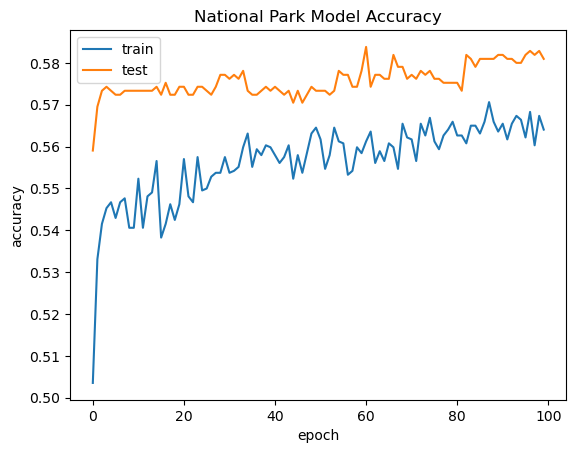

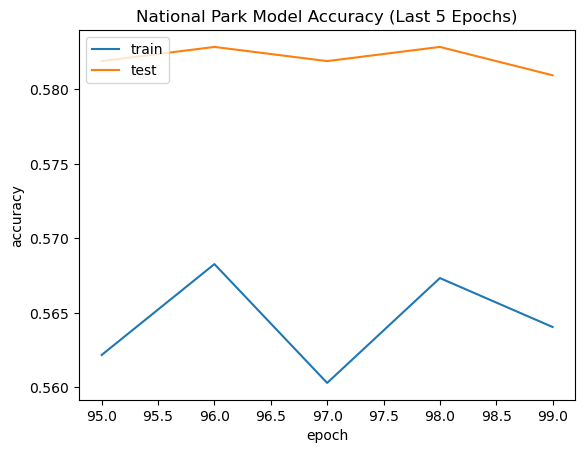

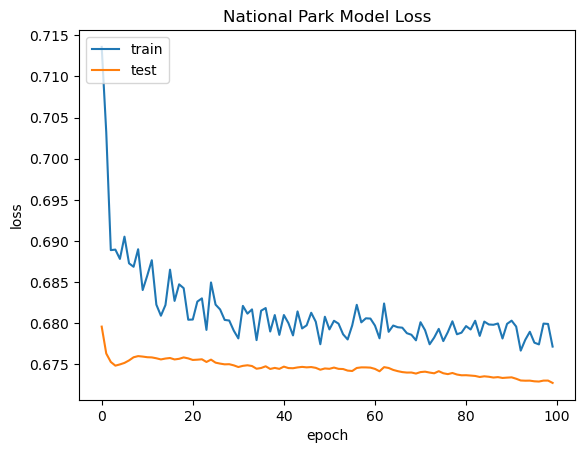

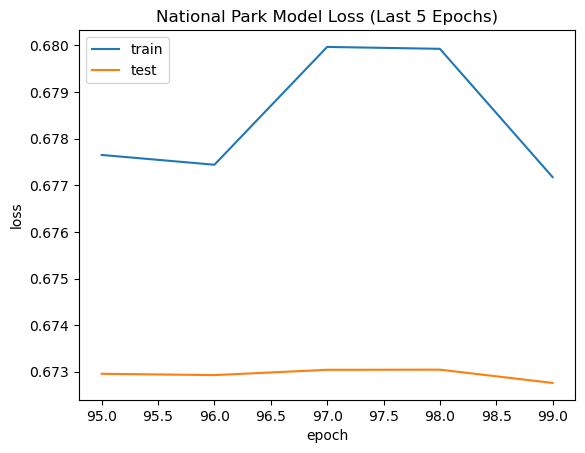

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6042    0.1593    0.2522       364
           1     0.5629    0.9120    0.6961       432

    accuracy                         0.5678       796
   macro avg     0.5835    0.5357    0.4741       796
weighted avg     0.5817    0.5678    0.4931       796



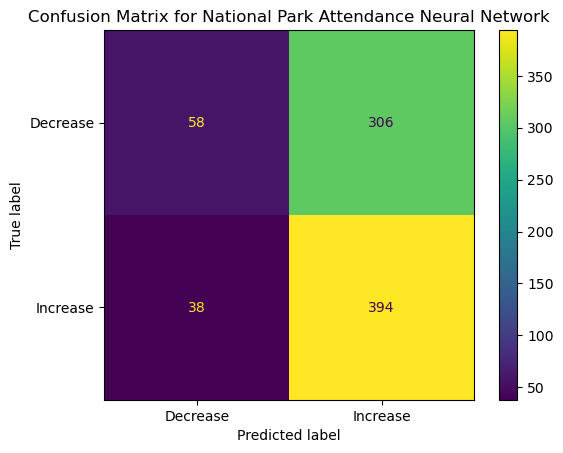

In [128]:
# Model Nodes: 4 / National Park / Adam / 0.001 / 100 / 10
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 1, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.4031856 ,  0.4992899 ,  0.04892459,  0.3846149 ],
       [-0.05427967, -0.07106957,  0.2884975 , -0.24460566],
       [-0.10407456, -0.10929865, -0.17406839, -0.2635685 ],
       [ 0.5567669 ,  0.21553268, -0.8603991 ,  0.11920154]],
      dtype=float32), array([ 0.26109394,  0.45520318, -0.6882449 , -0.7053675 ], dtype=float32), array([[ 0.23598354],
       [ 0.22266974],
       [-0.2805144 ],
       [-0.32259724]], dtype=float32), array([0.07090234], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5806 - loss: 0.6737
Accuracy: 0.5806350111961365, Loss: 0.6737425327301025
Trained Model Weights: /n [array([[ 0.14914587,  0.5060273 ,  0.10881411,  0.48372957],
       [-0.04028042, -0.1646027 , -0.00640679, -0.15230636],
       [-0.2769176 , -0.01857829, -0.04602212, -0.15487707],
       [ 0.5806908 ,  0.05413416, -1.6286513 , -0.18686874]],
      dtype=float32), array([-0.00549964,  0.30424017, -1.7564692 , -1.0777785 ], dtype=

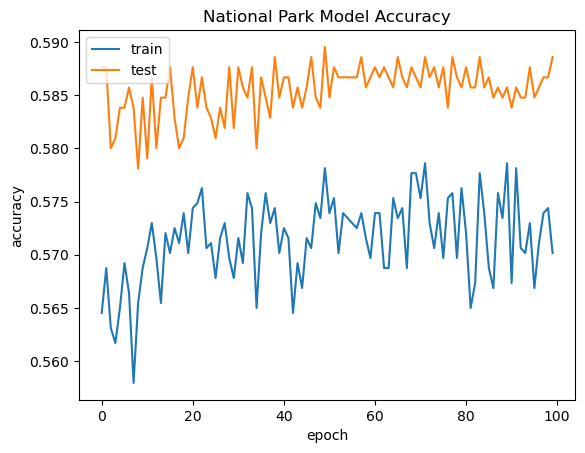

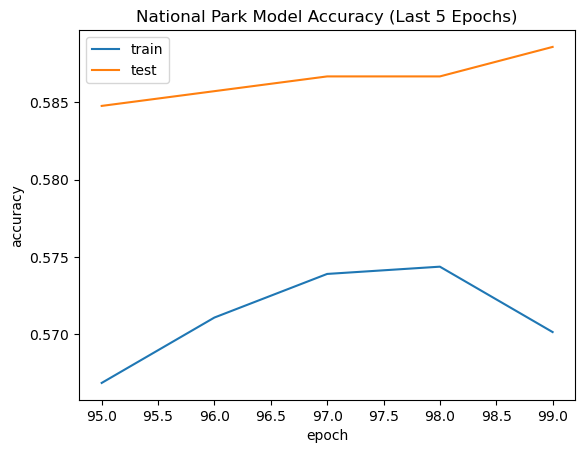

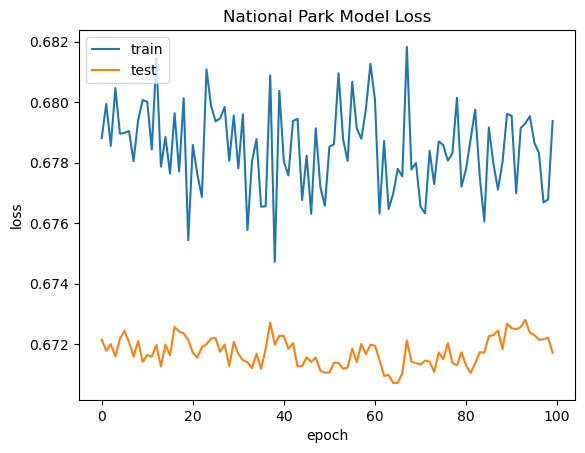

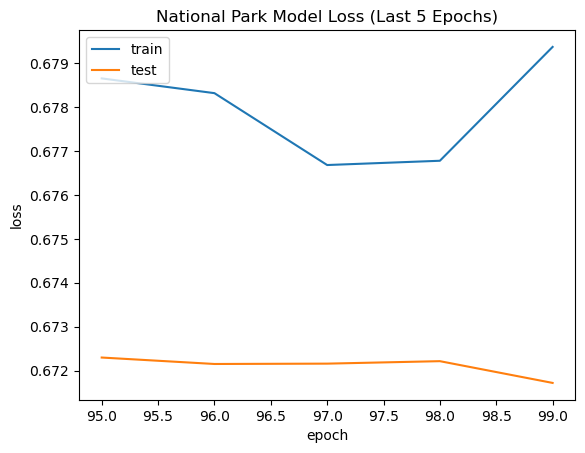

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



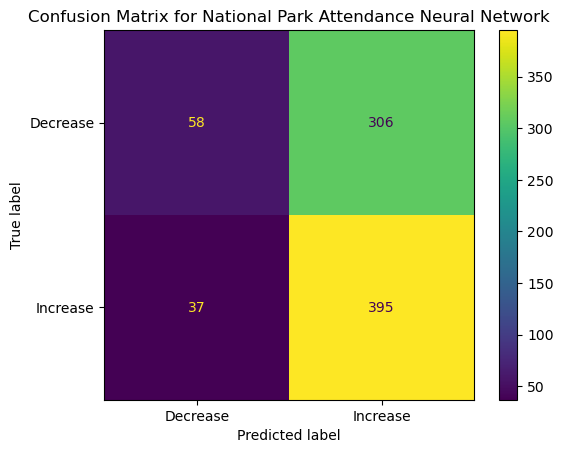

In [129]:
# Model Nodes: 4 / National Park / SGD / 0.001 / 100 / 10
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 1, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.14914587,  0.5060273 ,  0.10881411,  0.48372957],
       [-0.04028042, -0.1646027 , -0.00640679, -0.15230636],
       [-0.2769176 , -0.01857829, -0.04602212, -0.15487707],
       [ 0.5806908 ,  0.05413416, -1.6286513 , -0.18686874]],
      dtype=float32), array([-0.00549964,  0.30424017, -1.7564692 , -1.0777785 ], dtype=float32), array([[ 0.36756447],
       [ 0.27660638],
       [-0.71643776],
       [-0.52087647]], dtype=float32), array([0.19433674], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5831 - loss: 0.6727
Accuracy: 0.5831499695777893, Loss: 0.6726712584495544
Trained Model Weights: /n [array([[ 0.17062236,  0.54489666,  0.07968557,  0.40900207],
       [-0.02647461, -0.2401369 , -0.00364992, -0.21379459],
       [-0.2777123 , -0.00769741, -0.02056596, -0.19095482],
       [ 0.5632604 ,  0.07923993, -1.6396286 , -0.19260554]],
      dtype=float32), array([-3.7108074e-04,  3.0449316e-01, -1.7887442e+00, -1.1319245e

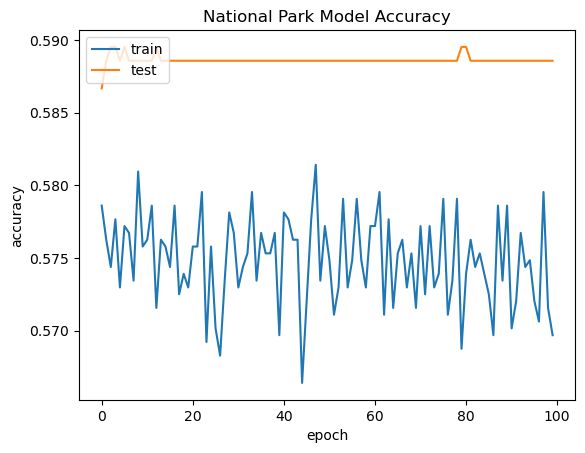

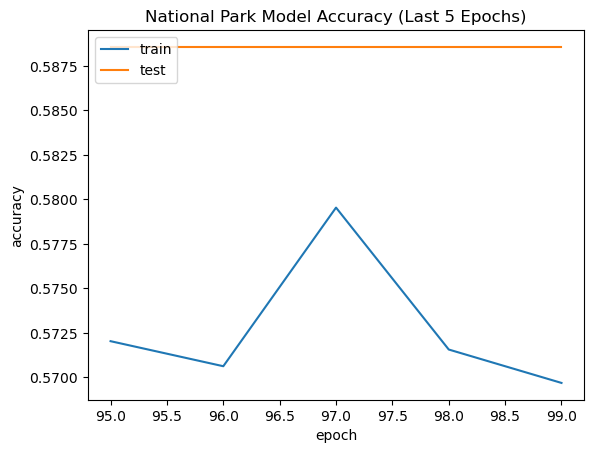

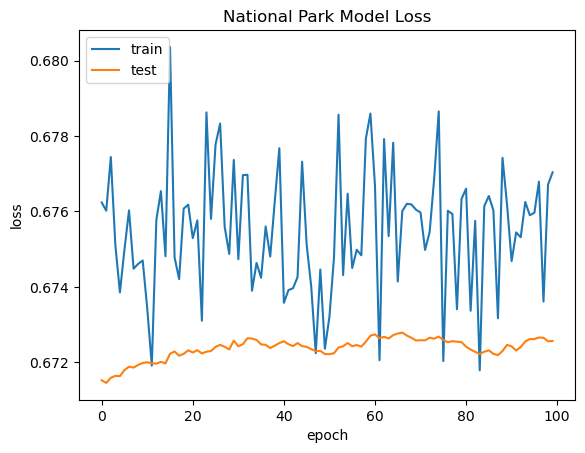

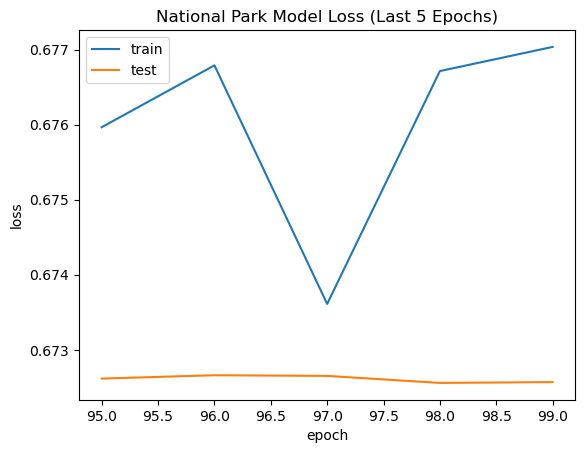

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6042    0.1593    0.2522       364
           1     0.5629    0.9120    0.6961       432

    accuracy                         0.5678       796
   macro avg     0.5835    0.5357    0.4741       796
weighted avg     0.5817    0.5678    0.4931       796



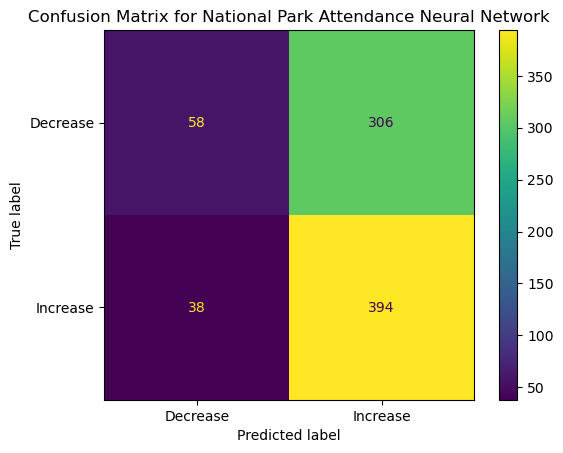

In [130]:
# Model Nodes: 4 / National Park / Adam / 0.001 / 100 / 32
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 1, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 0.17062236,  0.54489666,  0.07968557,  0.40900207],
       [-0.02647461, -0.2401369 , -0.00364992, -0.21379459],
       [-0.2777123 , -0.00769741, -0.02056596, -0.19095482],
       [ 0.5632604 ,  0.07923993, -1.6396286 , -0.19260554]],
      dtype=float32), array([-3.7108074e-04,  3.0449316e-01, -1.7887442e+00, -1.1319245e+00],
      dtype=float32), array([[ 0.34818283],
       [ 0.3097422 ],
       [-0.8296296 ],
       [-0.44158655]], dtype=float32), array([0.09073366], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5825 - loss: 0.6727
Accuracy: 0.5825212001800537, Loss: 0.6726720929145813
Trained Model Weights: /n [array([[ 0.13774838,  0.55066514,  0.06959876,  0.3904127 ],
       [-0.05781425, -0.18978114, -0.00318682, -0.2264816 ],
       [-0.2823281 , -0.00177817, -0.01220239, -0.18839188],
       [ 0.57146335,  0.05559045, -1.6927832 , -0.23402642]],
      dtype=float32), array([-0.01178932,  0.3262929 , -1.8465353 , -1

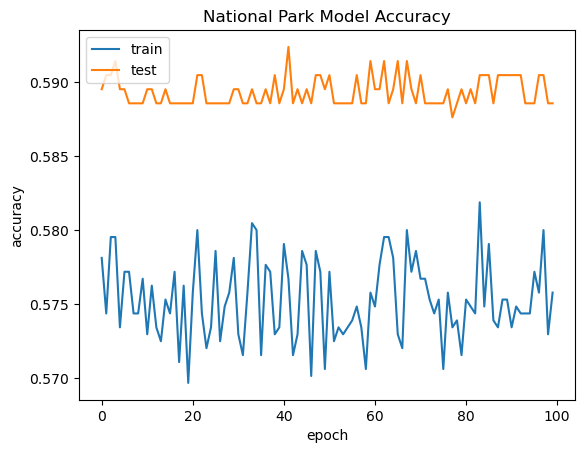

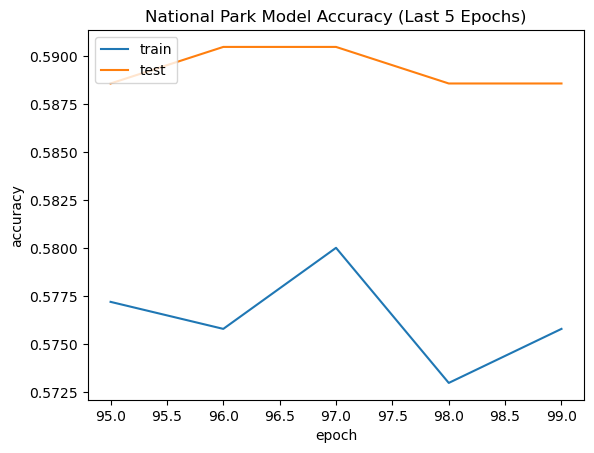

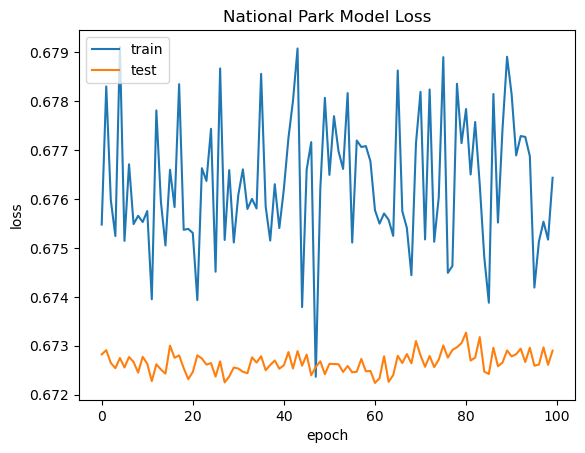

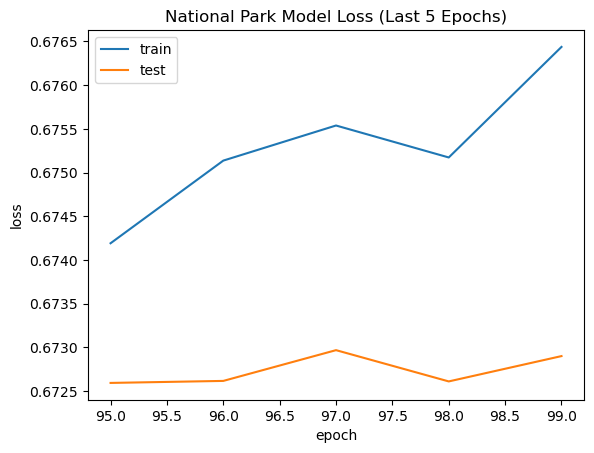

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

 Classification Report:

               precision    recall  f1-score   support

           0     0.6042    0.1593    0.2522       364
           1     0.5629    0.9120    0.6961       432

    accuracy                         0.5678       796
   macro avg     0.5835    0.5357    0.4741       796
weighted avg     0.5817    0.5678    0.4931       796



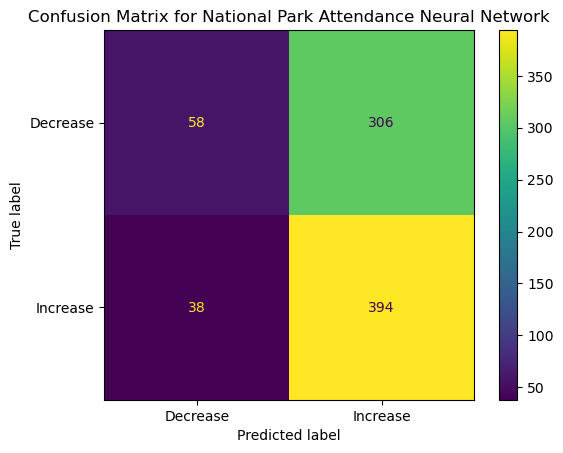

In [131]:
# Model Nodes: 4 / National Park / SGD / 0.001 / 100 / 32
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 1, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 0.13774838,  0.55066514,  0.06959876,  0.3904127 ],
       [-0.05781425, -0.18978114, -0.00318682, -0.2264816 ],
       [-0.2823281 , -0.00177817, -0.01220239, -0.18839188],
       [ 0.57146335,  0.05559045, -1.6927832 , -0.23402642]],
      dtype=float32), array([-0.01178932,  0.3262929 , -1.8465353 , -1.1513988 ], dtype=float32), array([[ 0.34754473],
       [ 0.3192763 ],
       [-0.8560331 ],
       [-0.4446542 ]], dtype=float32), array([0.08573333], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5781 - loss: 0.6739
Accuracy: 0.5781201124191284, Loss: 0.6738590598106384
Trained Model Weights: /n [array([[ 0.24190022,  0.79362595,  0.21763808,  0.7237926 ],
       [-0.06893053, -0.22839917,  0.01840647, -0.18814866],
       [-0.385912  , -0.03725544, -0.08159895, -0.5489505 ],
       [ 0.770773  ,  0.20808342, -2.505331  , -1.0979432 ]],
      dtype=float32), array([ 0.07266574,  0.5354383 , -2.7724123 , -2.654169  ], dtype=

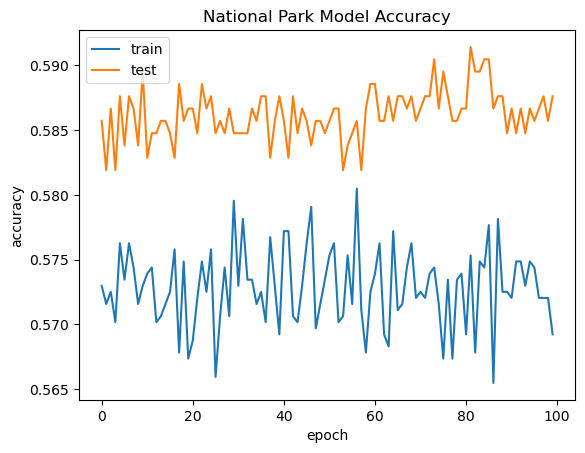

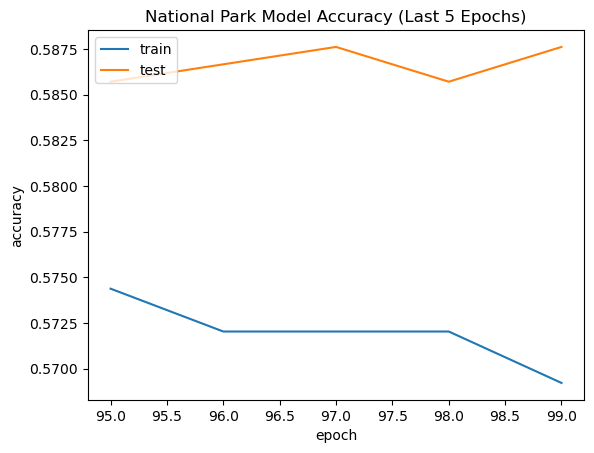

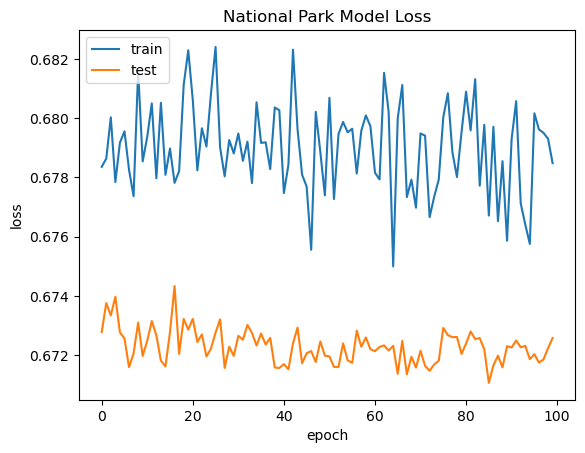

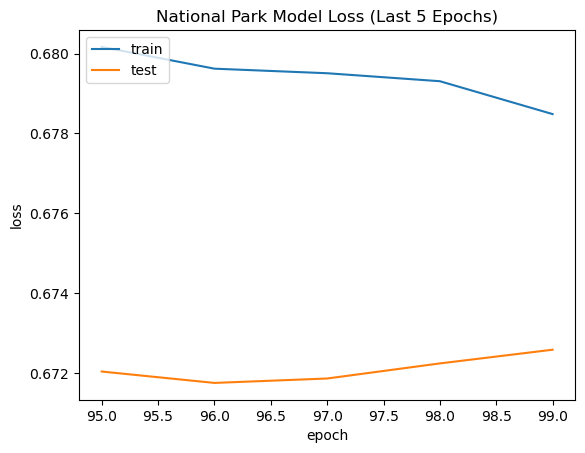

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



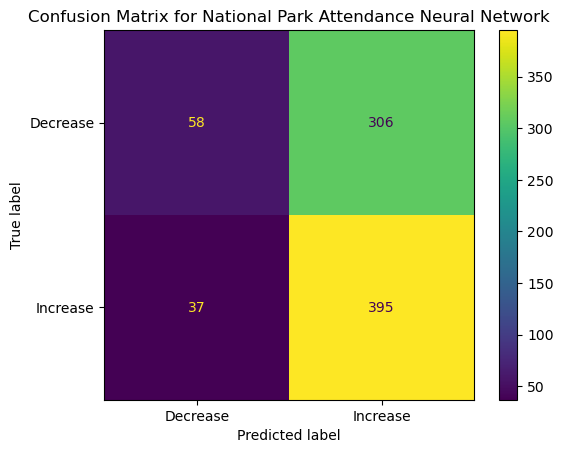

In [132]:
# Model Nodes: 4 / National Park / Adam / 0.01 / 100 / 10
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.24190022,  0.79362595,  0.21763808,  0.7237926 ],
       [-0.06893053, -0.22839917,  0.01840647, -0.18814866],
       [-0.385912  , -0.03725544, -0.08159895, -0.5489505 ],
       [ 0.770773  ,  0.20808342, -2.505331  , -1.0979432 ]],
      dtype=float32), array([ 0.07266574,  0.5354383 , -2.7724123 , -2.654169  ], dtype=float32), array([[ 0.2091232 ],
       [ 0.22956382],
       [-0.37959537],
       [-0.22554937]], dtype=float32), array([0.13766403], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5822 - loss: 0.6732
Accuracy: 0.5822068452835083, Loss: 0.6732400059700012
Trained Model Weights: /n [array([[ 0.19977435,  0.49933097,  0.10126252,  0.80304223],
       [-0.06562761, -0.08895886, -0.11212904,  0.02005932],
       [-0.2769033 , -0.02771006, -0.00383209, -0.47780967],
       [ 0.6068697 ,  0.09275588, -2.62668   , -1.2368087 ]],
      dtype=float32), array([ 0.05005344,  0.38480726, -2.8795784 , -2.54652   ], dtype=

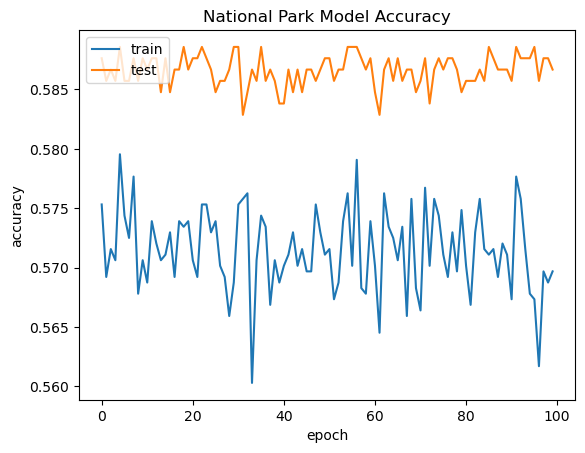

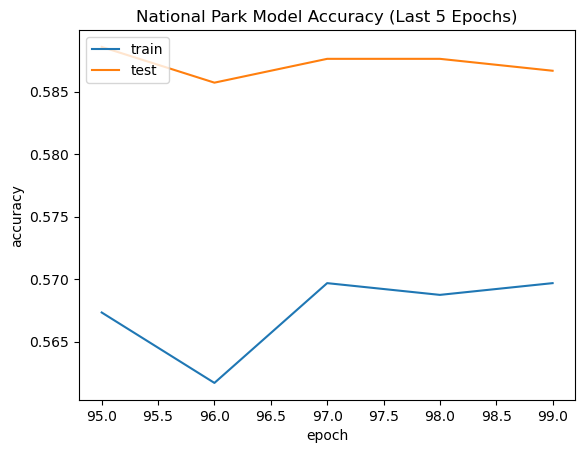

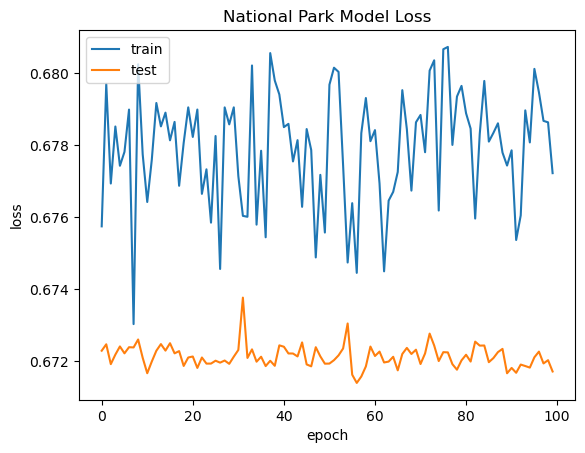

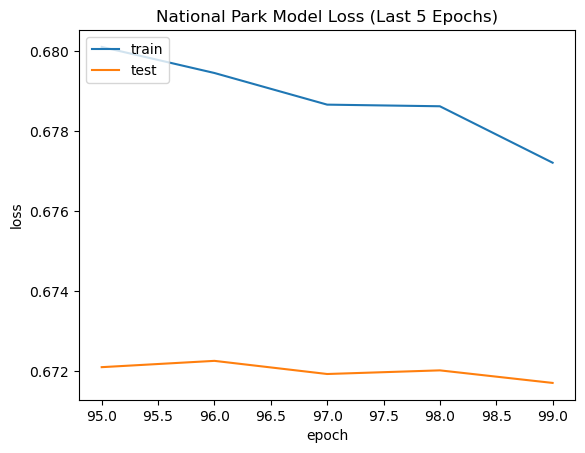

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



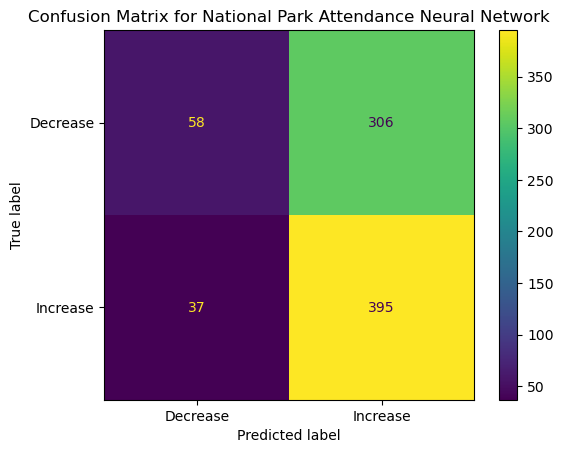

In [133]:
# Model Nodes: 4 / National Park / SGD / 0.01 / 100 / 10
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.19977435,  0.49933097,  0.10126252,  0.80304223],
       [-0.06562761, -0.08895886, -0.11212904,  0.02005932],
       [-0.2769033 , -0.02771006, -0.00383209, -0.47780967],
       [ 0.6068697 ,  0.09275588, -2.62668   , -1.2368087 ]],
      dtype=float32), array([ 0.05005344,  0.38480726, -2.8795784 , -2.54652   ], dtype=float32), array([[ 0.37253156],
       [ 0.27797353],
       [-0.48242027],
       [-0.2811273 ]], dtype=float32), array([0.15998743], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5835 - loss: 0.6732
Accuracy: 0.5834643244743347, Loss: 0.6731786727905273
Trained Model Weights: /n [array([[ 0.1624674 ,  0.74467516,  0.13445888,  0.6777438 ],
       [-0.05900583, -0.29651362,  0.02239405, -0.38975507],
       [-0.386955  ,  0.0068969 ,  0.02348679, -0.2587469 ],
       [ 0.7962516 ,  0.08426644, -2.7990758 , -1.6384236 ]],
      dtype=float32), array([-0.01017283,  0.41974196, -3.064993  , -2.9170973 ], dtype=

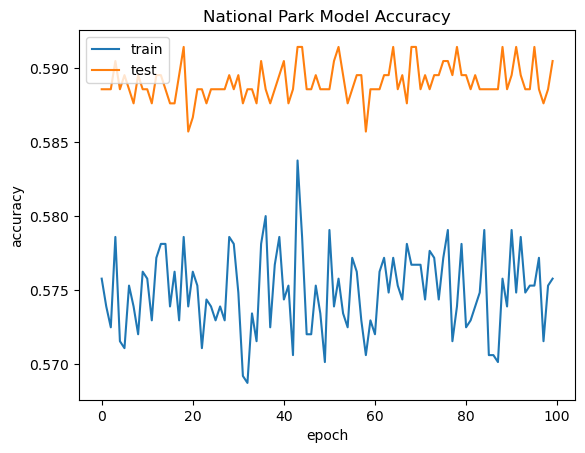

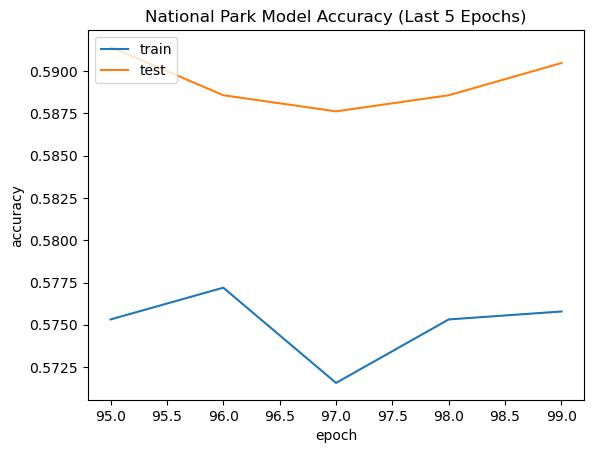

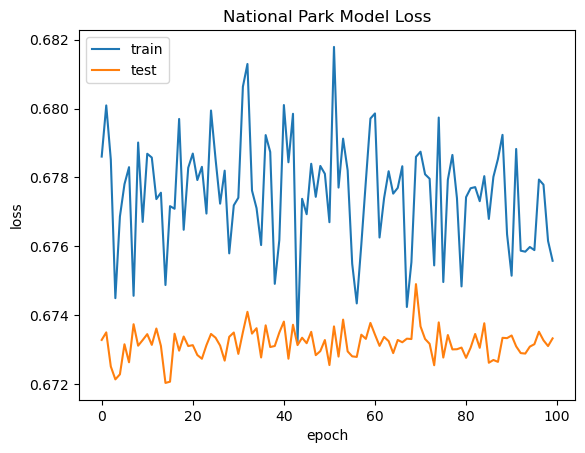

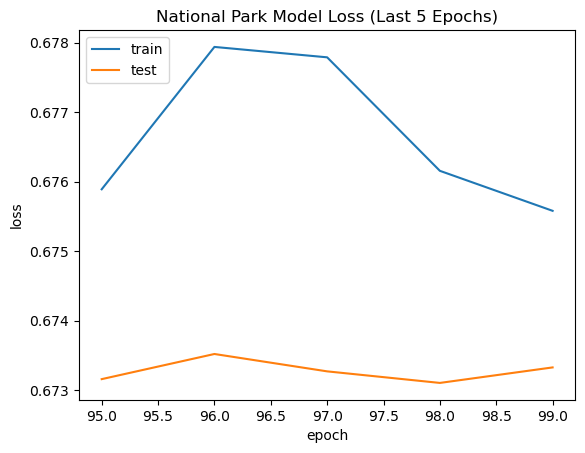

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.5760    0.1978    0.2945       364
           1     0.5648    0.8773    0.6872       432

    accuracy                         0.5666       796
   macro avg     0.5704    0.5376    0.4908       796
weighted avg     0.5699    0.5666    0.5076       796



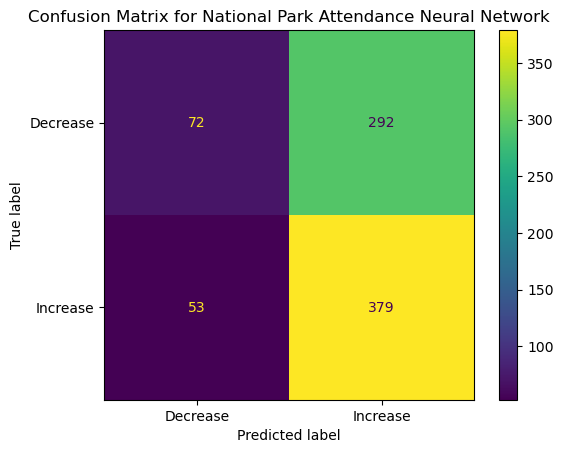

In [134]:
# Model Nodes: 4 / National Park / Adam / 0.01 / 100 / 32
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 0.1624674 ,  0.74467516,  0.13445888,  0.6777438 ],
       [-0.05900583, -0.29651362,  0.02239405, -0.38975507],
       [-0.386955  ,  0.0068969 ,  0.02348679, -0.2587469 ],
       [ 0.7962516 ,  0.08426644, -2.7990758 , -1.6384236 ]],
      dtype=float32), array([-0.01017283,  0.41974196, -3.064993  , -2.9170973 ], dtype=float32), array([[ 0.27811614],
       [ 0.20136712],
       [-0.5133767 ],
       [-0.34968853]], dtype=float32), array([0.08057585], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5822 - loss: 0.6731  
Accuracy: 0.5822068452835083, Loss: 0.6731256246566772
Trained Model Weights: /n [array([[ 0.1392371 ,  0.6694013 ,  0.10536928,  0.7072028 ],
       [-0.05134283, -0.2290871 , -0.04640993, -0.31430304],
       [-0.32781664, -0.02587626,  0.03837174, -0.27595192],
       [ 0.7456285 ,  0.07026193, -2.753884  , -1.6453878 ]],
      dtype=float32), array([-0.06644695,  0.38316968, -3.1314194 , -2.9027467 ], dtyp

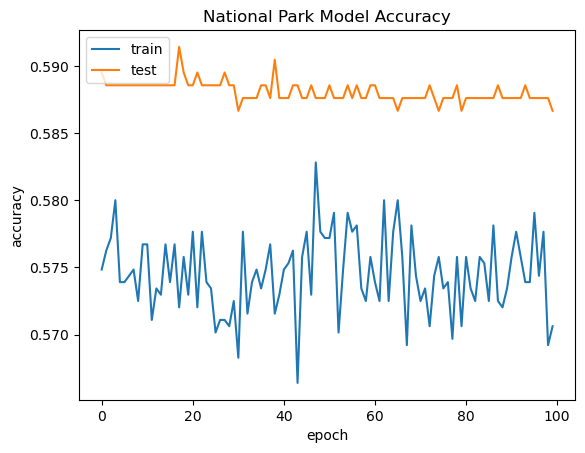

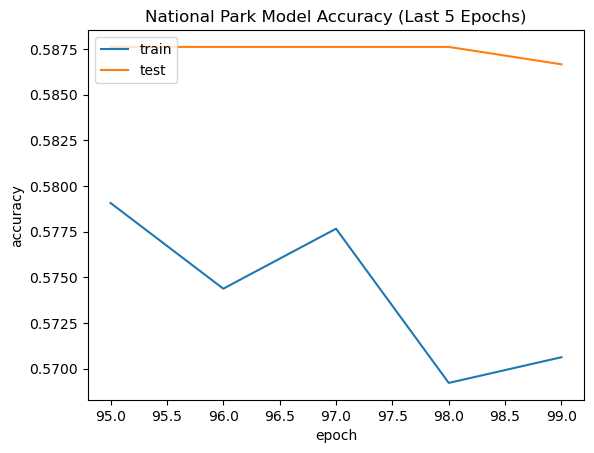

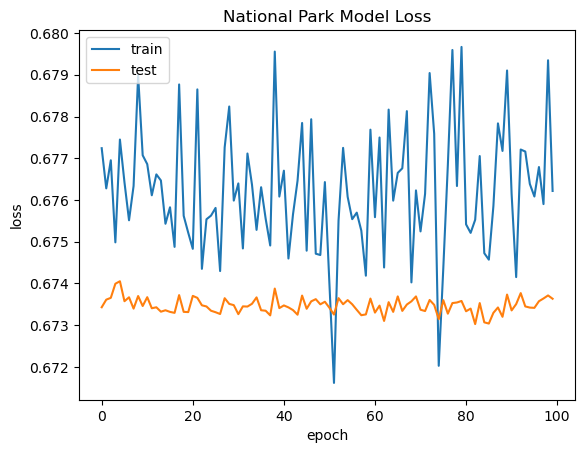

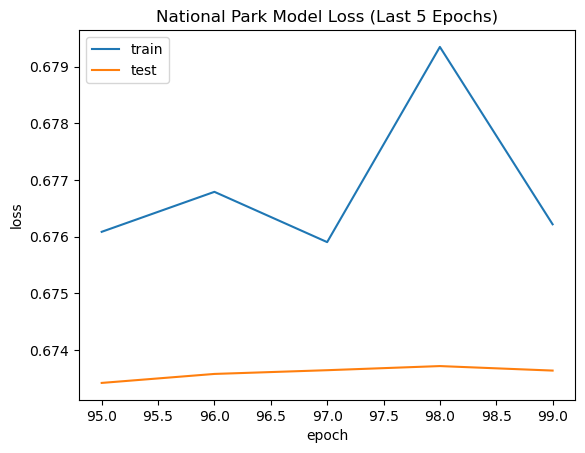

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



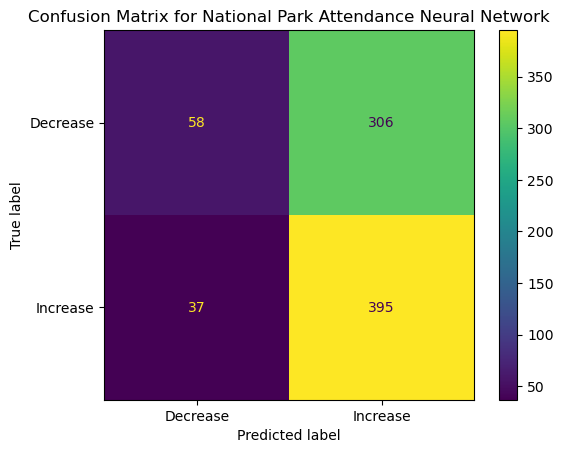

In [135]:
# Model Nodes: 4 / National Park / SGD / 0.01 / 100 / 32
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 100, batch = 32)

#### 6 Node Models

Initial Model Weights: 
 [array([[ 0.48946404,  0.21136886,  0.00180835,  0.2838688 ,  0.5568752 ,
         0.29437637],
       [ 0.5700339 ,  0.61097085, -0.47571507,  0.27822995, -0.40445054,
         0.36996984],
       [-0.1709243 , -0.22029883, -0.03574759, -0.6402294 , -0.39364353,
        -0.03198075],
       [ 0.61354005, -0.2160508 ,  0.08597827, -0.12663186,  0.69619215,
         0.51485026]], dtype=float32), array([0., 0., 0., 0., 0., 0.], dtype=float32), array([[ 0.64363325],
       [-0.44802627],
       [-0.13754869],
       [ 0.18723702],
       [ 0.8594074 ],
       [-0.2900108 ]], dtype=float32), array([0.], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5938 - loss: 0.6717
Accuracy: 0.5938383936882019, Loss: 0.6716951727867126
Trained Model Weights: /n [array([[ 0.5109043 ,  0.07603489, -0.9248733 , -0.02918832,  0.13350333,
         0.16345343],
       [-0.04245216,  0.04034251, -0.04668368,  0.00096597, -0.04266221,
         0.37407765],
     

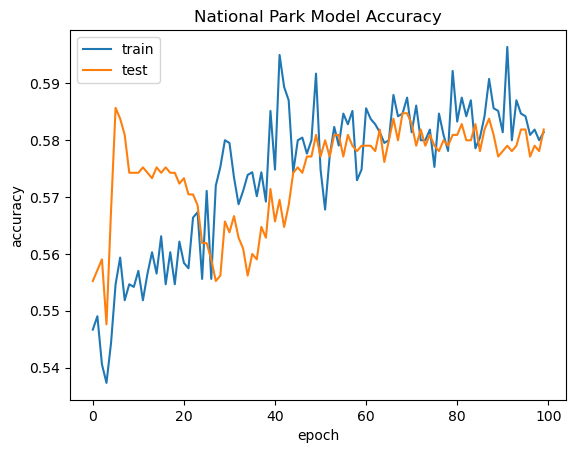

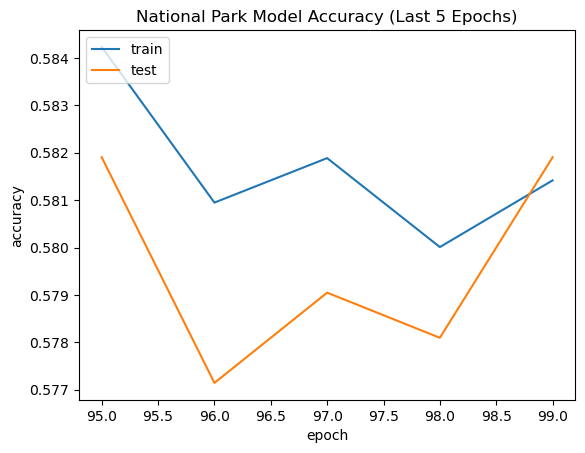

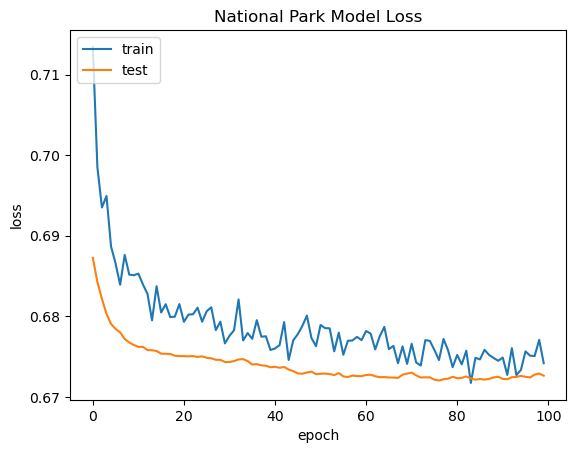

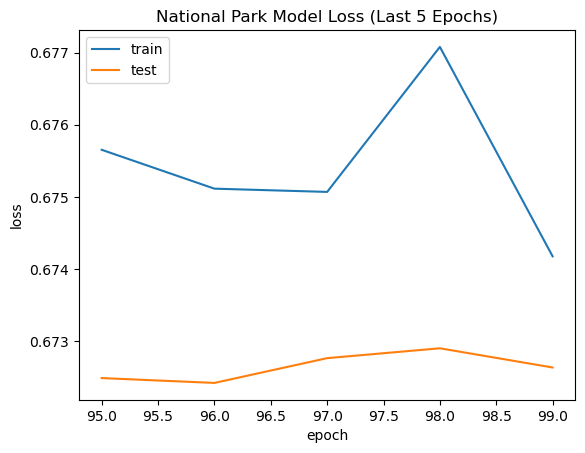

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



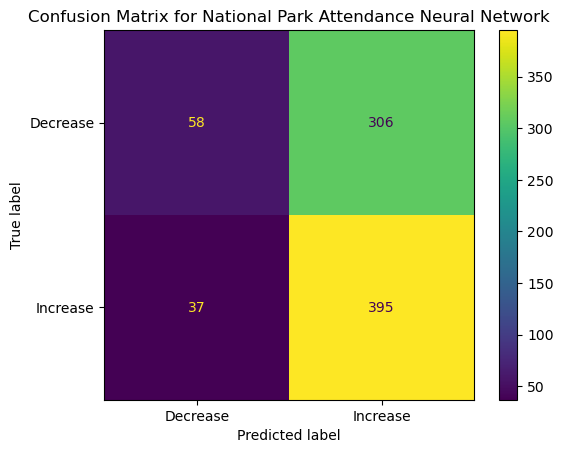

In [136]:
# Model Nodes: 6 / National Park / Adam / 0.001 / 100 / 10
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 1, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.5109043 ,  0.07603489, -0.9248733 , -0.02918832,  0.13350333,
         0.16345343],
       [-0.04245216,  0.04034251, -0.04668368,  0.00096597, -0.04266221,
         0.37407765],
       [ 0.23207632, -0.07379992,  0.14613041, -0.7462058 , -0.24417064,
         0.00989863],
       [ 0.30842537, -0.7370743 , -0.08472411, -0.08124074,  0.48560283,
         0.25317875]], dtype=float32), array([ 0.17018986, -0.71196353, -0.08064531,  0.01898085,  0.01134777,
       -0.39215046], dtype=float32), array([[ 0.24674667],
       [-0.8806083 ],
       [-0.47206977],
       [ 0.13012864],
       [ 0.23362015],
       [-0.14343482]], dtype=float32), array([0.23975953], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5885 - loss: 0.6717
Accuracy: 0.5884941816329956, Loss: 0.6716877818107605
Trained Model Weights: /n [array([[ 0.52060574,  0.1140618 , -1.5079154 , -0.03939667,  0.07596032,
         0.08396554],
       [-0.07571838, -0.0109391

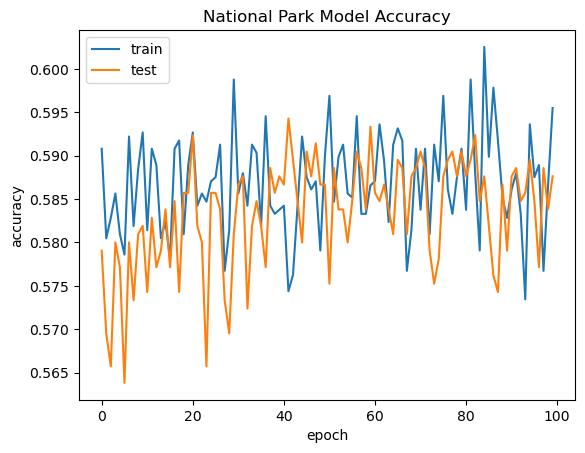

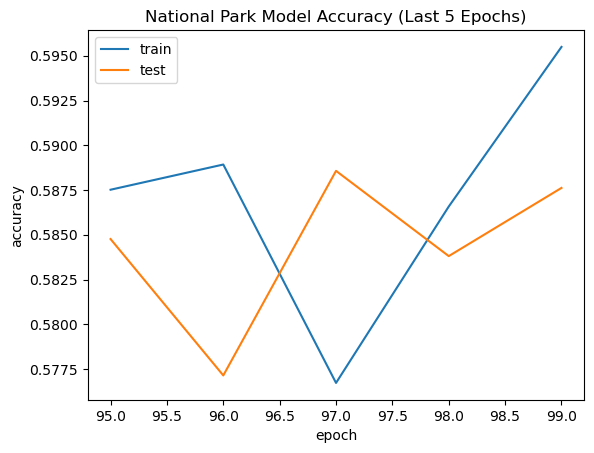

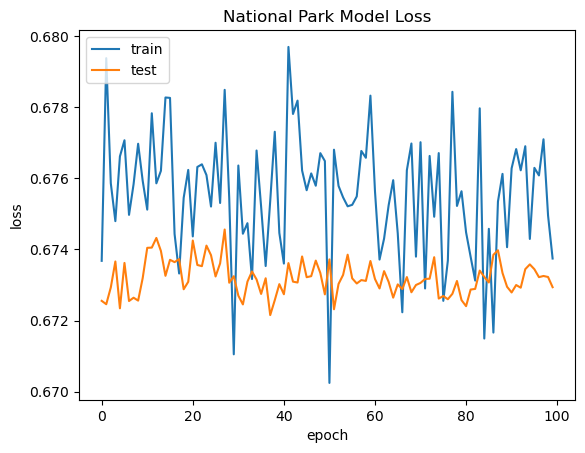

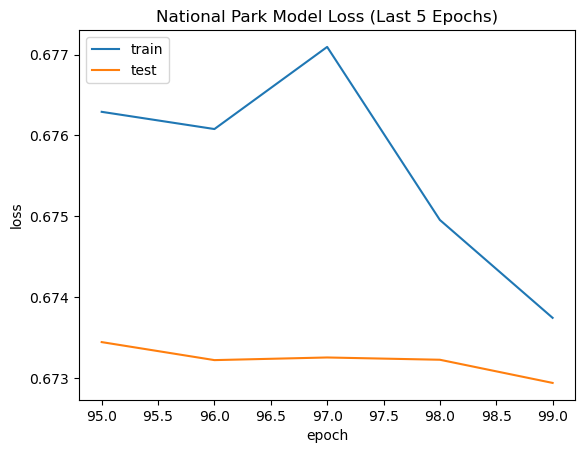

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



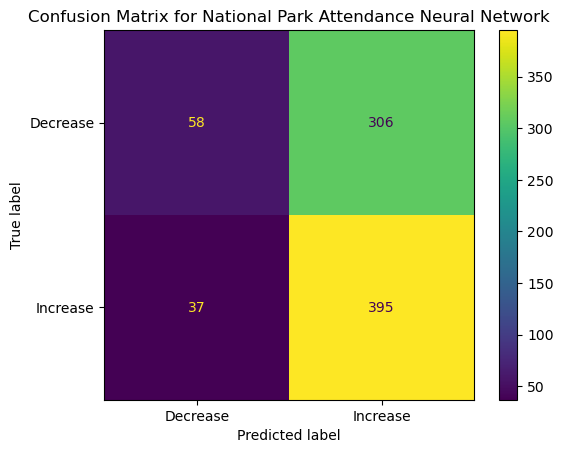

In [137]:
# Model Nodes: 6 / National Park / SGD / 0.001 / 100 / 10
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 1, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.52060574,  0.1140618 , -1.5079154 , -0.03939667,  0.07596032,
         0.08396554],
       [-0.07571838, -0.01093918, -0.03914448, -0.08260002, -0.00748431,
         0.33582535],
       [ 0.24830247, -0.10289765,  0.29919937, -0.49367833, -0.25113928,
         0.11411344],
       [ 0.10828444, -1.6641477 , -0.19962537, -0.08761403,  0.5600766 ,
         0.01275156]], dtype=float32), array([-8.2478616e-03, -1.7806482e+00, -5.5004781e-01,  1.3878723e-03,
       -4.7362294e-02, -2.4699378e-01], dtype=float32), array([[ 0.24499518],
       [-0.75065607],
       [-0.41454238],
       [ 0.16657323],
       [ 0.2876017 ],
       [-0.1664869 ]], dtype=float32), array([0.34069595], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5970 - loss: 0.6699
Accuracy: 0.5969820618629456, Loss: 0.6698974967002869
Trained Model Weights: /n [array([[ 5.4860079e-01,  7.5615942e-02, -1.5497499e+00, -2.6457146e-02,
         9.2477784e-02,  1.1404928e-

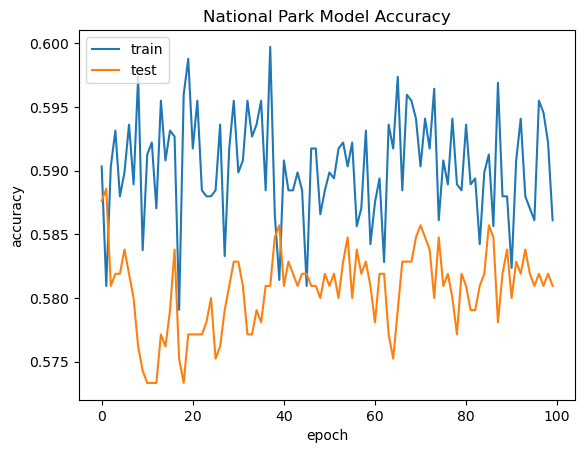

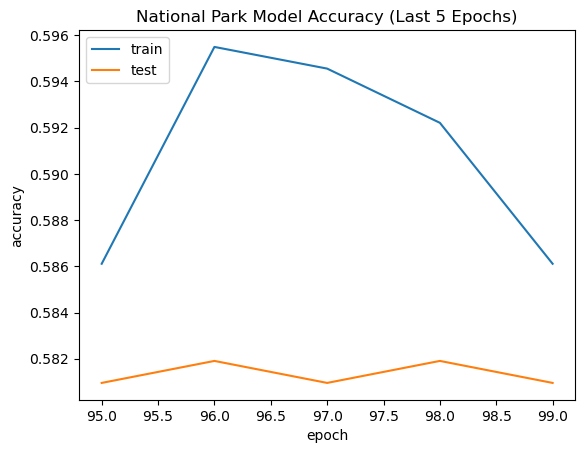

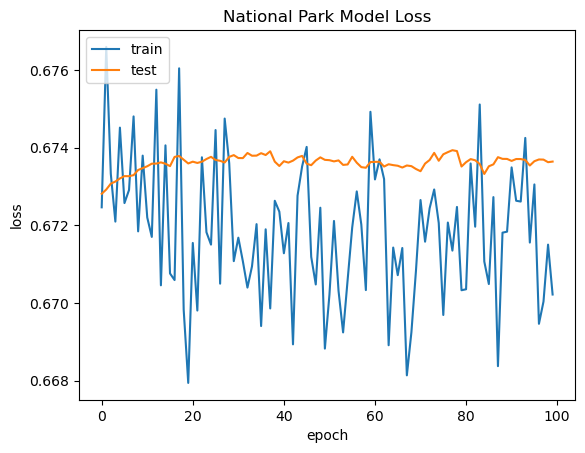

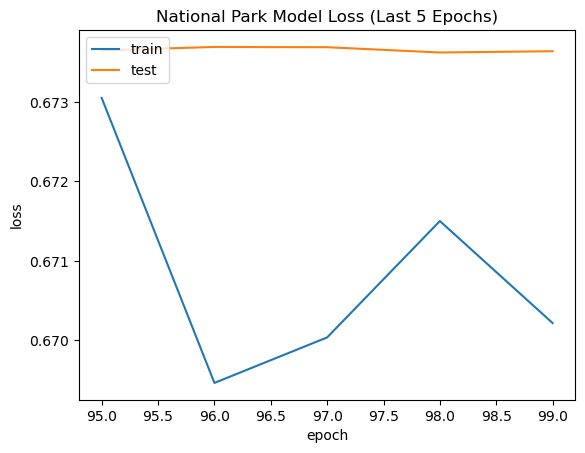

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



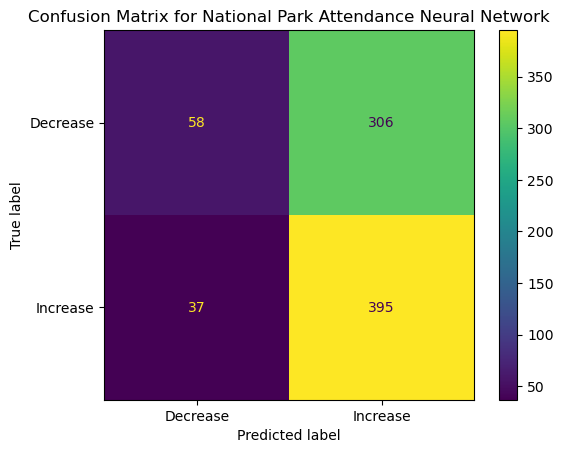

In [138]:
# Model Nodes: 6 / National Park / Adam / 0.001 / 100 / 32
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 1, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 5.4860079e-01,  7.5615942e-02, -1.5497499e+00, -2.6457146e-02,
         9.2477784e-02,  1.1404928e-01],
       [-4.2208064e-02, -3.6881063e-02, -4.8280258e-02, -6.4339884e-02,
         1.1276315e-02,  3.8995829e-01],
       [ 3.0824885e-01, -4.2239264e-02,  2.8301412e-01, -5.5082560e-01,
        -2.4661364e-01,  1.4963092e-01],
       [ 9.6337520e-02, -1.6839458e+00, -2.5660479e-01, -6.8708211e-02,
         5.5785638e-01,  1.1885933e-03]], dtype=float32), array([-0.05725413, -1.8068343 , -0.54231447, -0.02429607, -0.04477251,
       -0.2547603 ], dtype=float32), array([[ 0.28504127],
       [-0.8675892 ],
       [-0.47348315],
       [ 0.19472612],
       [ 0.27840614],
       [-0.228085  ]], dtype=float32), array([0.2458237], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6008 - loss: 0.6700
Accuracy: 0.6007544994354248, Loss: 0.6699652671813965
Trained Model Weights: /n [array([[ 5.5710828e-01,  1.1791505e-01, -1.5659767e+00,

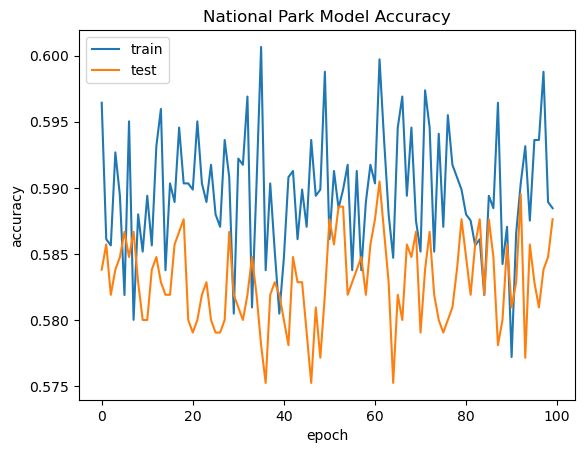

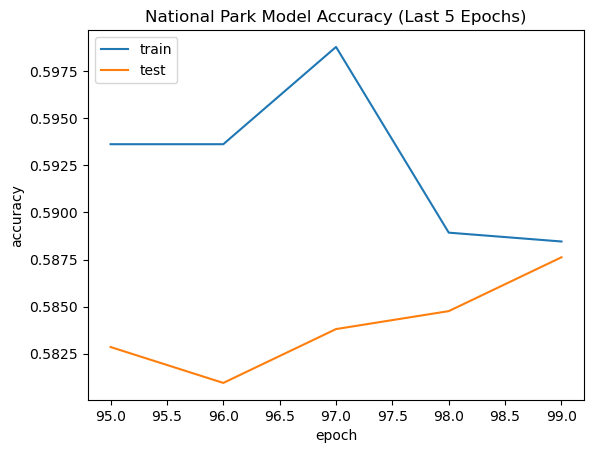

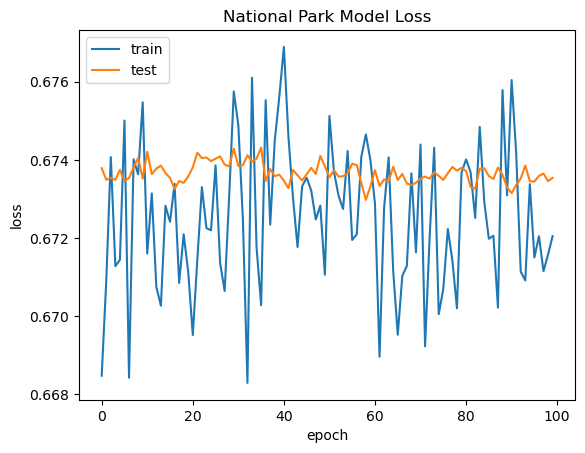

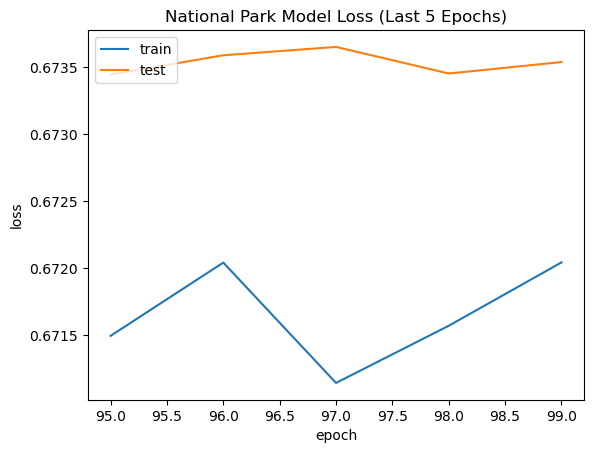

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



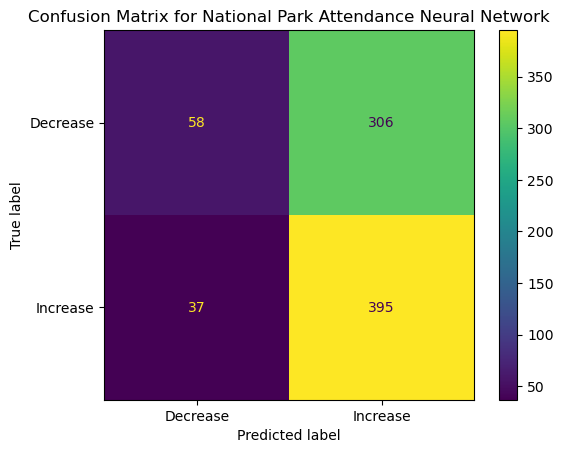

In [139]:
# Model Nodes: 6 / National Park / SGD / 0.001 / 100 / 32
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 1, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 5.5710828e-01,  1.1791505e-01, -1.5659767e+00, -2.8713604e-02,
         8.3847672e-02,  1.1526102e-01],
       [-4.3540630e-02, -6.0556006e-02, -5.0717469e-02, -7.1809284e-02,
        -1.3875870e-03,  3.8112938e-01],
       [ 3.1031534e-01, -1.7444575e-02,  2.9524463e-01, -5.3153384e-01,
        -2.4483672e-01,  1.5371840e-01],
       [ 1.0394243e-01, -1.7141063e+00, -2.4841683e-01, -5.2320402e-02,
         5.5611449e-01, -3.2382414e-03]], dtype=float32), array([-0.06178881, -1.8940618 , -0.56024885, -0.0361226 , -0.05197091,
       -0.2571337 ], dtype=float32), array([[ 0.31262738],
       [-0.90501606],
       [-0.46330994],
       [ 0.16038853],
       [ 0.27336413],
       [-0.2337893 ]], dtype=float32), array([0.2461322], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5891 - loss: 0.6683
Accuracy: 0.5891228914260864, Loss: 0.6683453321456909
Trained Model Weights: /n [array([[ 0.404073  ,  0.26244584, -2.4119484 ,  0.31094

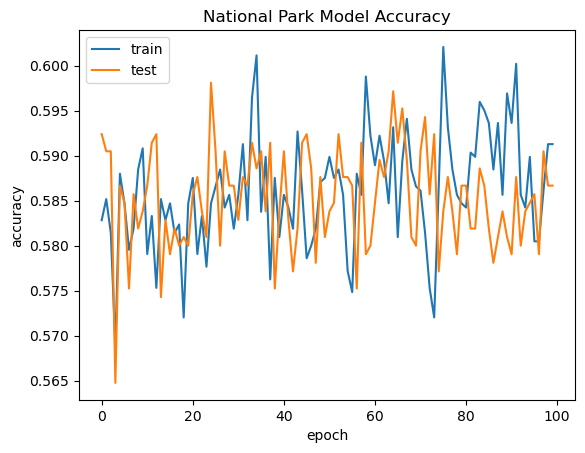

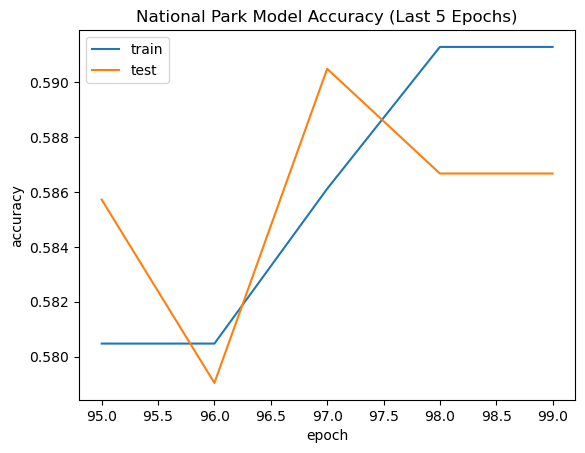

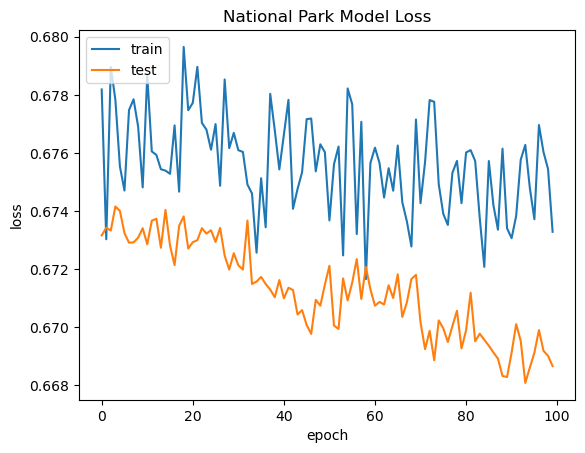

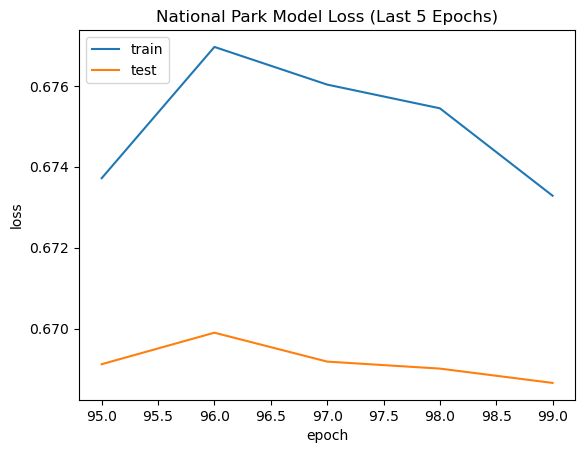

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



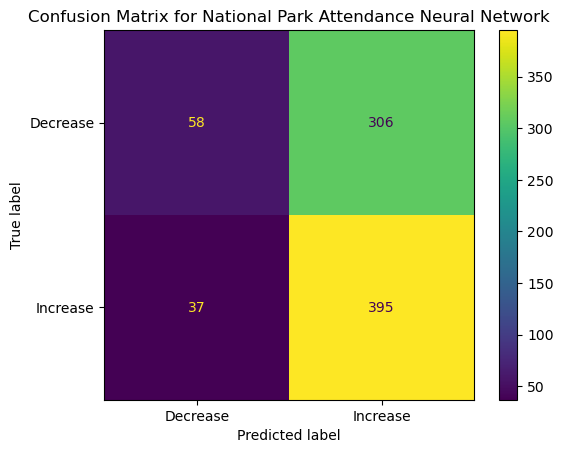

In [140]:
# Model Nodes: 6 / National Park / Adam / 0.01 / 100 / 10
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.404073  ,  0.26244584, -2.4119484 ,  0.31094983,  0.62455   ,
         0.73646367],
       [-0.6072449 , -0.03589055,  0.28521878, -0.2689401 , -0.11891261,
         0.4575082 ],
       [ 0.81331986, -0.13670991,  0.43684673, -2.1767077 ,  0.04060425,
        -0.67560565],
       [-0.7296556 , -2.5496247 , -0.3348375 ,  0.22718392,  0.59403557,
        -0.70703834]], dtype=float32), array([-1.5235298 , -2.7526433 , -0.833231  , -2.2548082 ,  0.08855361,
       -2.1915026 ], dtype=float32), array([[ 0.23694345],
       [-0.47657534],
       [-0.25691298],
       [ 0.68778133],
       [ 0.1910464 ],
       [-0.29148263]], dtype=float32), array([0.32191917], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5869 - loss: 0.6663
Accuracy: 0.5869223475456238, Loss: 0.666293740272522
Trained Model Weights: /n [array([[ 0.4570018 ,  0.16006258, -2.1368406 ,  0.20603043,  0.37609425,
         0.6351853 ],
       [-0.5856475 , -0.14314845

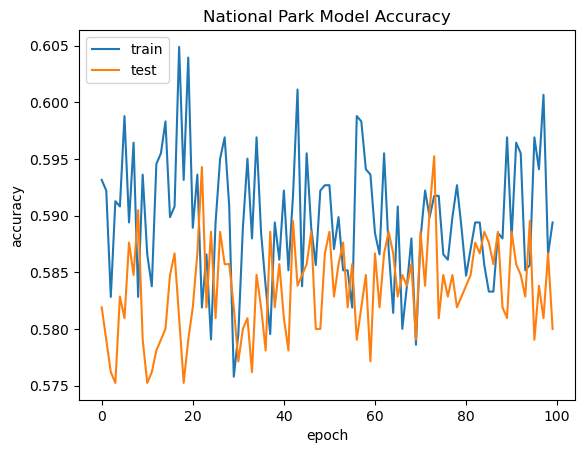

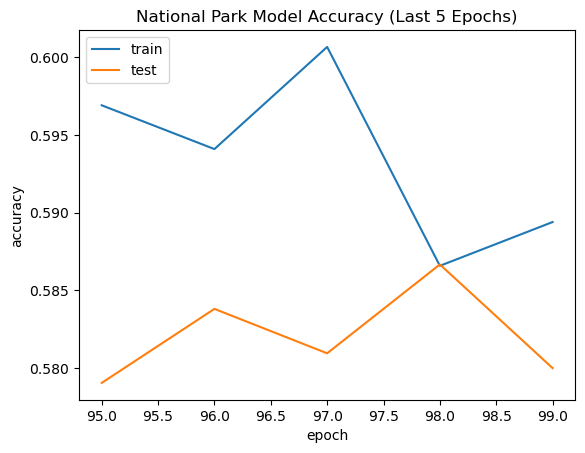

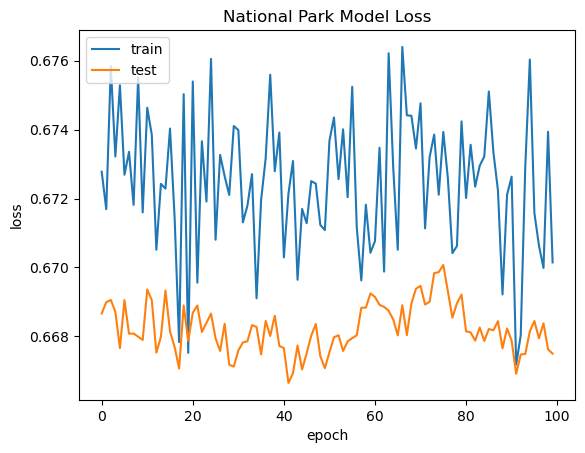

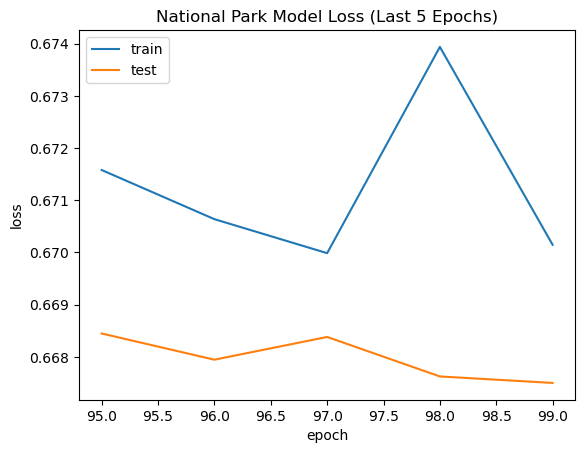

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



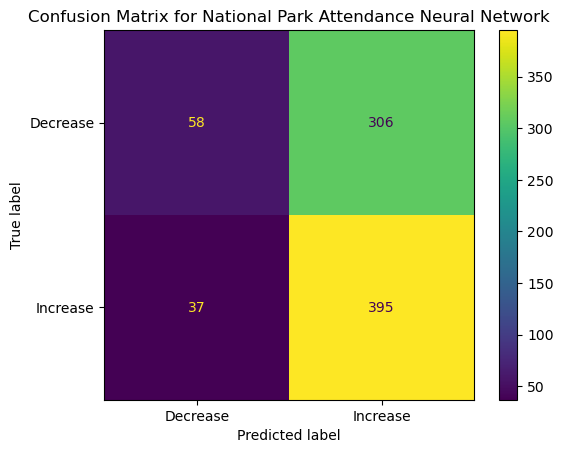

In [141]:
# Model Nodes: 6 / National Park / SGD / 0.01 / 100 / 10
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 100, batch = 10)

Initial Model Weights: 
 [array([[ 0.4570018 ,  0.16006258, -2.1368406 ,  0.20603043,  0.37609425,
         0.6351853 ],
       [-0.5856475 , -0.14314845,  0.2225531 , -0.30139688, -0.06684174,
         0.44333842],
       [ 0.89744323, -0.01243859,  0.4553064 , -2.4306974 ,  0.0282536 ,
        -0.49684396],
       [-0.74348533, -2.6795053 , -0.34825623,  0.19368407,  0.4340213 ,
        -0.87207264]], dtype=float32), array([-1.5871378 , -2.90731   , -0.7051514 , -2.626136  ,  0.03341003,
       -2.088369  ], dtype=float32), array([[ 0.37683666],
       [-0.59644246],
       [-0.3696813 ],
       [ 0.81143034],
       [ 0.2745556 ],
       [-0.2748844 ]], dtype=float32), array([0.35538757], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5951 - loss: 0.6666
Accuracy: 0.5950958728790283, Loss: 0.6665753126144409
Trained Model Weights: /n [array([[ 0.3999727 ,  0.20971663, -2.4430304 ,  0.25542814,  0.48514152,
         0.59540135],
       [-0.04406597, -0.0986032

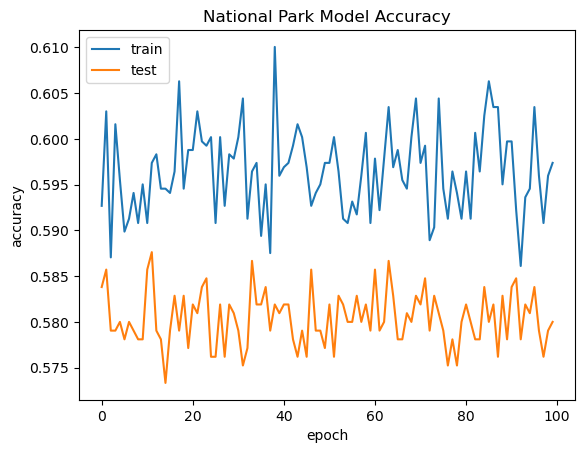

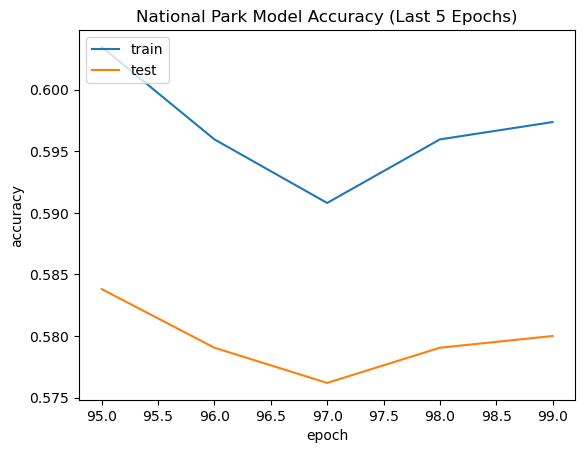

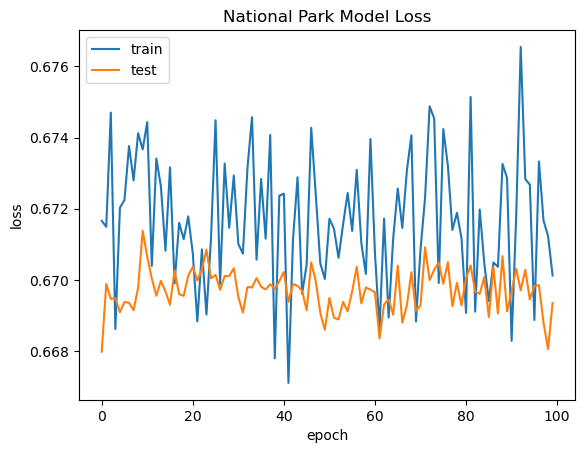

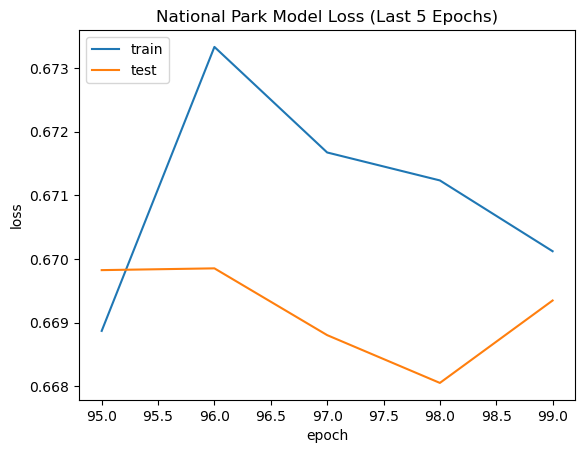

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



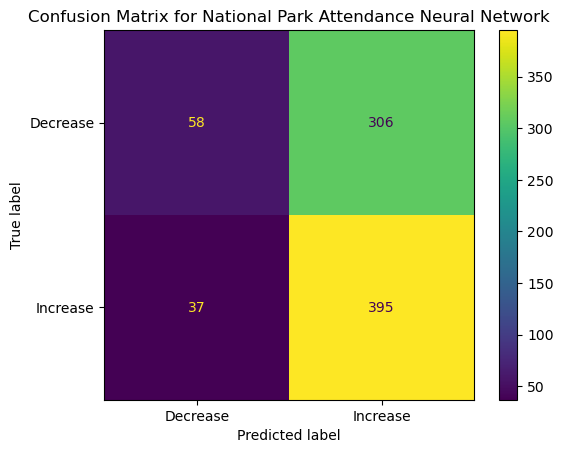

In [142]:
# Model Nodes: 6 / National Park / Adam / 0.01 / 100 / 32
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 0.3999727 ,  0.20971663, -2.4430304 ,  0.25542814,  0.48514152,
         0.59540135],
       [-0.04406597, -0.09860324,  0.22465046, -0.3068829 , -0.1107043 ,
         0.49923617],
       [ 1.0977248 , -0.01680411,  0.55103385, -2.688591  ,  0.05983717,
        -0.56982243],
       [-1.0189517 , -2.8105168 , -0.43018577,  0.24725136,  0.6220472 ,
        -0.79866266]], dtype=float32), array([-1.8062446 , -3.1144023 , -0.80174804, -3.055547  ,  0.09139242,
       -2.013069  ], dtype=float32), array([[ 0.28358594],
       [-0.57285714],
       [-0.32613432],
       [ 0.71438134],
       [ 0.18489721],
       [-0.24794748]], dtype=float32), array([0.28384542], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6048 - loss: 0.6655
Accuracy: 0.6048412322998047, Loss: 0.6655041575431824
Trained Model Weights: /n [array([[ 0.32580554,  0.14252295, -2.4246519 ,  0.32428116,  0.51381433,
         0.604247  ],
       [-0.12825732, -0.1207683

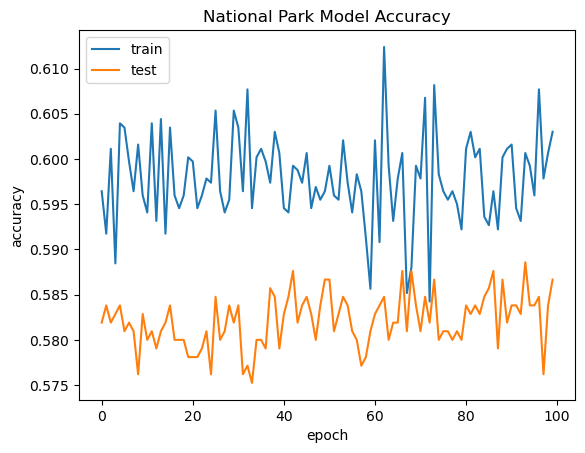

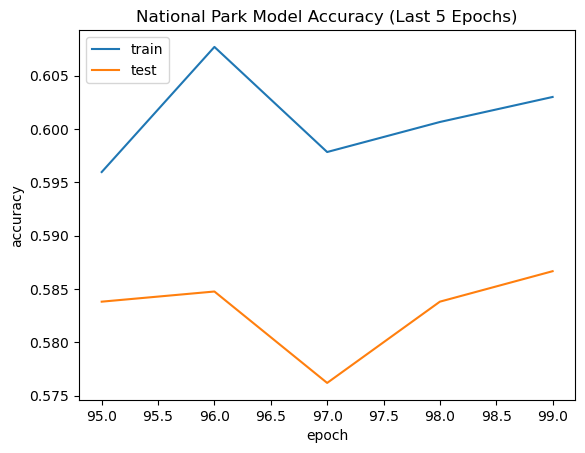

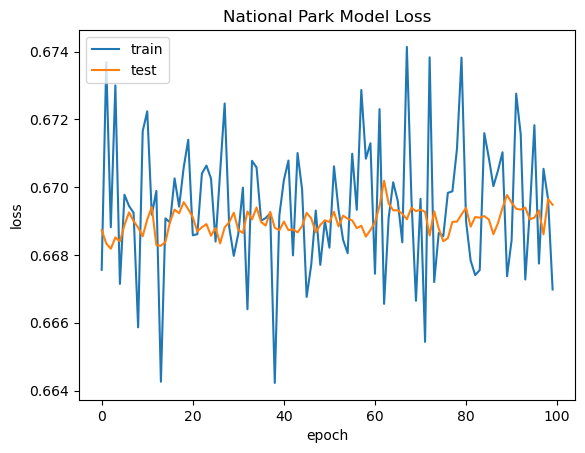

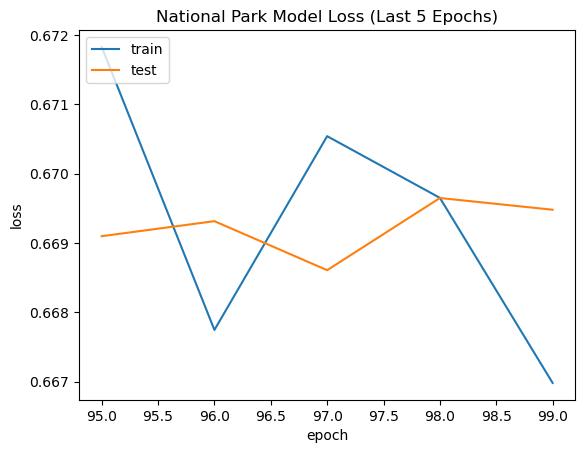

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



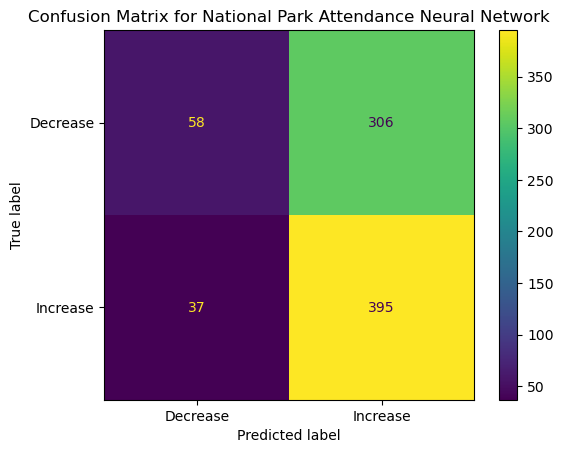

In [143]:
# Model Nodes: 6 / National Park / SGD / 0.01 / 100 / 32
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 100, batch = 32)

#### Additional Epochs

In [ ]:
# Take top two models and run for additional epochs

Initial Model Weights: 
 [array([[ 0.1392371 ,  0.6694013 ,  0.10536928,  0.7072028 ],
       [-0.05134283, -0.2290871 , -0.04640993, -0.31430304],
       [-0.32781664, -0.02587626,  0.03837174, -0.27595192],
       [ 0.7456285 ,  0.07026193, -2.753884  , -1.6453878 ]],
      dtype=float32), array([-0.06644695,  0.38316968, -3.1314194 , -2.9027467 ], dtype=float32), array([[ 0.24011199],
       [ 0.2716998 ],
       [-0.57225704],
       [-0.2559834 ]], dtype=float32), array([0.08937719], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5828 - loss: 0.6735
Accuracy: 0.5828356146812439, Loss: 0.673497200012207
Trained Model Weights: /n [array([[ 0.23504364,  0.76052666,  0.01504721,  0.717726  ],
       [-0.06063917, -0.400527  , -0.01238746, -0.19485247],
       [-0.34677982,  0.02653538,  0.0355117 , -0.32157177],
       [ 0.78373   ,  0.1518671 , -3.058824  , -1.8704135 ]],
      dtype=float32), array([-2.9550844e-03,  3.9787981e-01, -3.3992081e+00, -3.4975123e+

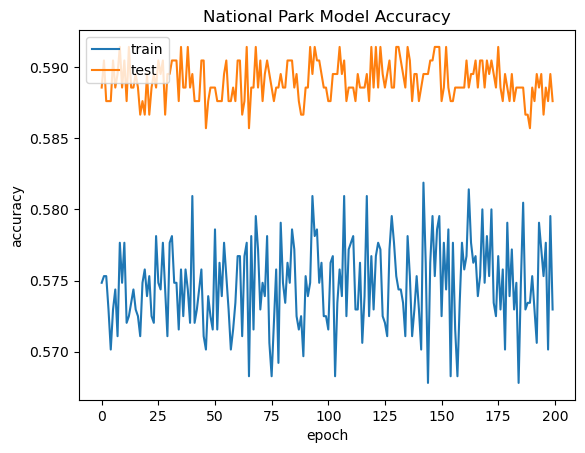

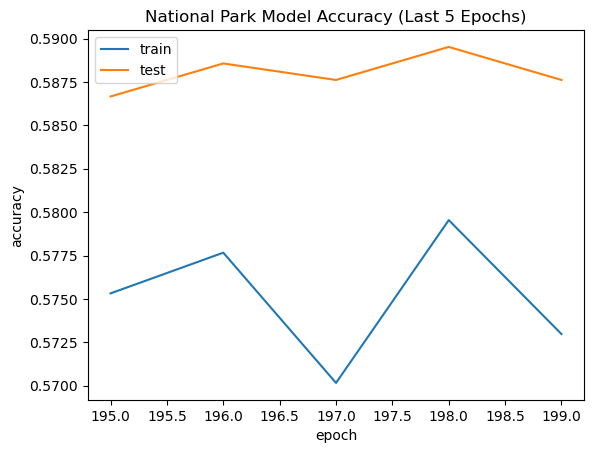

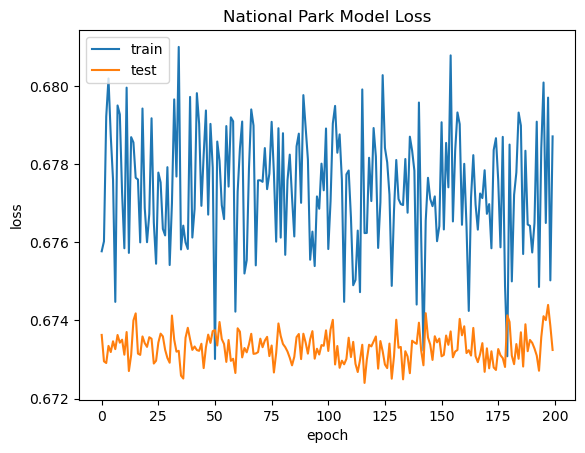

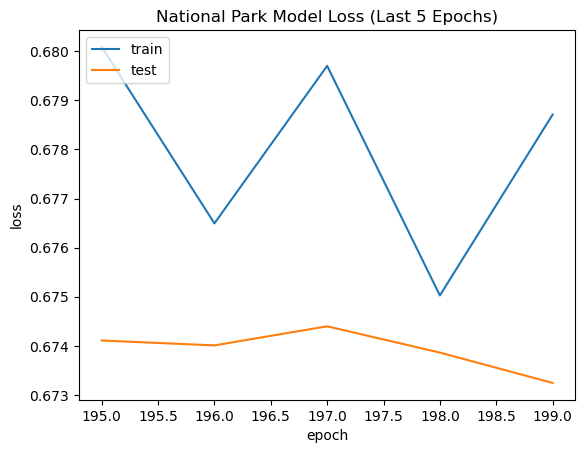

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



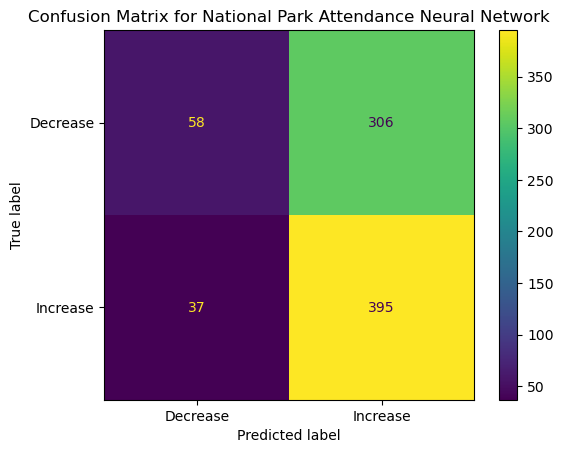

In [144]:
# Model Nodes: 4 / National Park / Adam / 0.01 / 200 / 32
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 200, batch = 32)

Initial Model Weights: 
 [array([[ 0.23504364,  0.76052666,  0.01504721,  0.717726  ],
       [-0.06063917, -0.400527  , -0.01238746, -0.19485247],
       [-0.34677982,  0.02653538,  0.0355117 , -0.32157177],
       [ 0.78373   ,  0.1518671 , -3.058824  , -1.8704135 ]],
      dtype=float32), array([-2.9550844e-03,  3.9787981e-01, -3.3992081e+00, -3.4975123e+00],
      dtype=float32), array([[ 0.22056451],
       [ 0.18256426],
       [-0.45333087],
       [-0.3184506 ]], dtype=float32), array([0.11728373], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5835 - loss: 0.6741
Accuracy: 0.5834643244743347, Loss: 0.6740766167640686
Trained Model Weights: /n [array([[ 0.11518047,  0.71073747,  0.08062037,  0.7000394 ],
       [-0.02925183, -0.25922593, -0.04745826, -0.3142395 ],
       [-0.35761297, -0.04402451,  0.0553275 , -0.3026073 ],
       [ 0.77728647,  0.10963549, -3.4481328 , -2.168848  ]],
      dtype=float32), array([-0.07832089,  0.47460228, -3.833766  , -3

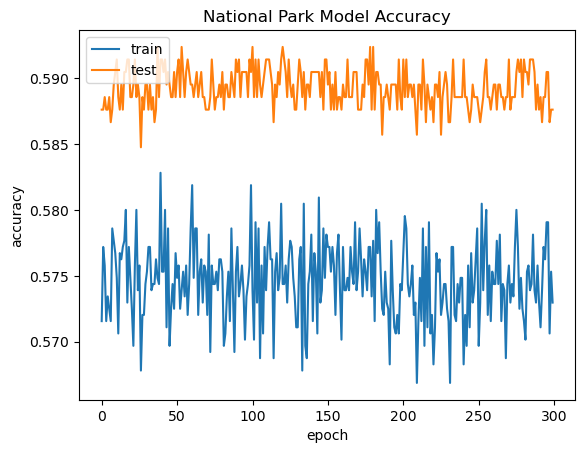

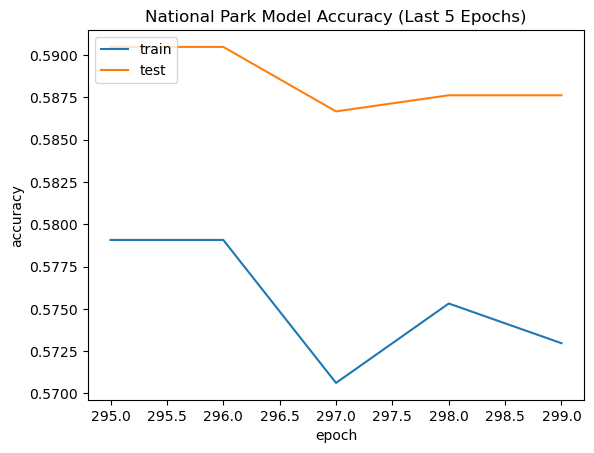

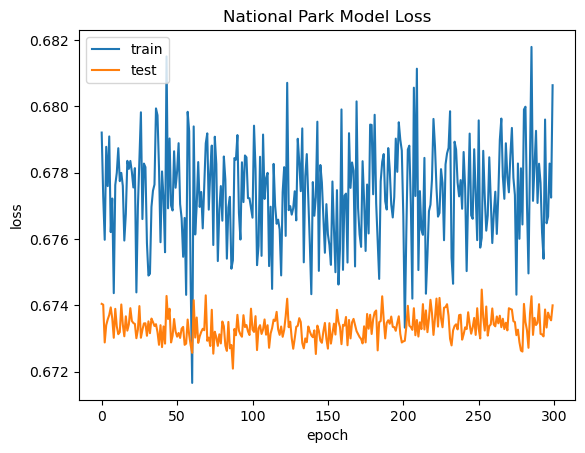

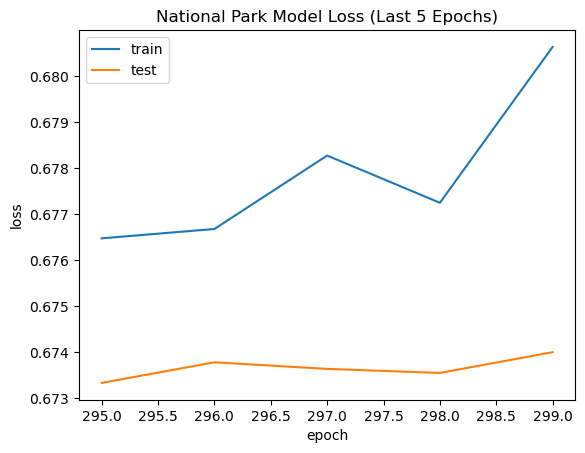

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



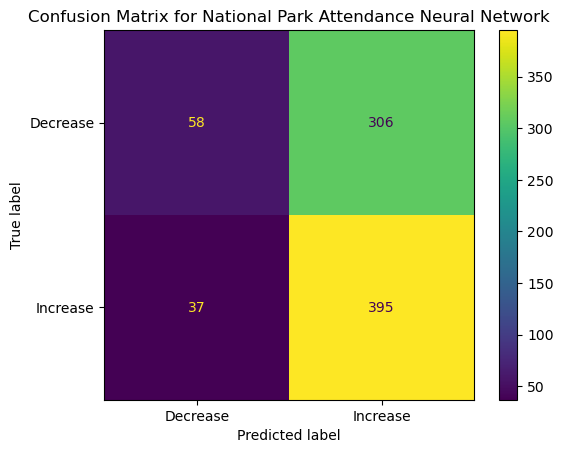

In [145]:
# Model Nodes: 4 / National Park / Adam / 0.01 / 300 / 32
model_eval(model_bl4,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 300, batch = 32)

Initial Model Weights: 
 [array([[ 0.32580554,  0.14252295, -2.4246519 ,  0.32428116,  0.51381433,
         0.604247  ],
       [-0.12825732, -0.12076832,  0.23812446, -0.30798414, -0.07156134,
         0.44776177],
       [ 1.1294867 , -0.02252484,  0.6173213 , -2.7044227 ,  0.08741884,
        -0.48689812],
       [-0.9994002 , -2.8374152 , -0.3850543 ,  0.16135898,  0.5337305 ,
        -0.81165105]], dtype=float32), array([-1.8082906 , -3.115149  , -0.8136532 , -3.0965662 ,  0.07524492,
       -2.0102324 ], dtype=float32), array([[ 0.31435436],
       [-0.59710044],
       [-0.37181205],
       [ 0.7553734 ],
       [ 0.2411009 ],
       [-0.24959637]], dtype=float32), array([0.28473043], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6004 - loss: 0.6659
Accuracy: 0.6004400849342346, Loss: 0.6658904552459717
Trained Model Weights: /n [array([[ 0.3266507 ,  0.13275303, -2.3978598 ,  0.34528774,  0.40872025,
         0.5405276 ],
       [-0.07304776, -0.1141734

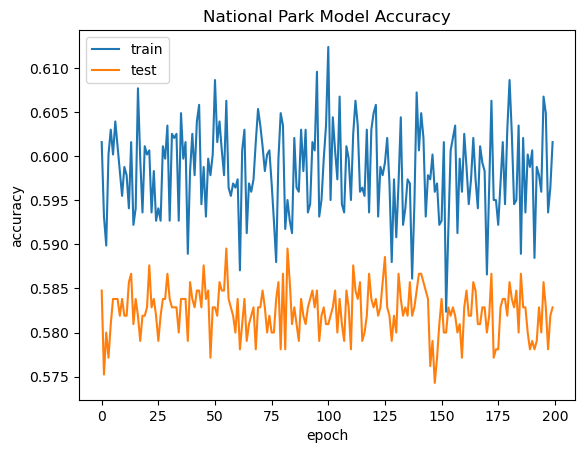

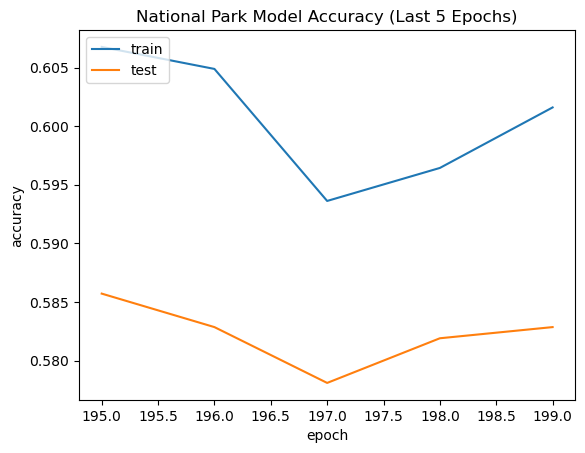

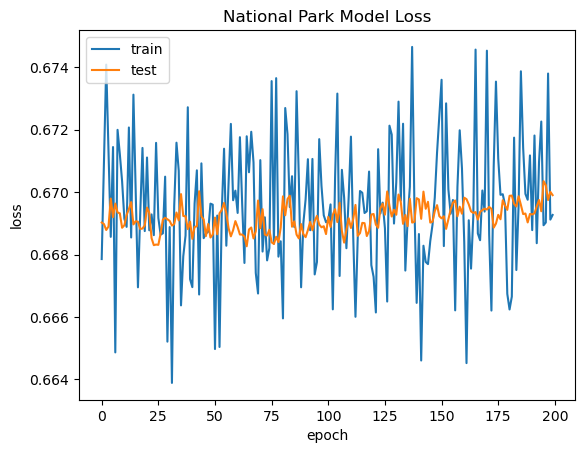

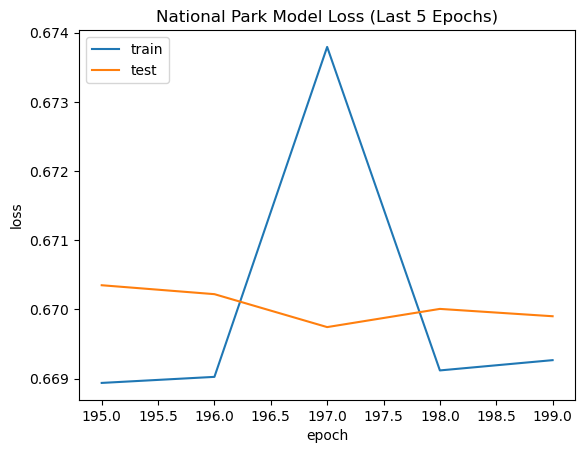

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



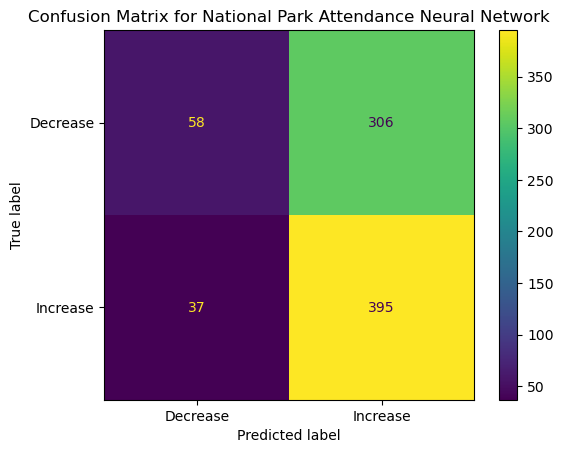

In [146]:
# Model Nodes: 6 / National Park / SGD / 0.01 / 200 / 32
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 200, batch = 32)

Initial Model Weights: 
 [array([[ 0.3266507 ,  0.13275303, -2.3978598 ,  0.34528774,  0.40872025,
         0.5405276 ],
       [-0.07304776, -0.11417344,  0.22790681, -0.26316196, -0.0987893 ,
         0.487565  ],
       [ 1.1272411 ,  0.01709639,  0.5975321 , -2.7663581 , -0.0077265 ,
        -0.5088566 ],
       [-0.9967457 , -2.832623  , -0.38358024,  0.17789957,  0.4895246 ,
        -0.78853804]], dtype=float32), array([-1.8025599 , -3.1514306 , -0.81004435, -3.1374779 ,  0.17630379,
       -1.9780471 ], dtype=float32), array([[ 0.2893108 ],
       [-0.58530366],
       [-0.33877373],
       [ 0.7415557 ],
       [ 0.26991987],
       [-0.27054733]], dtype=float32), array([0.25341803], dtype=float32)]
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5982 - loss: 0.6659
Accuracy: 0.598239541053772, Loss: 0.6658622622489929
Trained Model Weights: /n [array([[ 0.33523443,  0.1583739 , -2.3650062 ,  0.32367358,  0.37251952,
         0.55862033],
       [-0.11743173, -0.1093861 

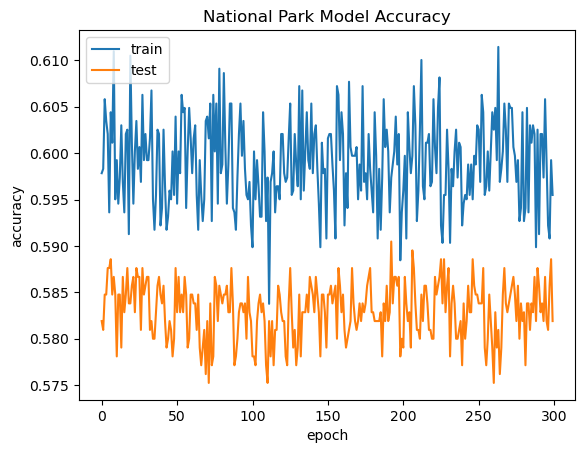

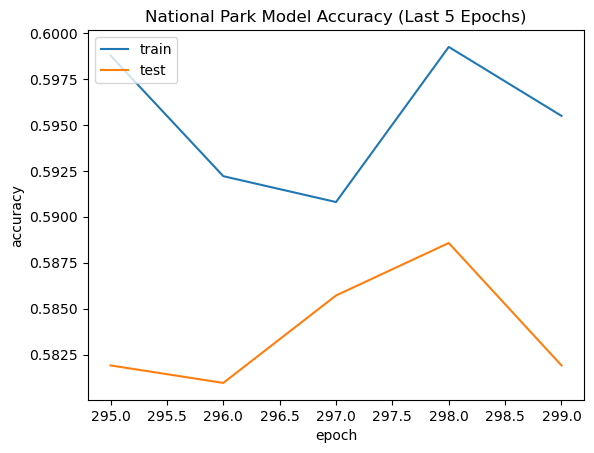

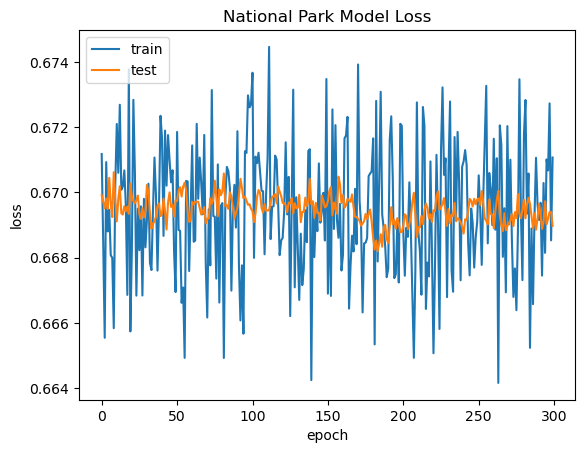

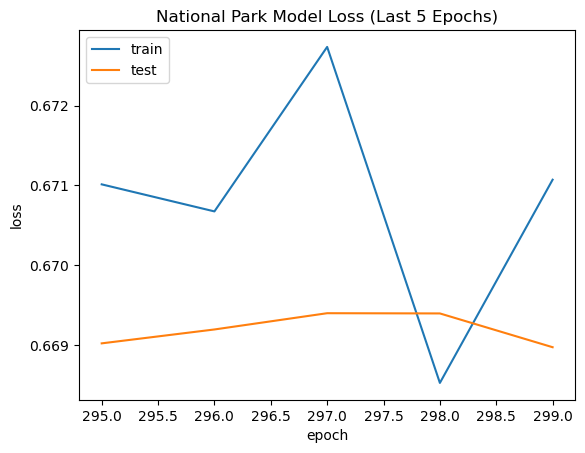

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.6105    0.1593    0.2527       364
           1     0.5635    0.9144    0.6973       432

    accuracy                         0.5691       796
   macro avg     0.5870    0.5368    0.4750       796
weighted avg     0.5850    0.5691    0.4940       796



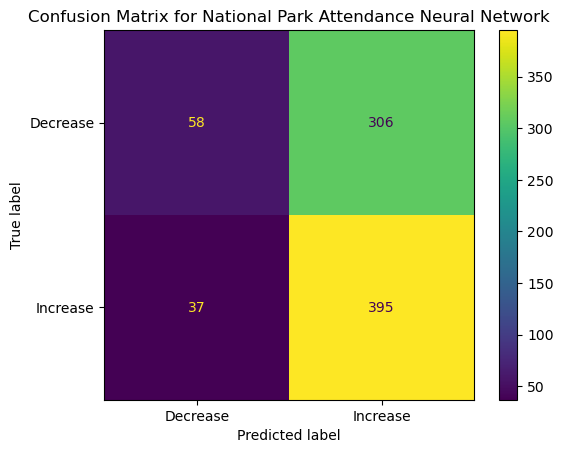

In [147]:
# Model Nodes: 6 / National Park / SGD / 0.01 / 300 / 32
model_eval(model_bl6,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 300, batch = 32)

#### Additional Layers

In [148]:
params = {
    'batch_size':[32],
    'epochs':[100],
    'model__ncount':[3,4,6,8,12],
}

In [150]:
def build_nn_np4(ncount):
    mod = Sequential()
    mod.add(Input(shape=(4,)))
    mod.add(Dense(units = 4, activation = 'relu'))
    mod.add(Dense(units = 8, activation = 'relu'))
    mod.add(Dense(units = 4, activation = 'relu'))
    mod.add(Dense(units = ncount, activation = 'relu'))
    mod.add(Dropout(0.2))
    mod.add(Dense(units = 1, activation = 'sigmoid'))
    
    mod.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

    return mod


opt_nn(params, Xnp_train, ynp_train, build_nn_np4)

#Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 8}
#Accuracy: 0.5831526514814923

#Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 4}
#Accuracy: 0.5875630658649527

Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 4}
Accuracy: 0.5875630658649527


In [152]:
def build_nn_np6(ncount):
    mod = Sequential()
    mod.add(Input(shape=(4,)))
    mod.add(Dense(units = 6, activation = 'relu'))
    mod.add(Dense(units = 12, activation = 'relu'))
    mod.add(Dense(units = 6, activation = 'relu'))
    mod.add(Dense(units = ncount, activation = 'relu'))
    mod.add(Dropout(0.2))
    mod.add(Dense(units = 1, activation = 'sigmoid'))
    
    mod.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

    return mod


opt_nn(params, Xnp_train, ynp_train, build_nn_np4)

#Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 12}
#Accuracy: 0.5787511230907457

#Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 6}
#Accuracy: 0.5822082679225536

Best parameters: {'batch_size': 32, 'epochs': 100, 'model__ncount': 6}
Accuracy: 0.5822082679225536


In [153]:
# create baseline model with the nodes that match the input (features)

model_4_3 = Sequential([
    keras.Input(shape = (4,)),
    Dense(units = 4, activation = 'relu'),
    Dense(units = 8, activation = 'relu'),
    Dense(units = 4, activation = 'relu'),
    Dropout(0.2),
    Dense(units = 1, activation = 'sigmoid')
])


model_6_3 = Sequential([
    keras.Input(shape = (4,)),
    Dense(units = 6, activation = 'relu'),
    Dense(units = 12, activation = 'relu'),
    Dense(units = 6, activation = 'relu'),
    Dropout(0.2),
    Dense(units = 1, activation = 'sigmoid')
])


Initial Model Weights: 
 [array([[-0.34633052,  0.2246632 ,  0.3740793 , -0.20627582],
       [-0.3982313 ,  0.07591748, -0.38869396, -0.7690927 ],
       [-0.5963272 ,  0.4706263 ,  0.15646976,  0.12887007],
       [-0.57165426, -0.04983747,  0.21278566,  0.54114324]],
      dtype=float32), array([0., 0., 0., 0.], dtype=float32), array([[-0.37645614,  0.48740727, -0.28301018,  0.624585  , -0.6509206 ,
         0.06050938, -0.24426559, -0.17766786],
       [-0.52750206, -0.40187946, -0.04780632,  0.33805805,  0.27442384,
         0.27864683,  0.20296419,  0.11530739],
       [-0.26194063, -0.08800244,  0.34382743, -0.13356823,  0.4335677 ,
         0.59818214,  0.4106838 , -0.35085395],
       [-0.5248137 , -0.35880202,  0.24262828, -0.03392655, -0.67293173,
        -0.1900106 ,  0.20862776,  0.6299475 ]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[-0.03249115, -0.12931055, -0.681454  ,  0.12476528],
       [ 0.0108245 ,  0.5259536 , -0.6600151 , -0

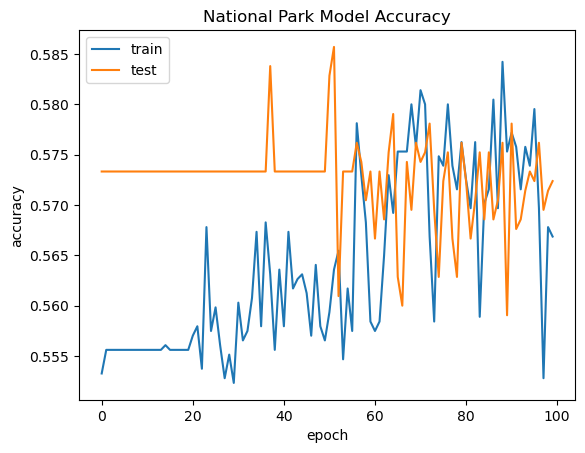

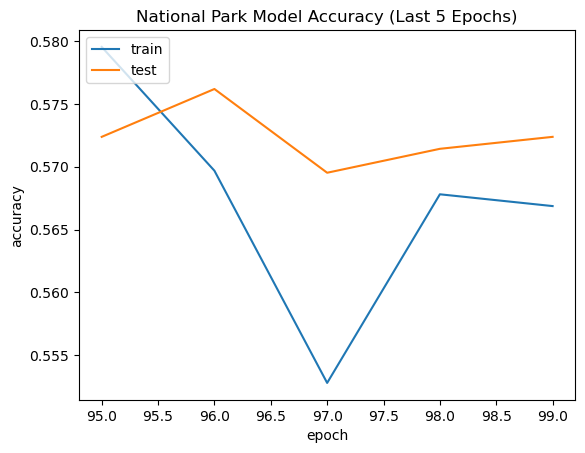

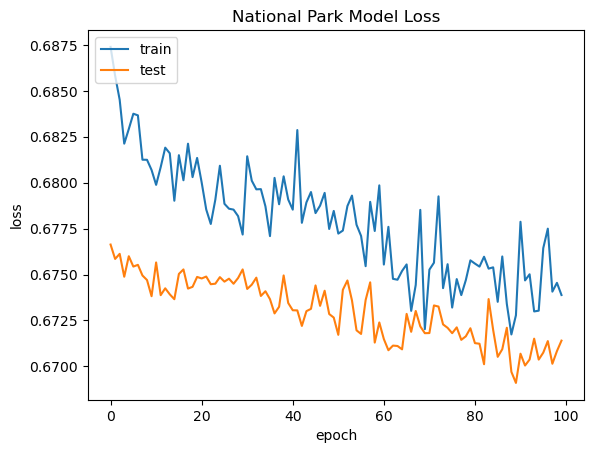

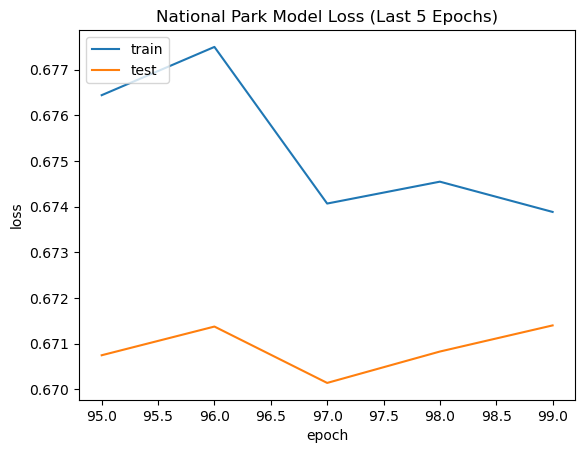

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

 Classification Report:

               precision    recall  f1-score   support

           0     0.5025    0.2720    0.3529       364
           1     0.5576    0.7731    0.6479       432

    accuracy                         0.5440       796
   macro avg     0.5301    0.5226    0.5004       796
weighted avg     0.5324    0.5440    0.5130       796



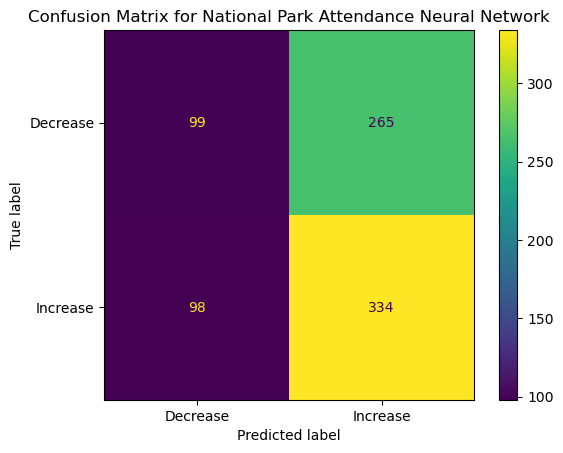

In [154]:
# Model Nodes: 4 / National Park / Adam / 0.01 / 100 / 32
model_eval(model_4_3,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 0.15062387,  0.01575365,  1.403996  , -0.13119185],
       [ 0.60824126, -0.0693978 ,  0.08283576, -0.22828346],
       [-0.88765085, -0.27393392, -0.10870403, -0.4142128 ],
       [-2.1689055 , -0.07320723, -0.17086329,  1.344935  ]],
      dtype=float32), array([-1.3578135 , -0.4592356 ,  1.1705612 , -0.05361109], dtype=float32), array([[-0.37645614,  0.879683  , -0.27890363,  2.078767  , -1.5178189 ,
        -0.9950507 , -0.7385533 ,  0.1580317 ],
       [-0.52750206, -0.09321295, -0.02616343,  0.01967645,  0.20631929,
         0.10684417,  0.05661602,  0.26591158],
       [-0.26194063, -0.17036577,  0.01752081, -0.2884867 ,  0.6304653 ,
         0.02817846,  1.0074599 , -3.1267338 ],
       [-0.5248137 , -1.3453803 , -0.10017518, -1.8306949 , -2.9519587 ,
        -0.62673664,  0.08273049,  0.44702414]], dtype=float32), array([ 0.        , -1.3153604 , -0.24444564, -0.11774252, -0.9448303 ,
       -0.18346548, -0.03066621, -0.23357733], dtype=float

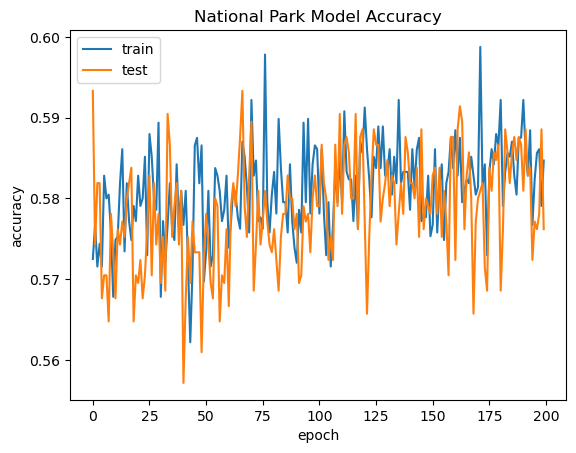

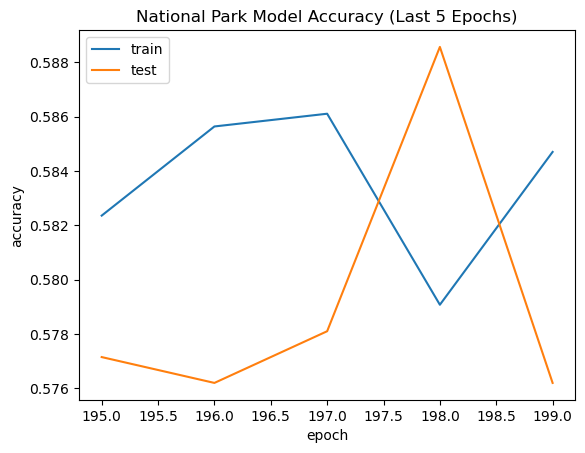

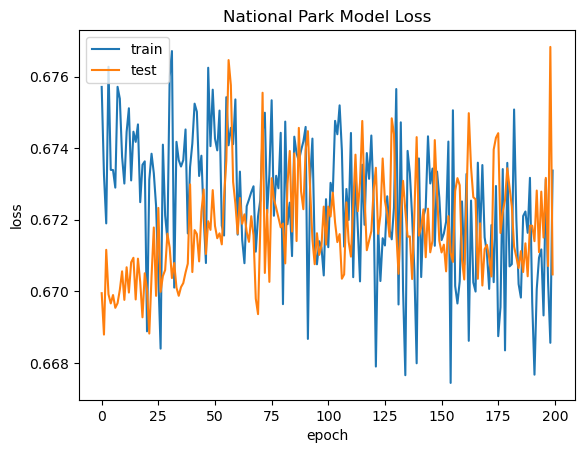

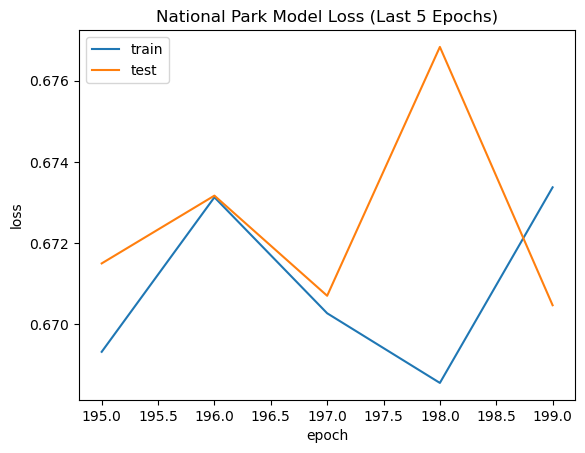

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.4928    0.2802    0.3573       364
           1     0.5552    0.7569    0.6405       432

    accuracy                         0.5389       796
   macro avg     0.5240    0.5186    0.4989       796
weighted avg     0.5266    0.5389    0.5110       796



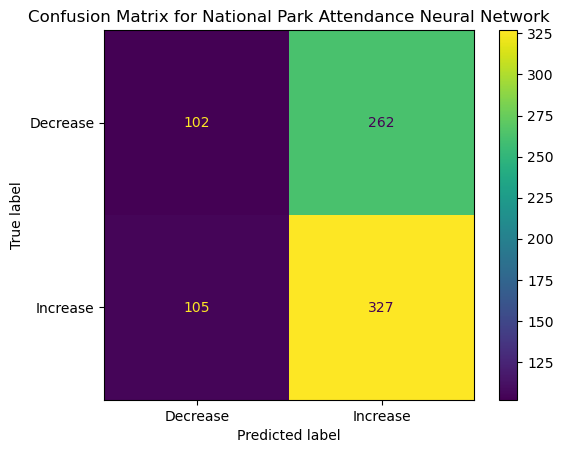

In [156]:
# Model Nodes: 4 / National Park / Adam / 0.01 / 200 / 32
model_eval(model_4_3,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'adam', opts = 11, epoch = 200, batch = 32)

Initial Model Weights: 
 [array([[-0.06330049, -0.04756939,  0.28671074, -0.08326459,  0.2662711 ,
        -0.08575588],
       [ 0.0702858 ,  0.11414886,  0.02999306,  0.43616164, -0.5409359 ,
        -0.01605129],
       [ 0.75469446, -0.19331968, -0.5833845 ,  0.1293298 , -0.31937203,
         0.26132345],
       [-0.37731647,  0.07118088,  0.31012058, -0.44672632,  0.20053715,
        -0.5385493 ]], dtype=float32), array([0., 0., 0., 0., 0., 0.], dtype=float32), array([[-0.27438295,  0.26495898,  0.1551159 , -0.01639479, -0.21288654,
         0.16419715, -0.10553044,  0.5312041 , -0.28373304, -0.5236033 ,
        -0.32270068,  0.03327012],
       [ 0.43249357,  0.2474528 , -0.12482071,  0.06272674,  0.29886913,
        -0.39518178,  0.4060045 ,  0.34198612,  0.35005963, -0.20633861,
         0.07802707, -0.16679767],
       [ 0.5689107 , -0.3912677 , -0.39135814, -0.45265013, -0.41737953,
        -0.5643647 , -0.5330383 , -0.5551247 , -0.4320011 , -0.2710233 ,
         0.19985485, 

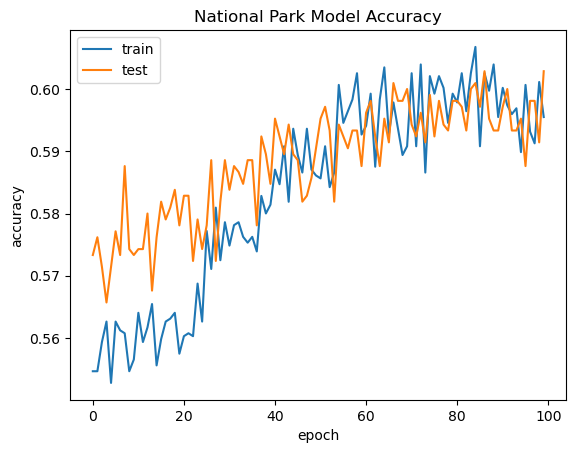

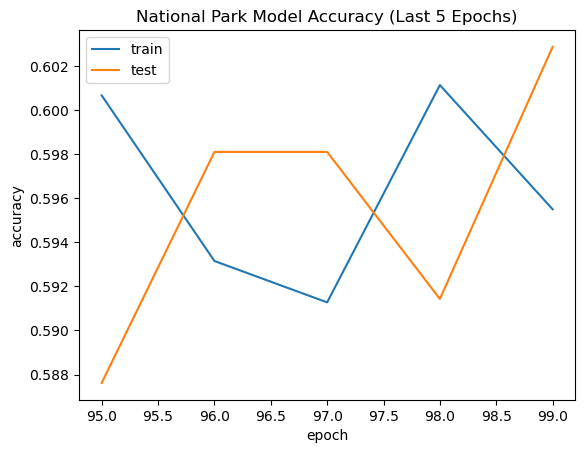

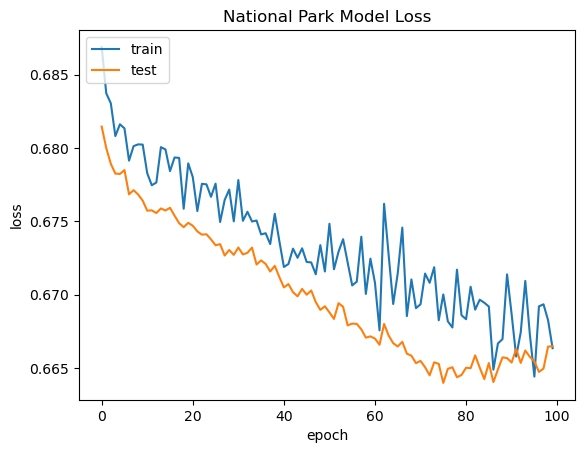

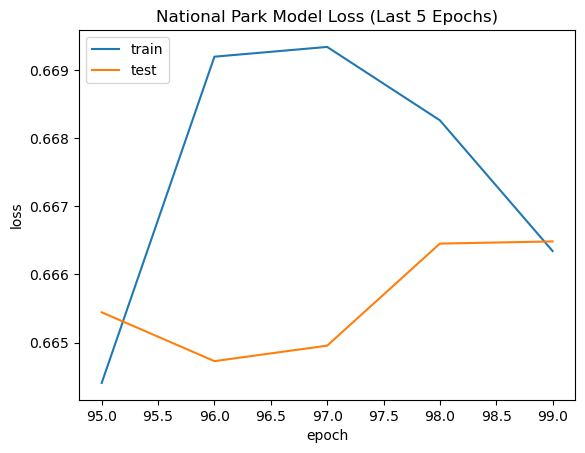

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.5080    0.2610    0.3448       364
           1     0.5583    0.7870    0.6532       432

    accuracy                         0.5465       796
   macro avg     0.5332    0.5240    0.4990       796
weighted avg     0.5353    0.5465    0.5122       796



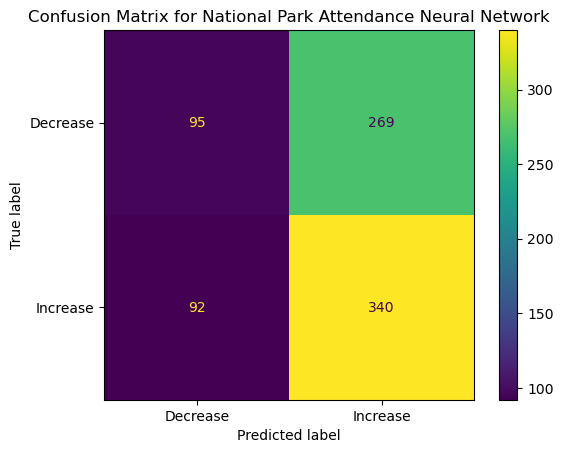

In [155]:
# Model Nodes: 6 / National Park / SGD / 0.01 / 100 / 32
model_eval(model_6_3,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[ 0.00662357, -0.1924857 ,  0.8373236 , -0.3572657 ,  0.7449119 ,
         0.2680094 ],
       [ 0.09195273,  0.01624815,  0.03515627,  0.3913768 , -0.09861037,
        -0.0863478 ],
       [ 0.9230044 ,  0.15035067, -0.48306984,  0.25276244,  0.2104639 ,
         0.49401453],
       [-0.34244573,  0.21697289,  0.40543756, -0.9104567 ,  0.3416978 ,
        -0.93018705]], dtype=float32), array([ 0.10626449,  0.3783421 ,  0.3293386 , -0.22859268,  0.414907  ,
       -0.2945485 ], dtype=float32), array([[-0.529164  ,  0.5387233 ,  0.20358075, -0.07335114, -0.2162857 ,
         0.25071758, -0.2789655 ,  0.57959676, -0.15596098, -0.5259879 ,
        -0.22847623,  0.12855837],
       [ 0.31853738,  0.2820137 , -0.25308967,  0.03494558,  0.3330221 ,
        -0.4031201 ,  0.39127117,  0.43890807,  0.4119324 , -0.21212313,
         0.07817098, -0.24380079],
       [ 0.36506933, -0.64221215, -0.5050283 , -0.4957453 , -0.7175427 ,
        -0.56161255, -0.45032963,

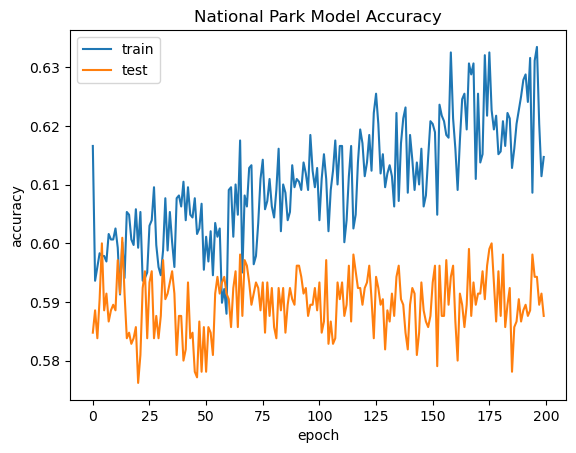

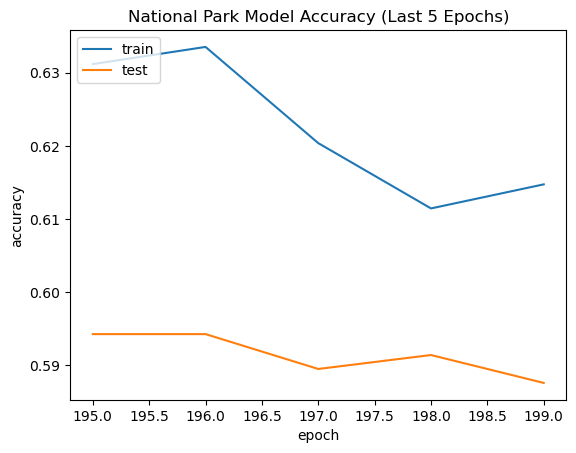

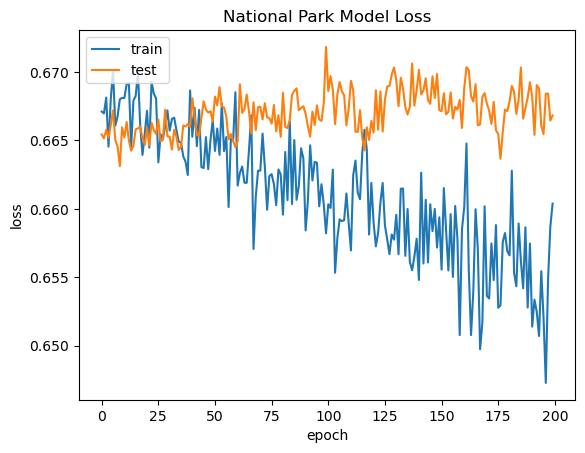

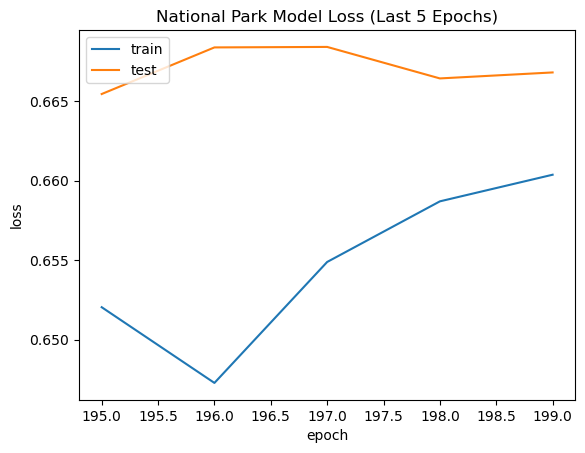

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.5266    0.2995    0.3818       364
           1     0.5671    0.7731    0.6543       432

    accuracy                         0.5565       796
   macro avg     0.5468    0.5363    0.5180       796
weighted avg     0.5485    0.5565    0.5297       796



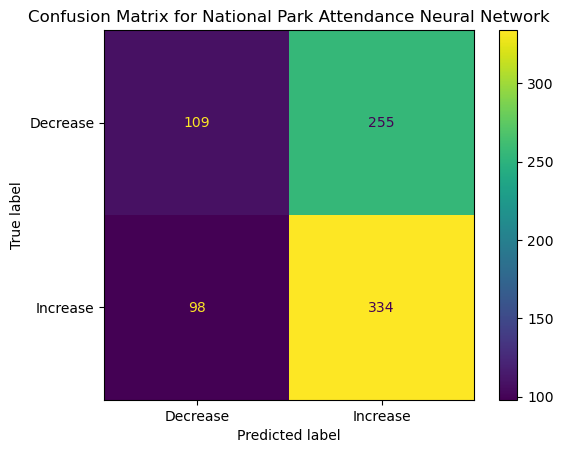

In [163]:
# Model Nodes: 6 / National Park / SGD / 0.01 / 200 / 32
model_eval(model_6_3,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 200, batch = 32)

Initial Model Weights: 
 [array([[-0.1765709 , -0.5335871 ,  1.5379083 , -0.35627198,  1.2159123 ,
         0.44509965],
       [ 0.15273938, -0.09383488,  0.06947906,  0.62052256, -0.04354551,
        -0.28872374],
       [ 1.4128388 ,  0.34659612, -0.66191363,  0.27267483,  0.5427493 ,
         0.84277254],
       [-0.3383145 ,  0.33894265,  0.6533443 , -1.4486107 ,  0.50770026,
        -1.663626  ]], dtype=float32), array([-0.02762385,  0.6261822 ,  0.72428644, -0.43024775,  0.802988  ,
       -0.47467887], dtype=float32), array([[-0.8022074 ,  1.191748  ,  0.32694158, -0.01786301, -0.32564566,
         0.68044716, -0.5245581 ,  0.9673346 ,  0.09312353, -0.53065664,
        -0.03619586,  0.24656293],
       [ 0.22669181,  0.55011547, -0.36821124, -0.14344524,  0.42288232,
        -0.44479716,  0.05002442,  1.0152383 ,  0.20060483, -0.21314572,
        -0.07556298, -0.820699  ],
       [ 0.41711792, -1.1682675 , -0.6402324 , -0.36184436, -1.0805848 ,
        -0.6982664 , -0.6805725 ,

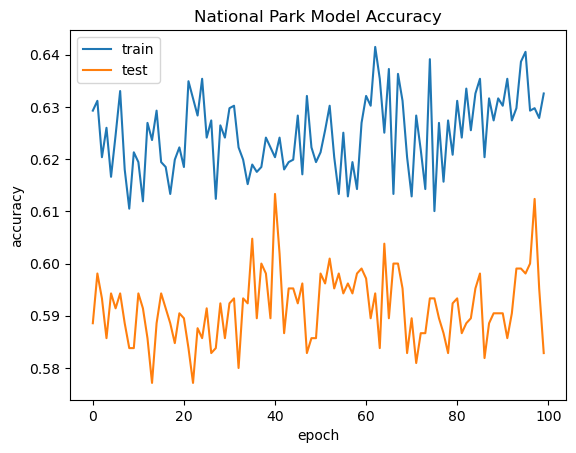

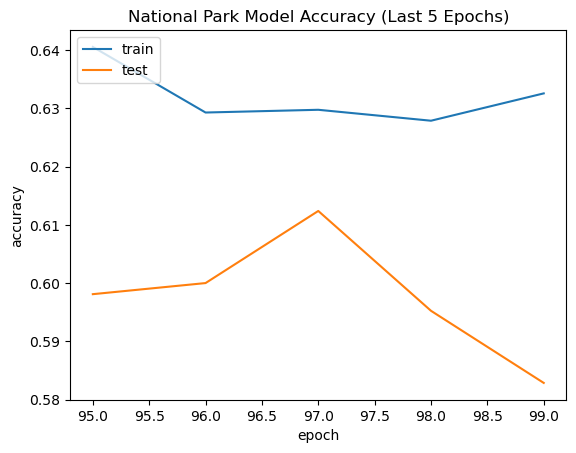

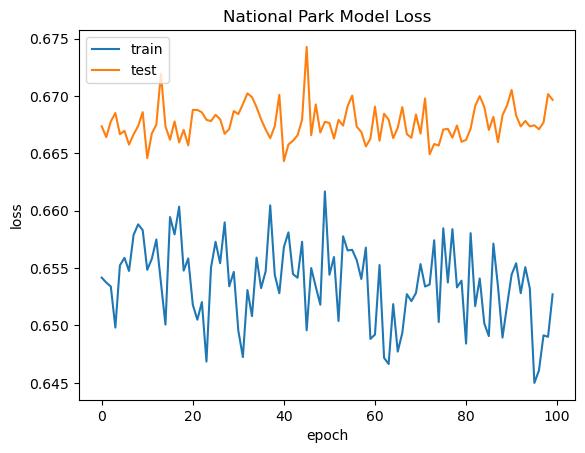

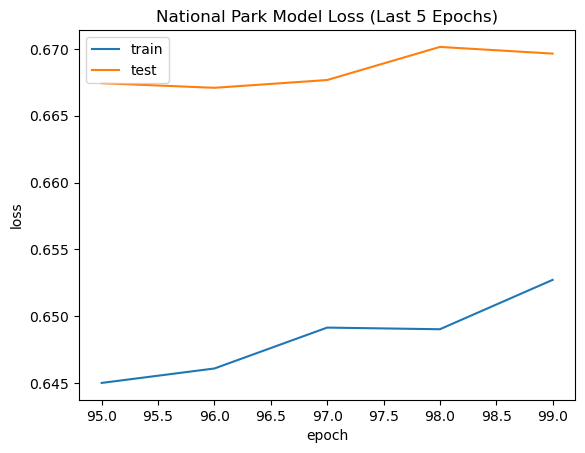

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.5544    0.2940    0.3842       364
           1     0.5738    0.8009    0.6686       432

    accuracy                         0.5691       796
   macro avg     0.5641    0.5474    0.5264       796
weighted avg     0.5649    0.5691    0.5385       796



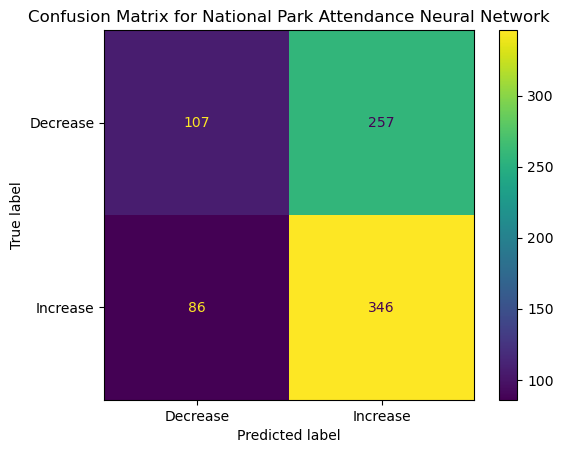

In [168]:

# Model Nodes: 6 / National Park / SGD / 0.01 / 100 / 32
history, y_pred, cm = model_eval(model_6_3,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 100, batch = 32)

Initial Model Weights: 
 [array([[-0.10562307, -0.73545015,  1.7442712 , -0.4002665 ,  1.3991829 ,
         0.48079538],
       [ 0.20227152,  0.08577713,  0.08563834,  0.66900826,  0.07509909,
        -0.34688652],
       [ 1.6421038 ,  0.18834606, -0.82793057,  0.30196282,  0.6695404 ,
         0.9614571 ],
       [-0.47795638,  0.35766572,  0.7463542 , -1.555451  ,  0.6096185 ,
        -1.8757083 ]], dtype=float32), array([-0.07613834,  0.58858585,  0.8177373 , -0.4601022 ,  0.92679435,
       -0.5379175 ], dtype=float32), array([[-8.4392458e-01,  1.4077901e+00,  3.2035670e-01,  4.6434104e-02,
        -4.1248810e-01,  7.9231626e-01, -4.7967970e-01,  1.2849970e+00,
         1.6527717e-01, -5.3060263e-01,  1.1664771e-02,  2.4805352e-01],
       [-1.3227822e-05,  6.6834390e-01, -3.9684999e-01, -2.4818787e-01,
         4.7319338e-01, -4.3084380e-01, -4.6511255e-02,  1.1249313e+00,
         2.2244897e-01, -2.1428709e-01, -1.6193788e-02, -9.8040223e-01],
       [ 2.8629491e-01, -1.3817232

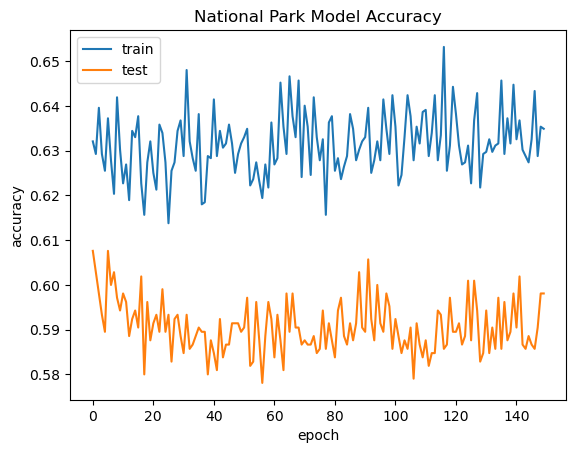

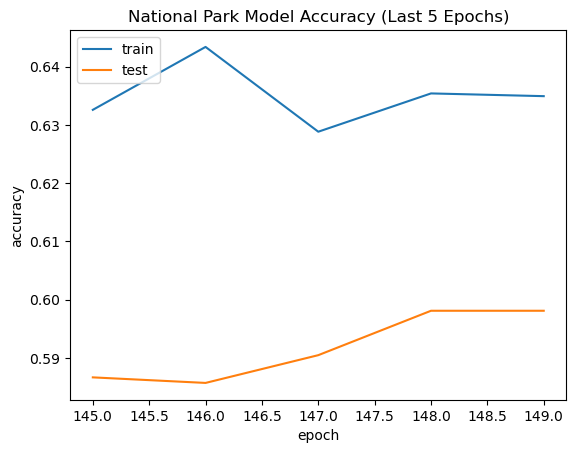

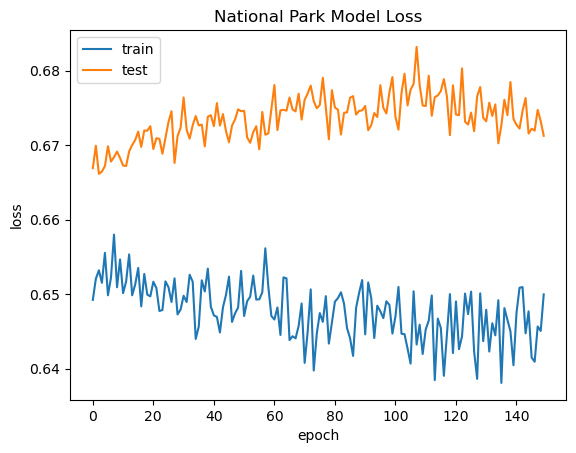

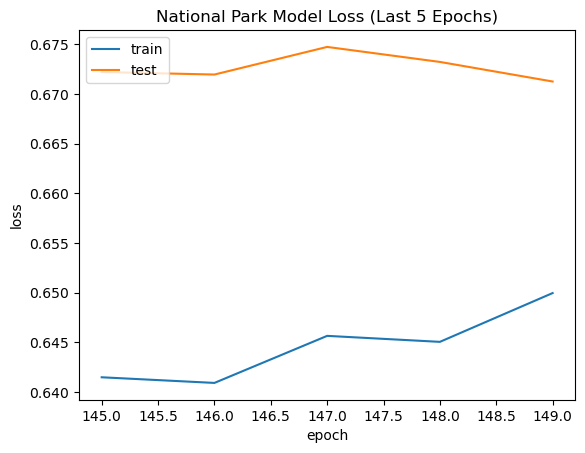

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 Classification Report:

               precision    recall  f1-score   support

           0     0.5232    0.3407    0.4126       364
           1     0.5707    0.7384    0.6438       432

    accuracy                         0.5565       796
   macro avg     0.5469    0.5395    0.5282       796
weighted avg     0.5490    0.5565    0.5381       796



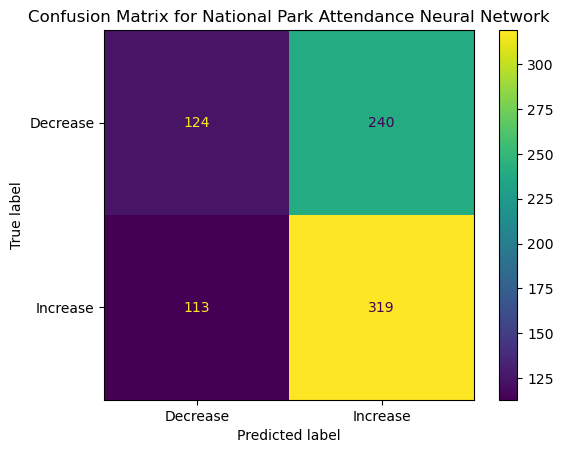

In [194]:
# Model Nodes: 6 / National Park / SGD / 0.01 / 100 / 32
history, y_pred, cm = model_eval(model_6_3,Xnp_train, ynp_train, Xnp_test, ynp_test, 'National Park', opt = 'sgd', opts = 11, epoch = 150, batch = 32)

In [1]:
y_pred_df1 = pd.DataFrame(y_pred1)
y_pred_df15 = pd.DataFrame(y_pred15)
Xnp_test_rs = Xnp_test.reset_index()

NameError: name 'pd' is not defined

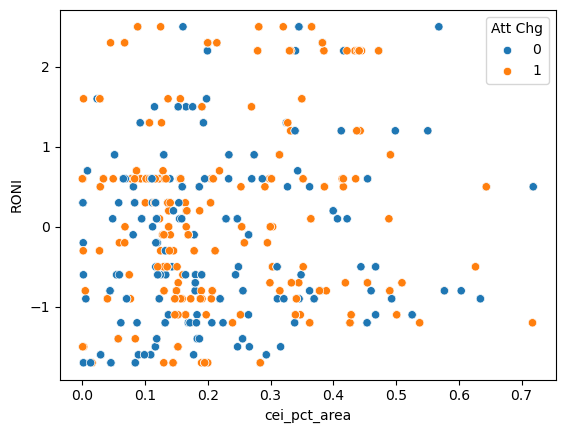

In [160]:
sns.scatterplot(data = Xnp_test_rs, x = 'cei_pct_area', y = 'RONI', hue = ynp_test['Att Chg'])
plt.show()

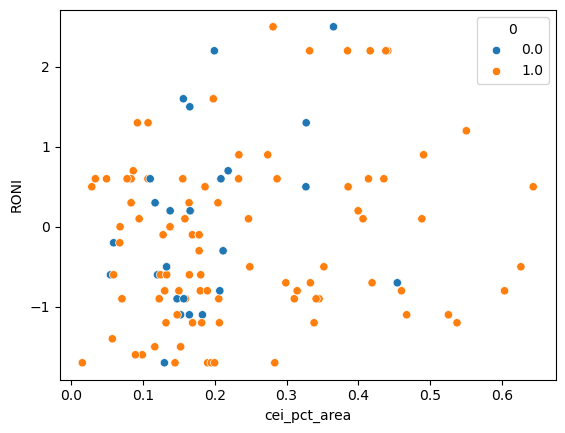

In [192]:
sns.scatterplot(data = Xnp_test_rs, x = 'cei_pct_area', y = 'RONI', hue = y_pred_df1[0])
plt.show()

In [ ]:
sns.scatterplot(data = Xnp_test_rs, x = 'cei_pct_area', y = 'RONI', hue = y_pred_df15[0])
plt.show()

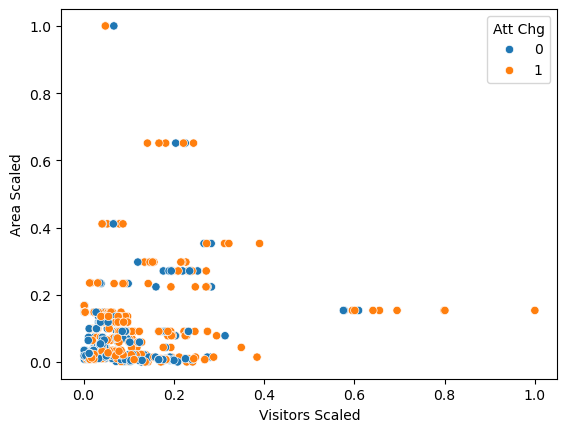

In [166]:
sns.scatterplot(data = Xnp_test_rs, x = 'Visitors Scaled', y = 'Area Scaled', hue = ynp_test['Att Chg'])
plt.show()

In [ ]:
sns.scatterplot(data = Xnp_test_rs, x = 'Visitors Scaled', y = 'Area Scaled', hue = hue = y_pred_df1[0])
plt.show()

In [ ]:
sns.scatterplot(data = Xnp_test_rs, x = 'Visitors Scaled', y = 'Area Scaled', hue = hue = y_pred_df15[0])
plt.show()